## Exploratory Data Analysis (EDA)

```
 Objective:
The main goal of this assignment is to conduct a thorough exploratory analysis of the "cardiographic.csv" dataset to uncover insights, identify patterns, and understand the dataset's underlying structure. You will use statistical summaries, visualizations, and data manipulation techniques to explore the dataset comprehensively.


Dataset:
1.	LB - Likely stands for "Baseline Fetal Heart Rate (FHR)" which represents the average fetal heart rate over a period.
2.	AC - Could represent "Accelerations" in the FHR. Accelerations are usually a sign of fetal well-being.
3.	FM - May indicate "Fetal Movements" detected by the monitor.
4.	UC - Likely denotes "Uterine Contractions", which can impact the FHR pattern.
5.	DL - Could stand for "Decelerations Late" with respect to uterine contractions, which can be a sign of fetal distress.
6.	DS - May represent "Decelerations Short" or decelerations of brief duration.
7.	DP - Could indicate "Decelerations Prolonged", or long-lasting decelerations.
8.	ASTV - Might refer to "Percentage of Time with Abnormal Short Term Variability" in the FHR.
9.	MSTV - Likely stands for "Mean Value of Short Term Variability" in the FHR.
10.	ALTV - Could represent "Percentage of Time with Abnormal Long Term Variability" in the FHR.
11.	MLTV - Might indicate "Mean Value of Long Term Variability" in the FHR.


Tools and Libraries:
●	Python programming language
●	Data manipulation libraries 
●	Data visualization libraries (Matplotlib and Seaborn in Python)
●	Jupyter Notebook for documenting your analysis


Tasks:
1.	Data Cleaning and Preparation:
●	Load the dataset into a data frame or equivalent data structure.
●	Handle missing values appropriately (e.g., imputation, deletion).
●	Identify and correct any inconsistencies in data types (e.g., numerical values stored as strings).
●	Detect and treat outliers if necessary.


2.	Statistical Summary:
●	Provide a statistical summary for each variable in the dataset, including measures of central tendency (mean, median) and dispersion (standard deviation, interquartile range).
●	Highlight any interesting findings from this summary.


3.	Data Visualization:
●	Create histograms or boxplots to visualize the distributions of various numerical variables.
●	Use bar charts or pie charts to display the frequency of categories for categorical variables.
●	Generate scatter plots or correlation heatmaps to explore relationships between pairs of variables.
●	Employ advanced visualization techniques like pair plots, or violin plots for deeper insights.


4.	Pattern Recognition and Insights:
●	Identify any correlations between variables and discuss their potential implications.
●	Look for trends or patterns over time if temporal data is available.

5.	Conclusion:
●	Summarize the key insights and patterns discovered through your exploratory analysis.
●	Discuss how these findings could impact decision-making or further analyses.

Deliverables:
●	A detailed Jupyter Notebook file containing the code, visualizations, and explanations for each step of your analysis.
●	A brief report summarizing your findings, insights, and any recommendations for further analysis or actions based on the data.
```

## Understanding Data

In [1]:
# Understanding Data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


raw_df = pd.read_csv("Cardiotocographic.csv")

df = raw_df.copy()


print(df.head())

print("\n<------It will give the information about our data------->\n")
print(df.info())

print("\n<------It will describe all about our dataset------->\n")
print(df.describe(include="all"))

print("\n<------It will give the number of null values  in each columns------->\n")
print(df.isnull().sum())

print("\n<------It will give the number of duplicated values in each column ------->\n")
print(df.duplicated().sum())


           LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  \
0  120.000000  0.000000  0.0  0.000000  0.000000  0.0  0.0  73.0   0.5  43.0   
1  132.000000  0.006380  0.0  0.006380  0.003190  0.0  0.0  17.0   2.1   0.0   
2  133.000000  0.003322  0.0  0.008306  0.003322  0.0  0.0  16.0   2.1   0.0   
3  134.000000  0.002561  0.0  0.007742  0.002561  0.0  0.0  16.0   2.4   0.0   
4  131.948232  0.006515  0.0  0.008143  0.000000  0.0  0.0  16.0   2.4   0.0   

   MLTV  Width  Tendency  NSP  
0   2.4   64.0  0.999926  2.0  
1  10.4  130.0  0.000000  1.0  
2  13.4  130.0  0.000000  1.0  
3  23.0  117.0  1.000000  1.0  
4  19.9  117.0  1.000000  1.0  

<------It will give the information about our data------->

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2126 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2105 non-null   float64
 1   AC        2106 non-null   float64
 2 

## Extracting Numerical and Categorical Columns

In [2]:
# Extracting the Numerical columns and the categorical columns from our dataset
numerical_cols = df.select_dtypes(include=['float64']).columns.tolist()
numerical_cols.remove('NSP') # This is our categorical data cause, it has discrete values that's why 

print(numerical_cols)


['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency']


## Treating the Output categorical variable

In [3]:
"""
Here there is only one categorical variable that is NSP (Nasal Septum Pathology or Fetal State)- which gives discrete variables.
eg. 1 for normal, 2 for suspect and 3 for pathologic
"""

# Process of filling categorical data

df['NSP'] = pd.to_numeric(df['NSP'], errors='coerce')

valid_nsp = df['NSP'][df['NSP'] > 0]  
mode_nsp = valid_nsp.mode()[0] if not valid_nsp.empty else 1 

df['NSP'] = df['NSP'].where(df['NSP'] > 0, mode_nsp).round().astype('int').astype('category')

categorical = 'NSP'
numerical = [col for col in df.columns if col != 'NSP']

print("Categorical columns:", categorical)
print("Numerical columns:", numerical)

Categorical columns: NSP
Numerical columns: ['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Tendency']


In [4]:
# categorical data 
print(df[categorical])

print("\n<-------Tabble for numercal columns----->\n")
print(df[[col for col in numerical]])

0       2
1       1
2       1
3       1
4       1
       ..
2121    2
2122    2
2123    2
2124    2
2125    1
Name: NSP, Length: 2126, dtype: category
Categories (4, int64): [1, 2, 3, 5]

<-------Tabble for numercal columns----->

              LB        AC        FM        UC        DL   DS   DP  ASTV  \
0     120.000000  0.000000  0.000000  0.000000  0.000000  0.0  0.0  73.0   
1     132.000000  0.006380  0.000000  0.006380  0.003190  0.0  0.0  17.0   
2     133.000000  0.003322  0.000000  0.008306  0.003322  0.0  0.0  16.0   
3     134.000000  0.002561  0.000000  0.007742  0.002561  0.0  0.0  16.0   
4     131.948232  0.006515  0.000000  0.008143  0.000000  0.0  0.0  16.0   
...          ...       ...       ...       ...       ...  ...  ...   ...   
2121  140.000000  0.000000  0.961268  0.007426  0.000000  0.0  0.0  79.0   
2122  140.000000  0.000775  0.000000  0.006979  0.000000  0.0  0.0  78.0   
2123  140.000000  0.000980  0.000000  0.006863  0.000000  0.0  0.0  79.0   
2124  140

## EDA: Exploratory data analysis to see how each variable looks individually

### Univariate Analysis : Plotting graphs for individual variables

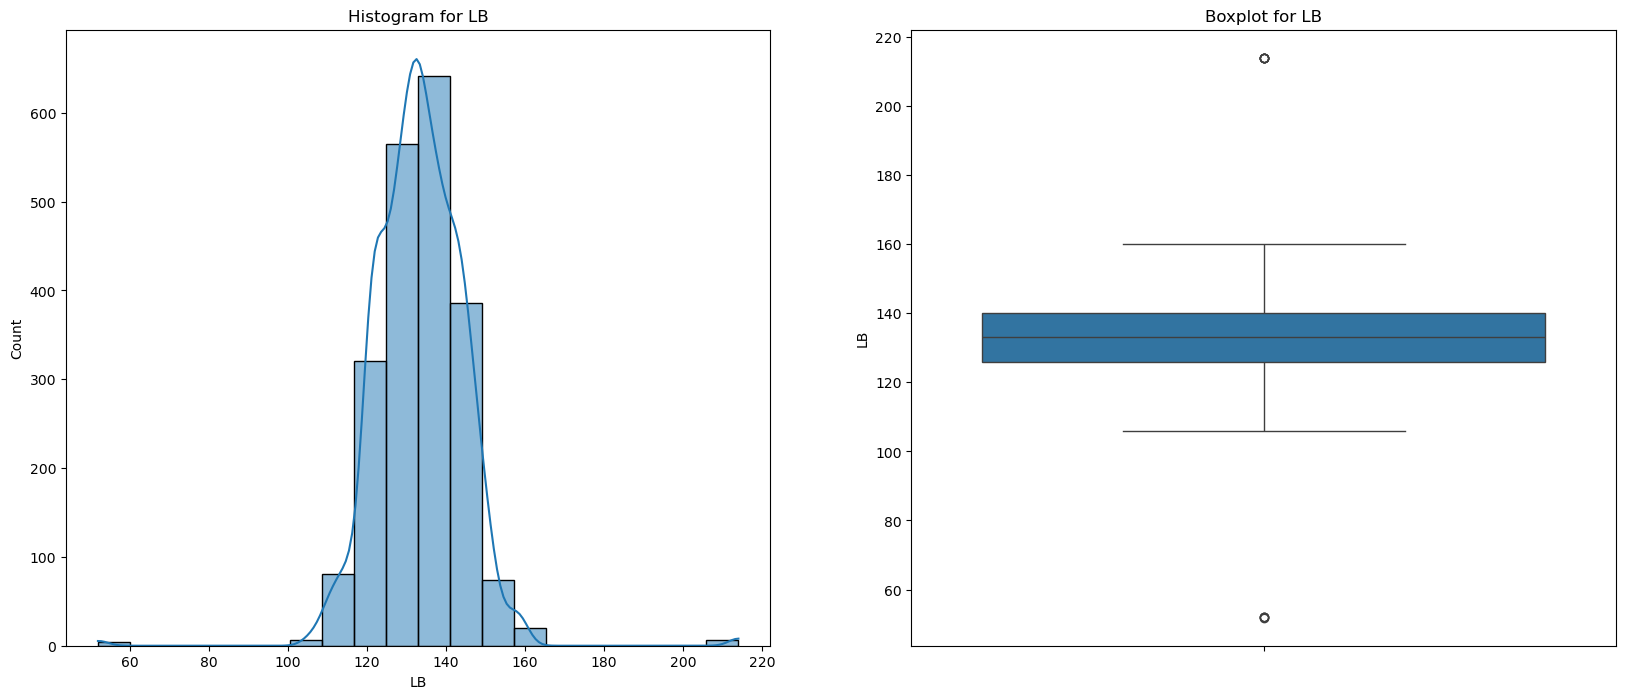

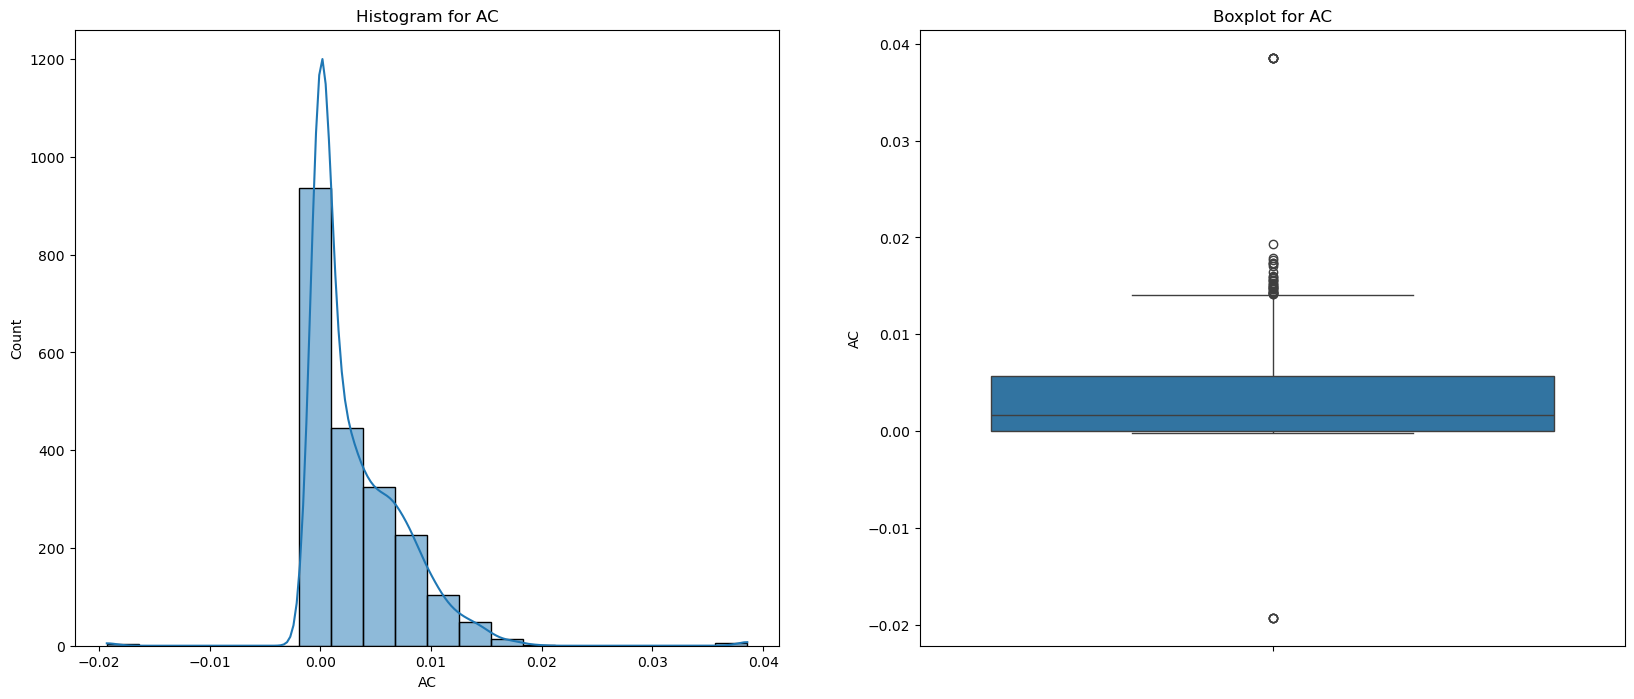

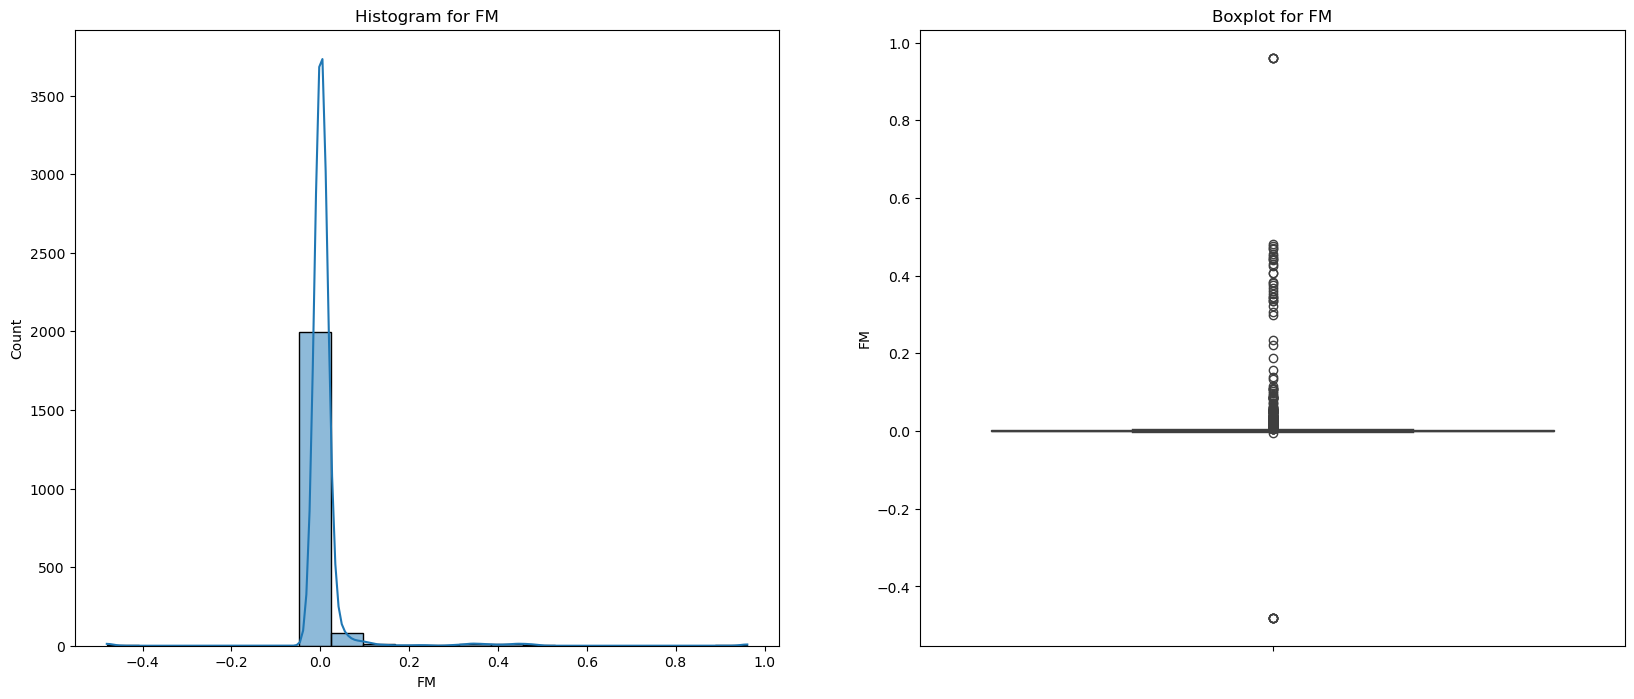

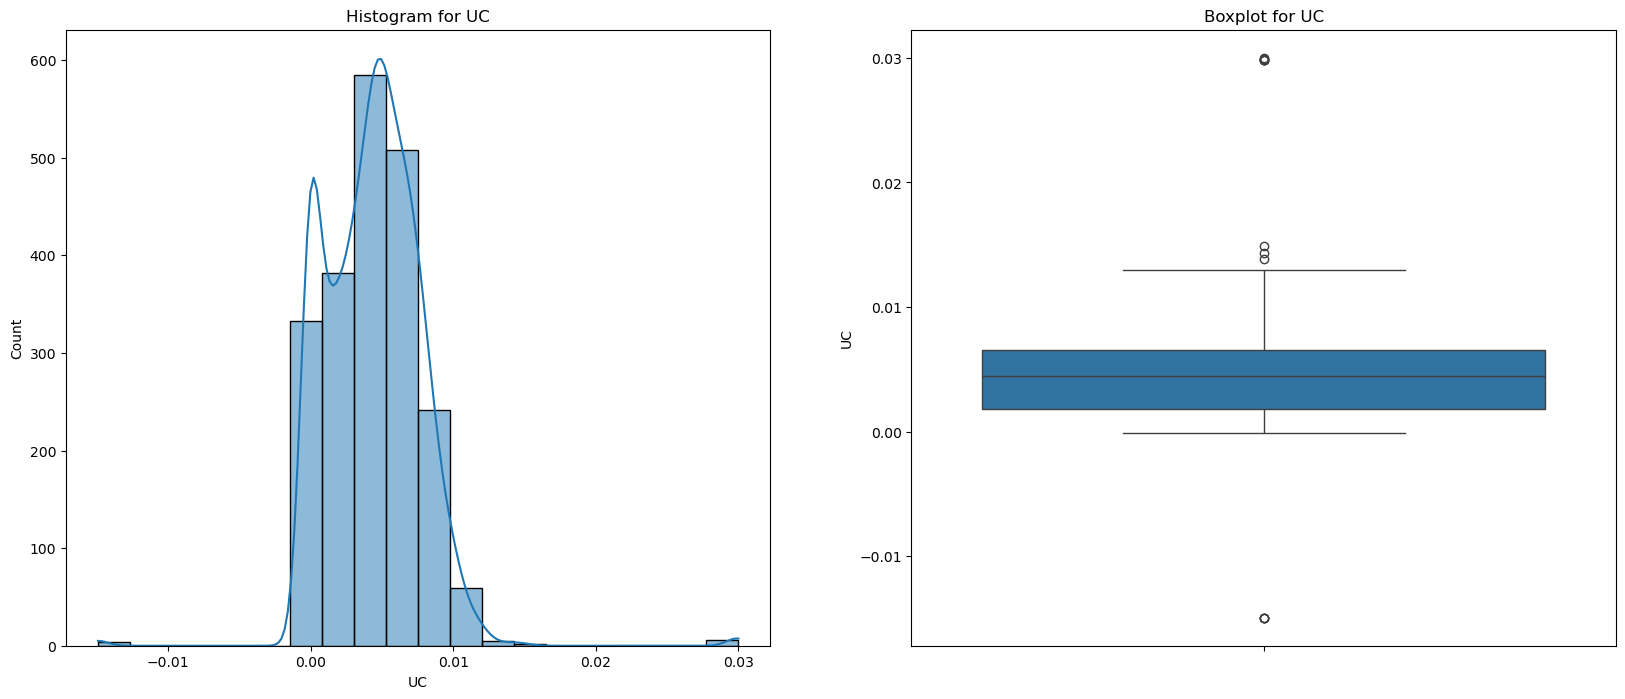

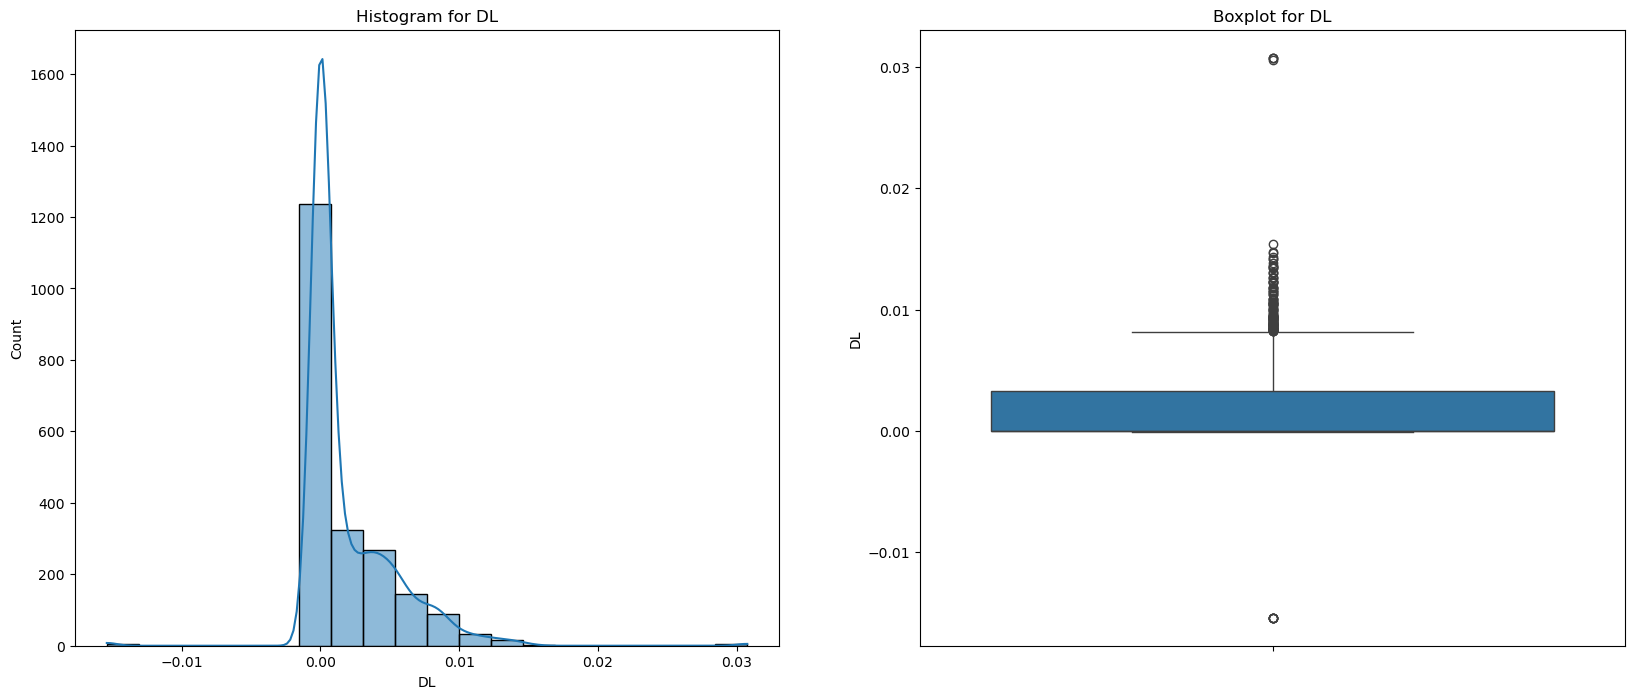

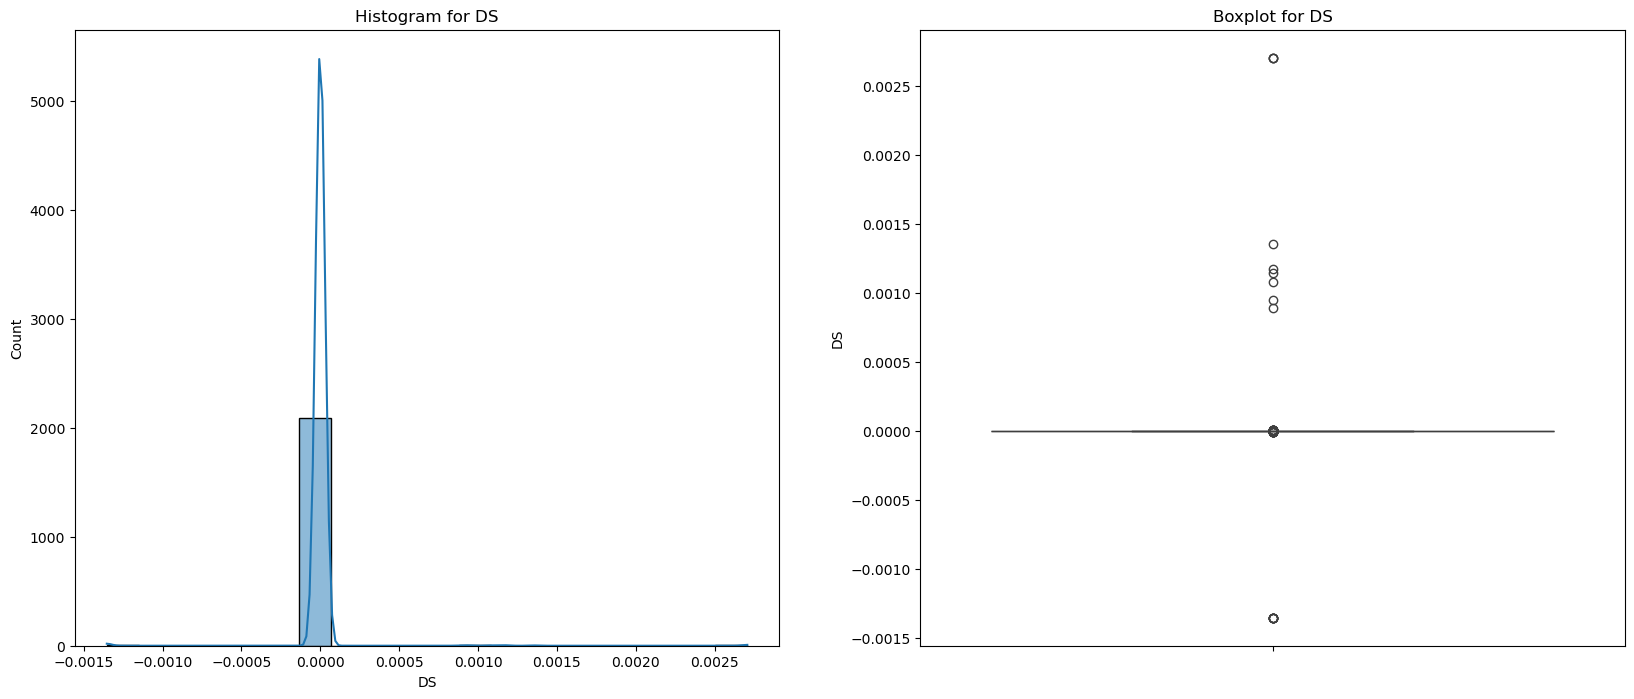

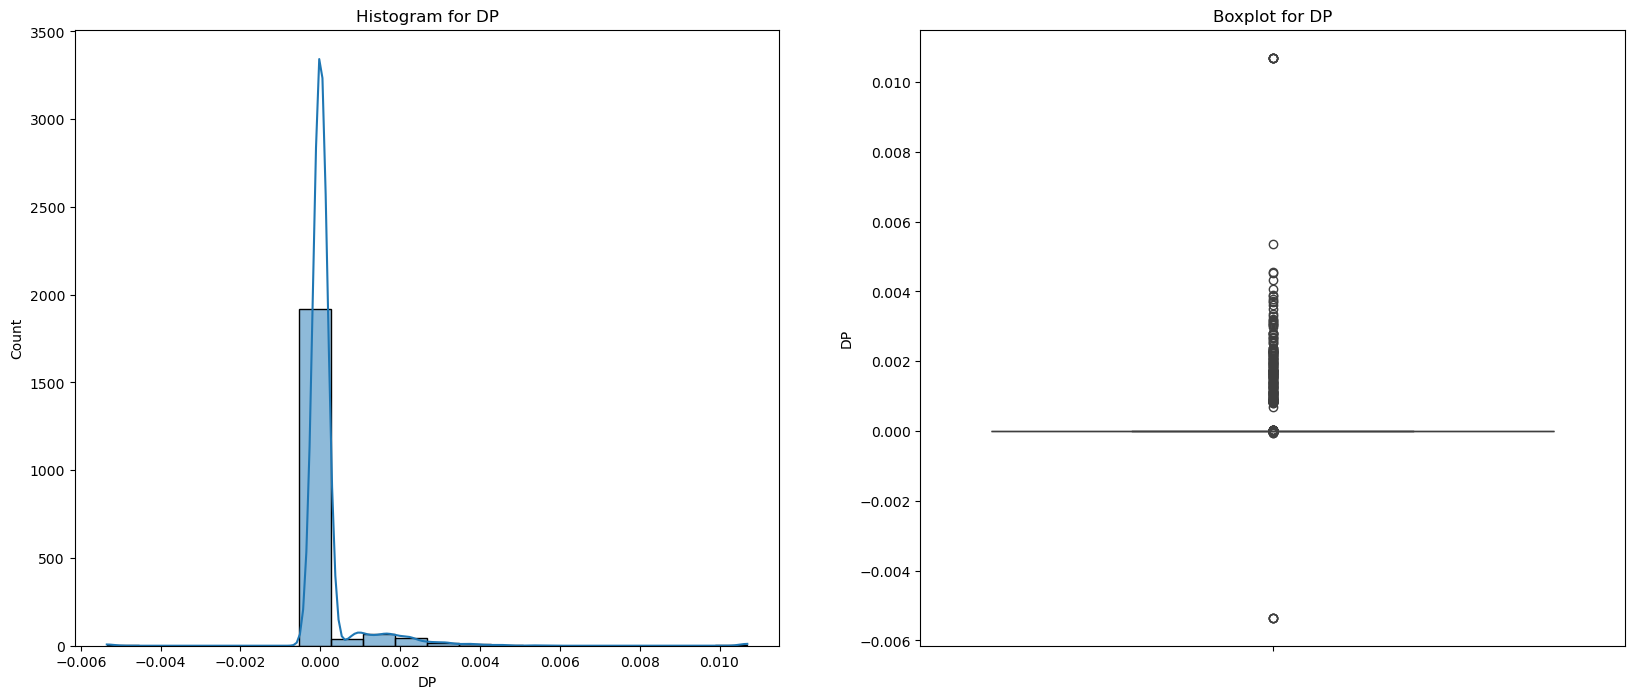

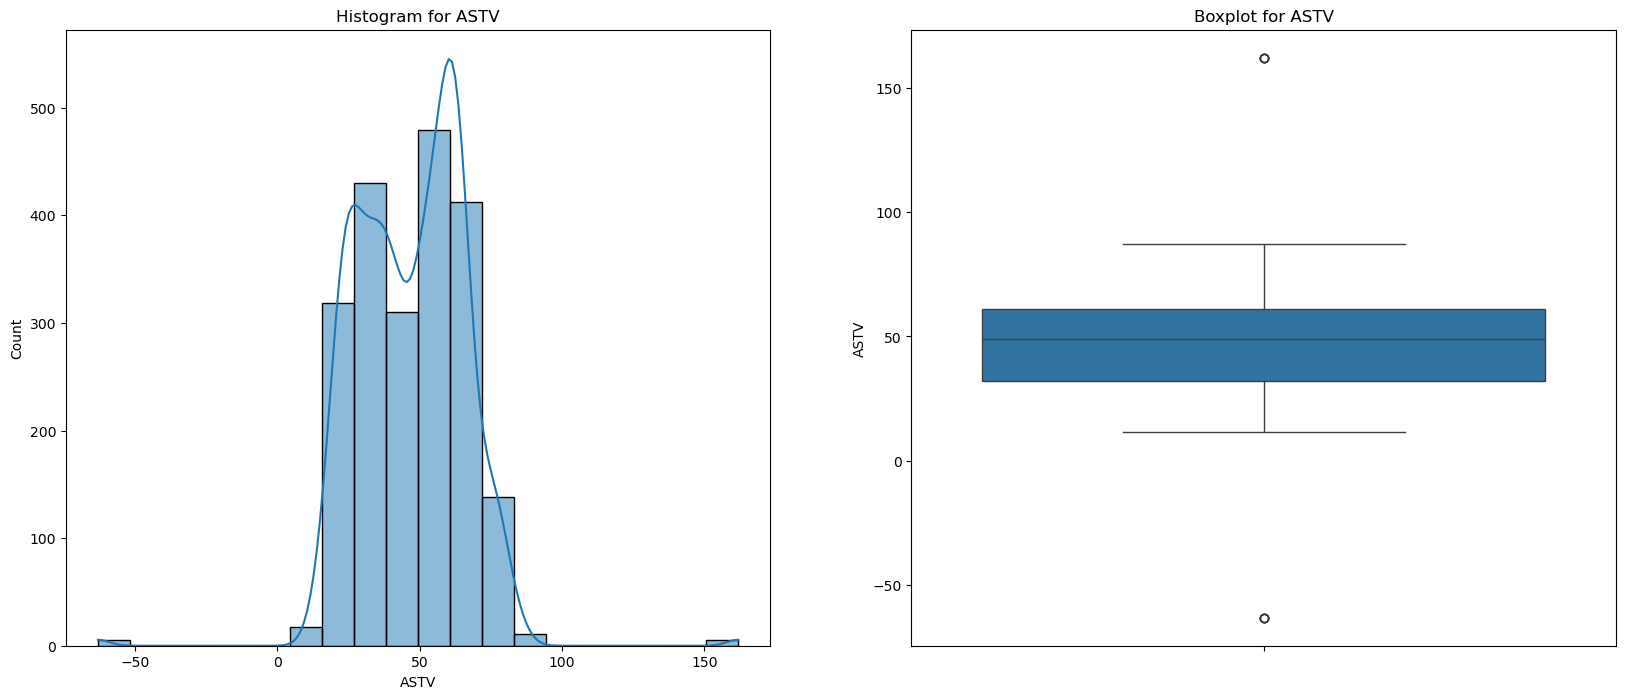

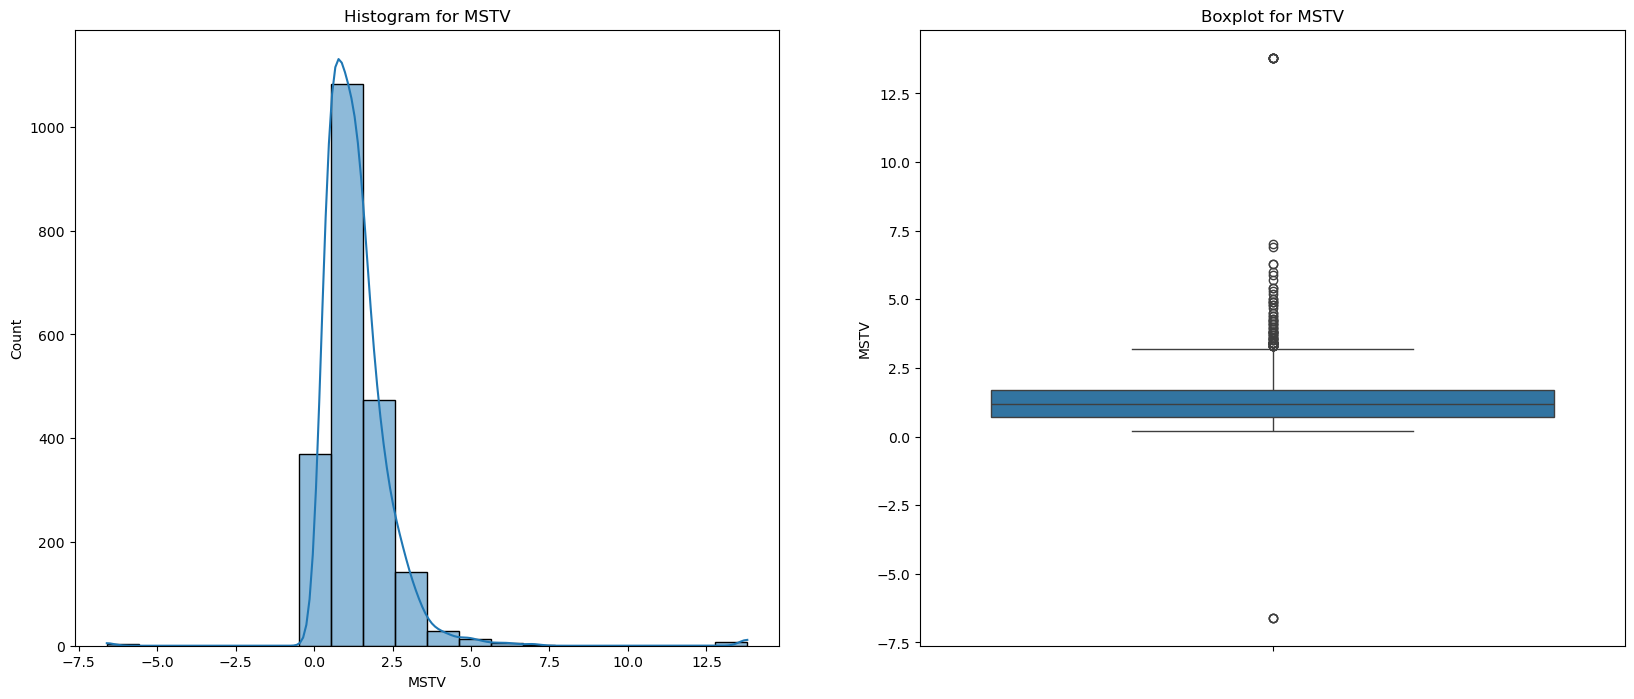

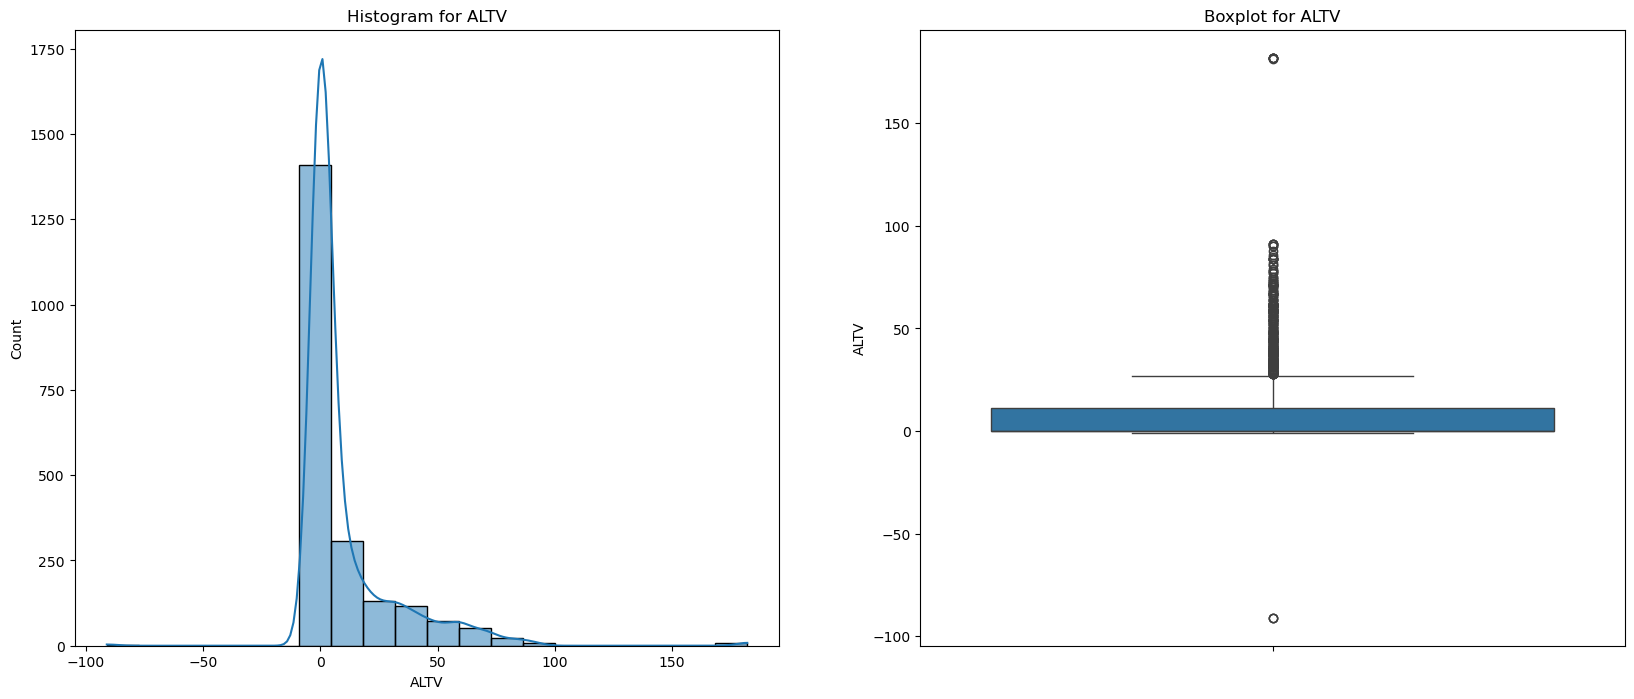

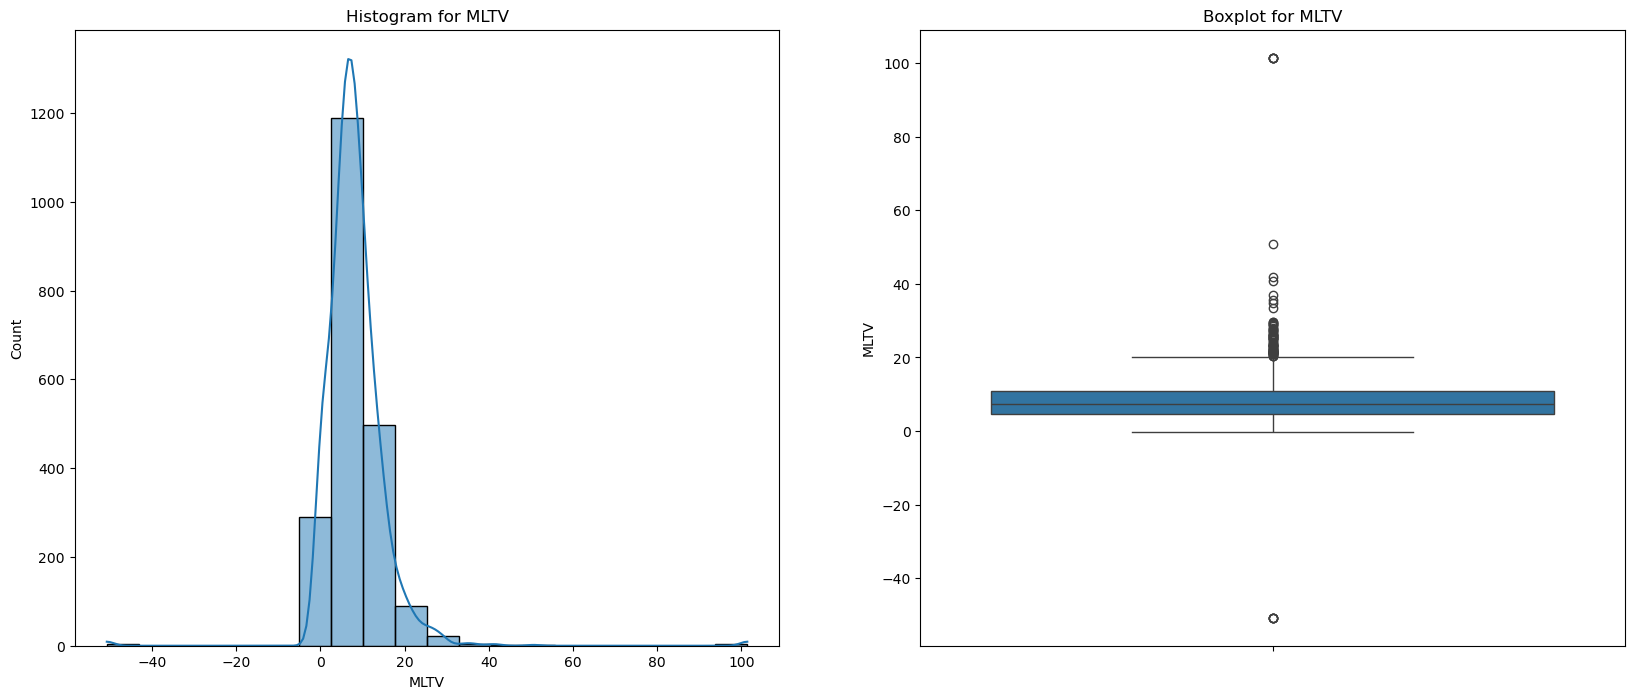

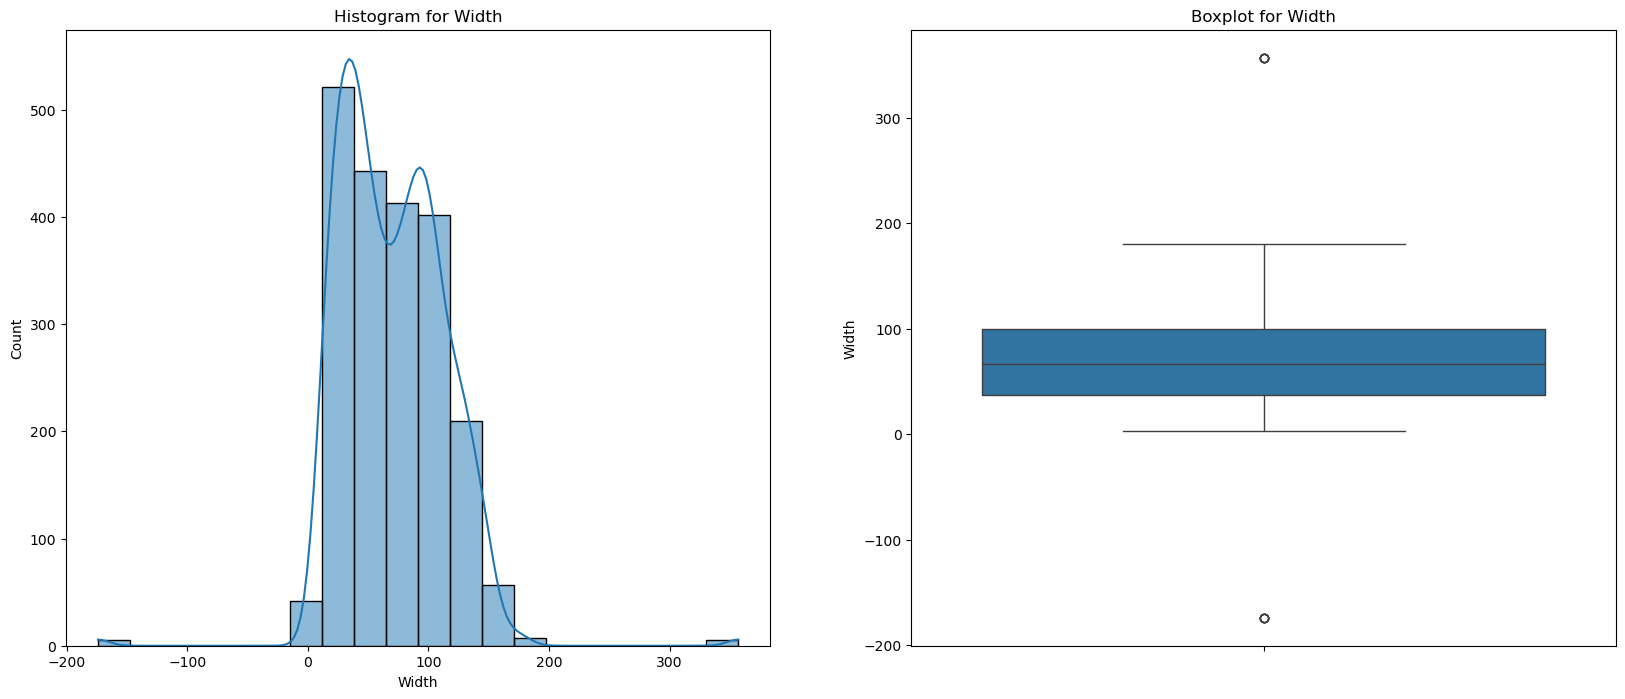

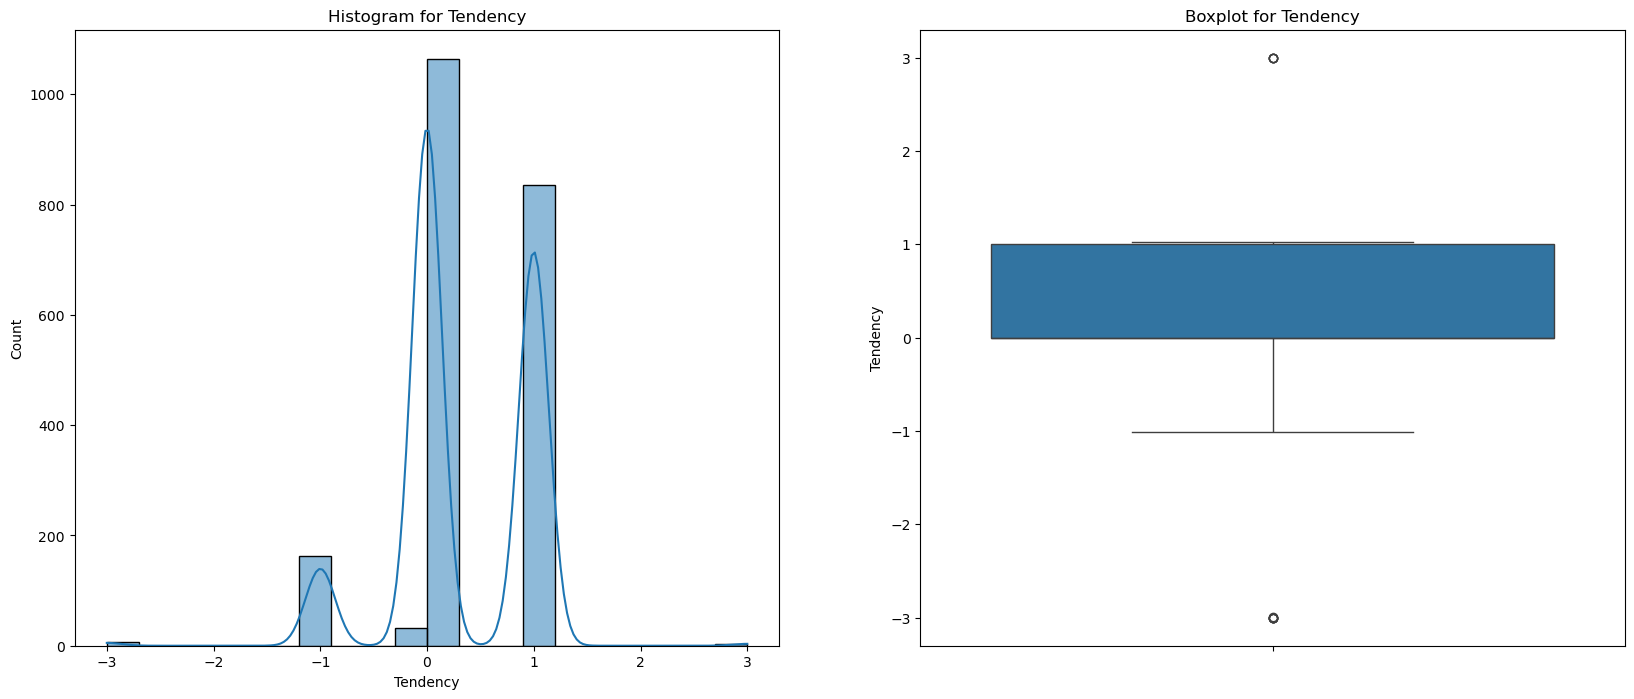

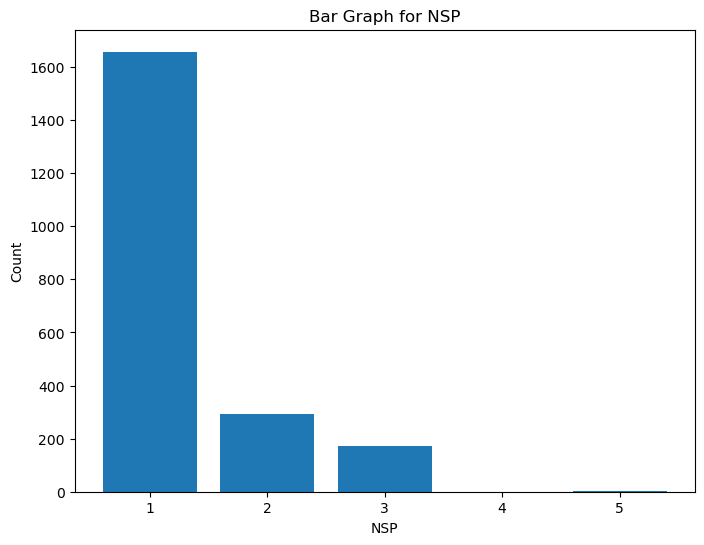

In [5]:
# Data Visualization : From data visulaization we can select,which is going to be the gootral tendency out of mean ,media, mode.
# It also helps in detecting the outliers


# Univariate data visualizaion  for numerical datasets
for col in numerical:
    plt.figure(figsize=(20,8))

    plt.subplot(1,2,1)
    plt.title(f"Histogram for {col}")
    sns.histplot(df[col],kde=True,bins=20)

    plt.subplot(1,2,2)
    plt.title(f"Boxplot for {col}")
    sns.boxplot(df[col])

    plt.show()

# Categorical data visuaization using the bar plot
categories = df[categorical].value_counts().index  # Unique NSP categories (e.g., [1, 2, 3])
heights = df[categorical].value_counts().values    # Counts for each category


plt.figure(figsize=(8, 6))
plt.bar(categories, heights)
plt.title(f'Bar Graph for {categorical}')
plt.xlabel(categorical)
plt.ylabel('Count')
plt.show()

### Bivariate Analysis : To check Relationship between the variables 

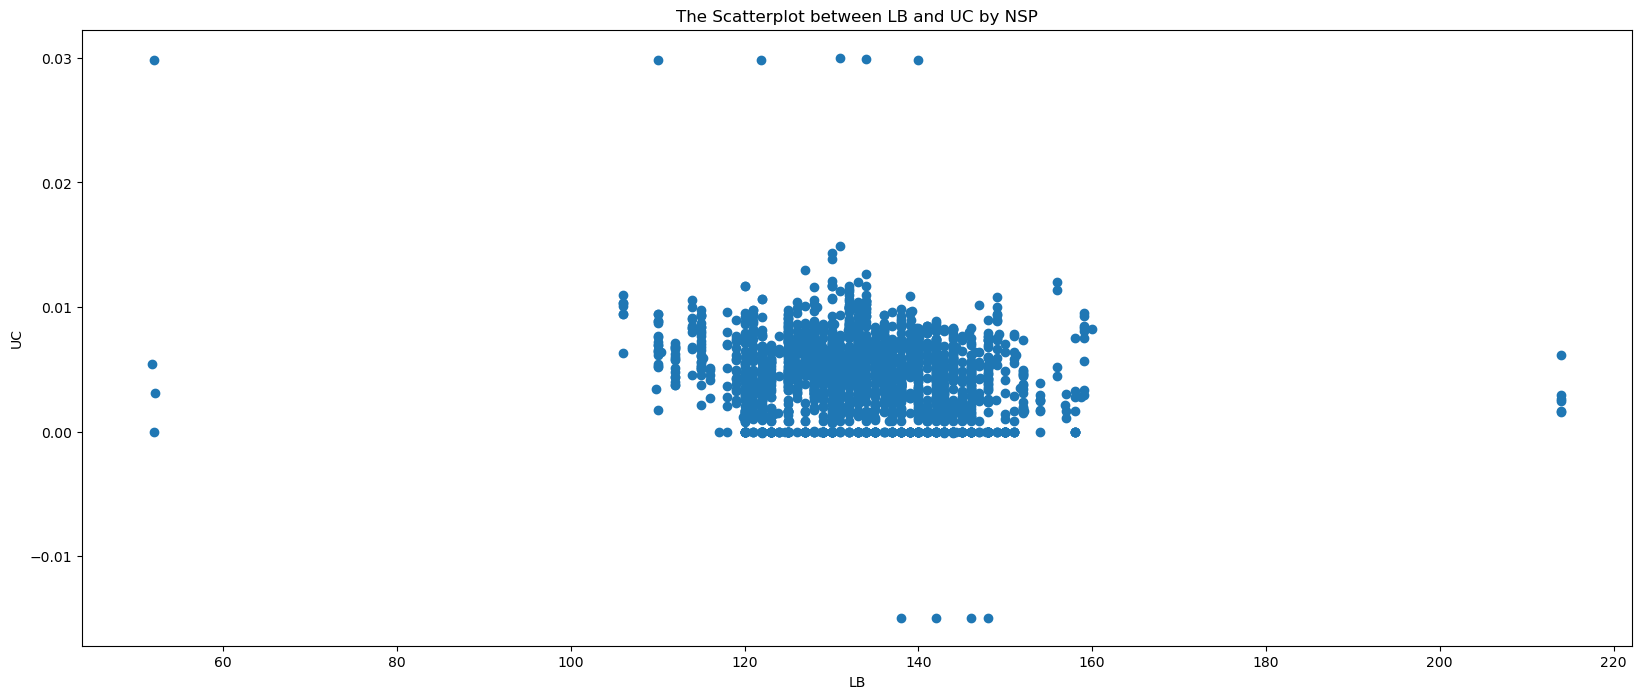

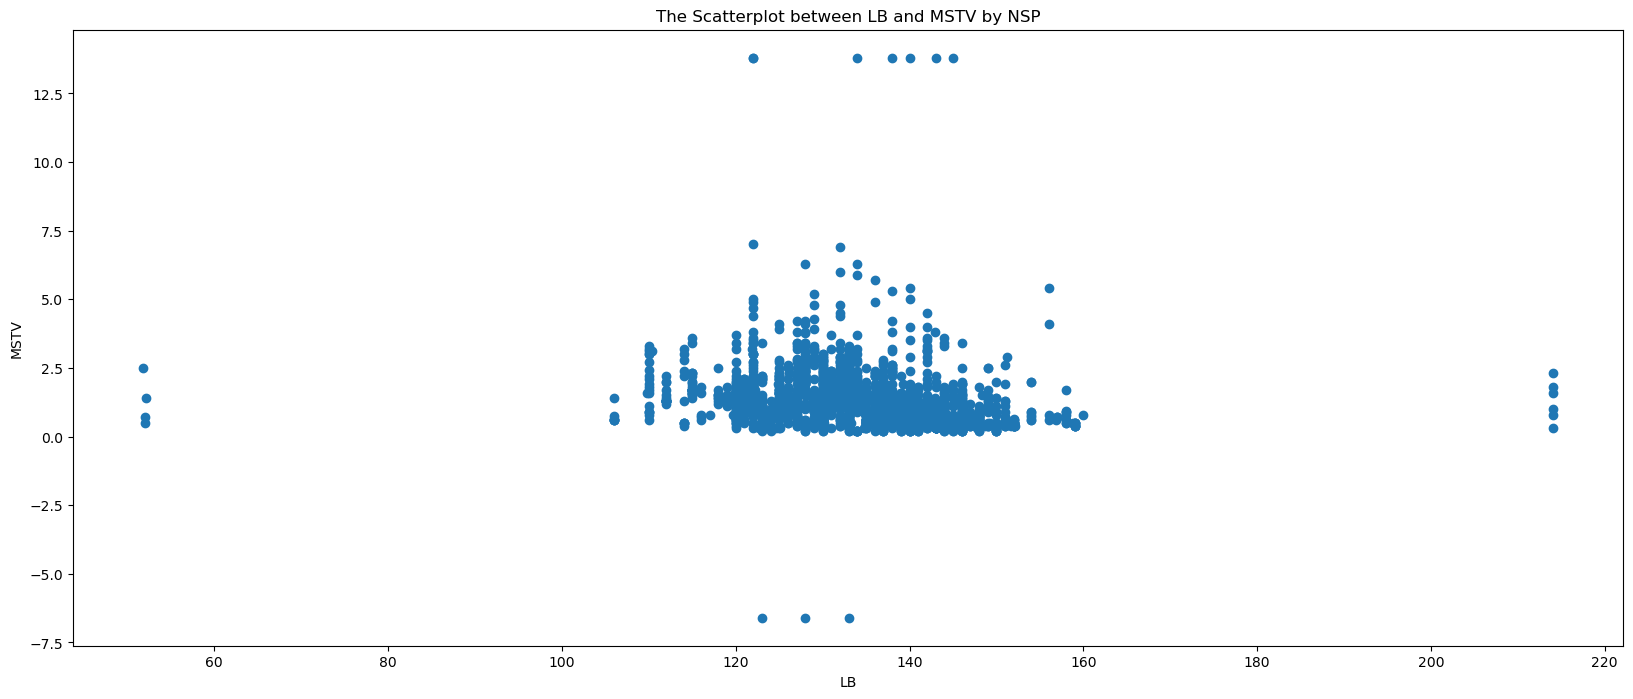

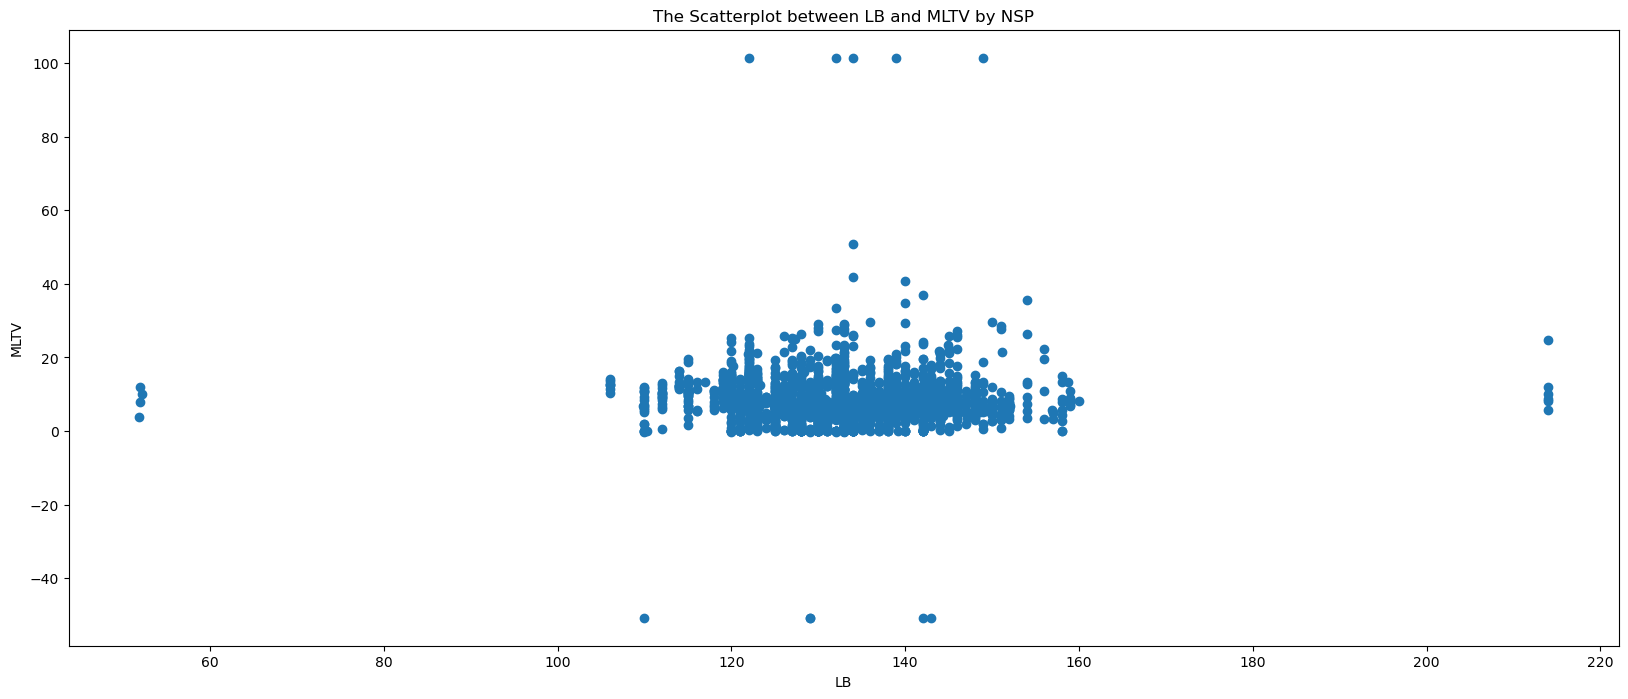

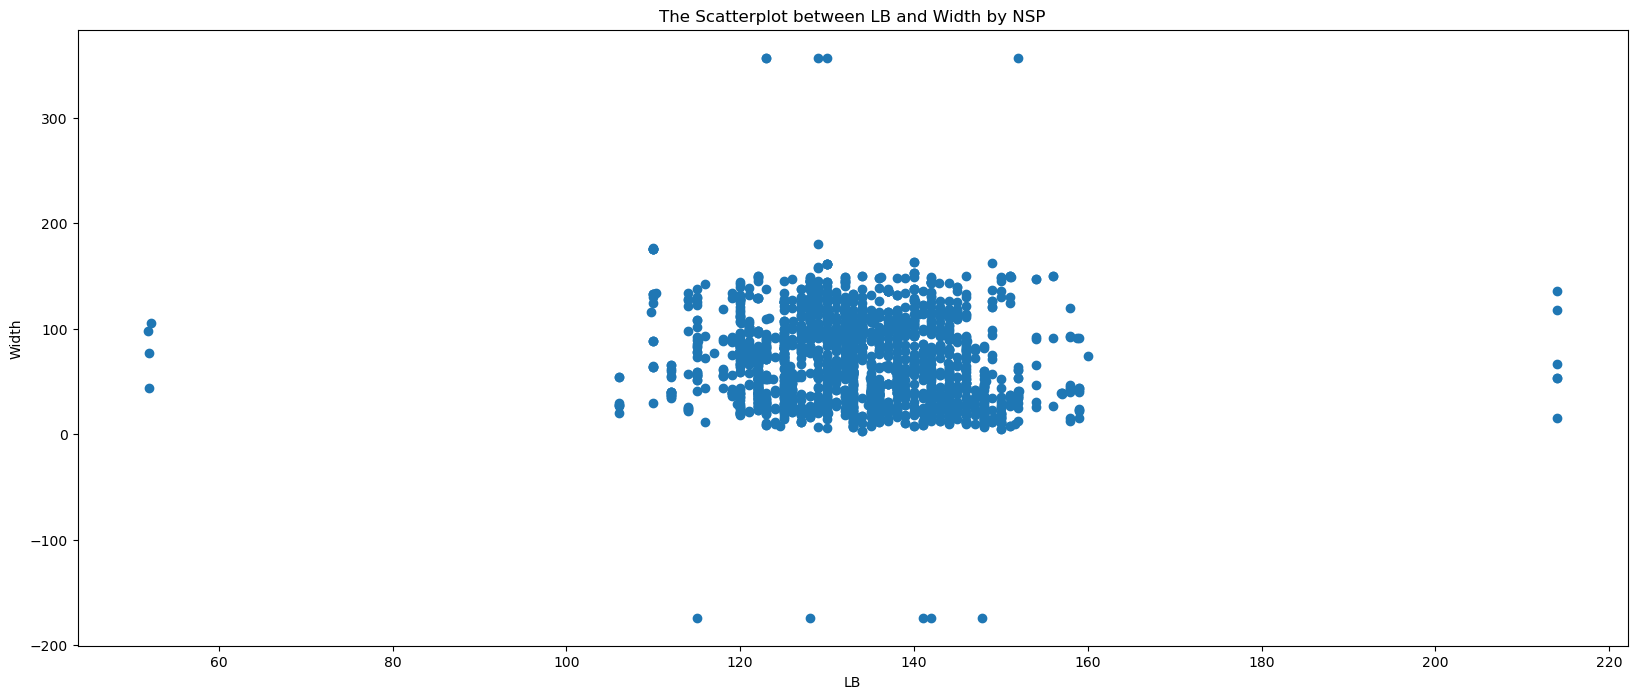

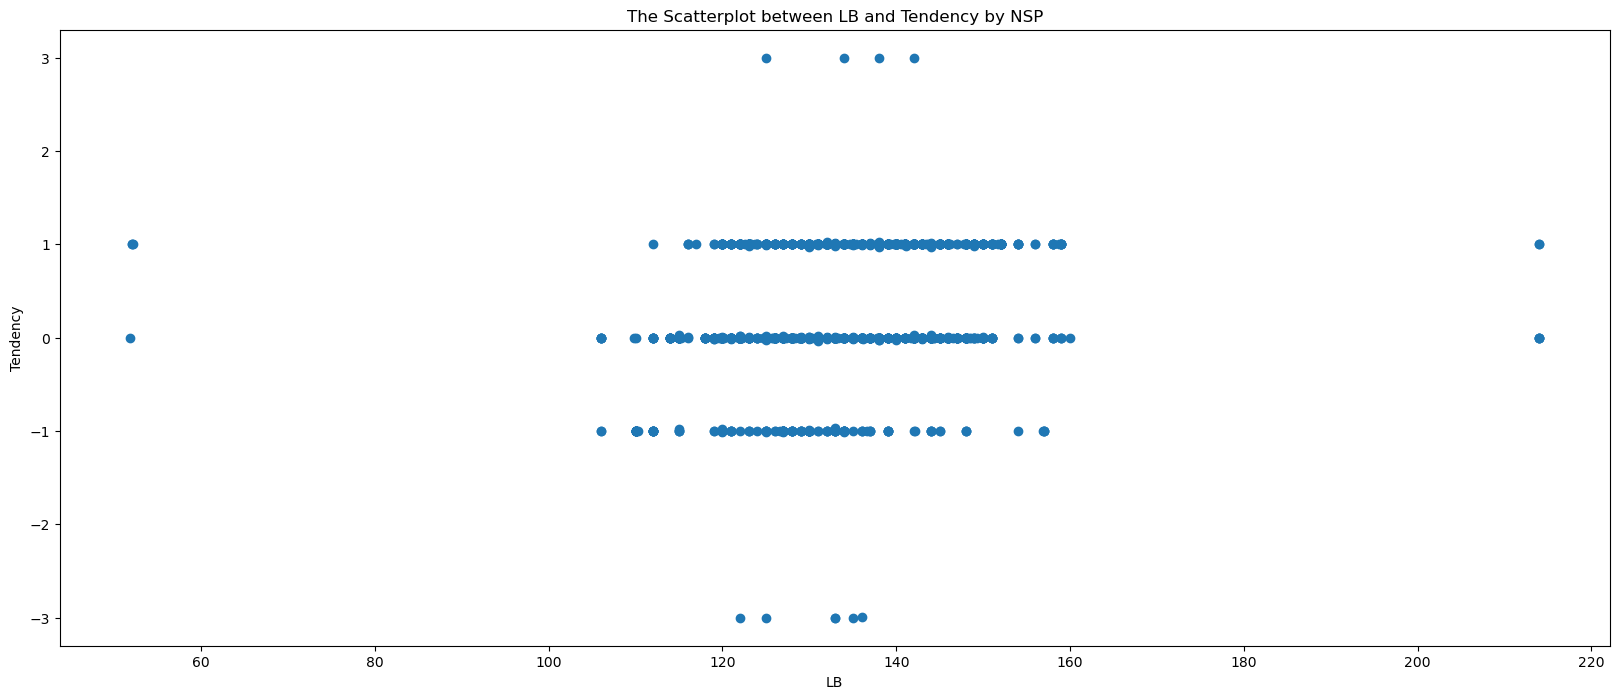

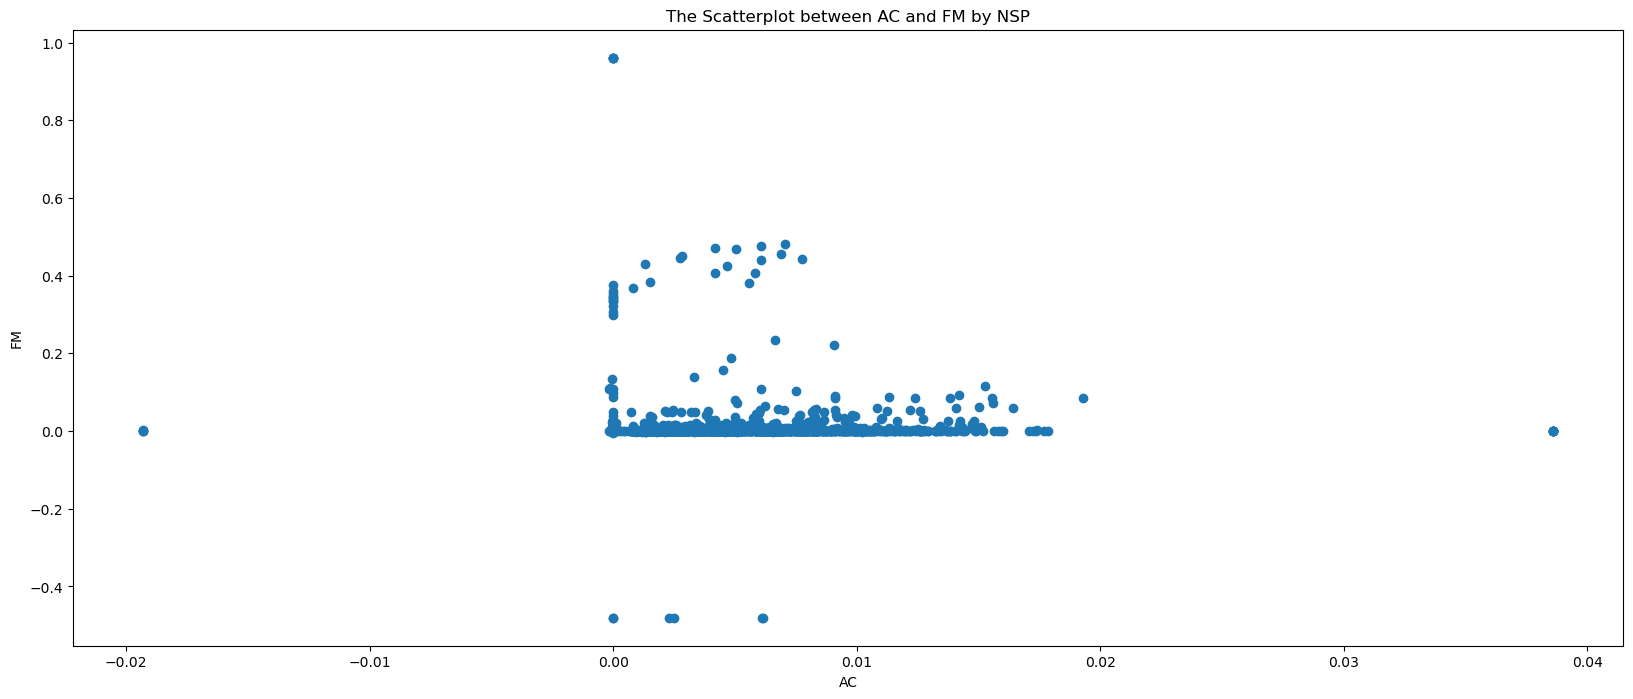

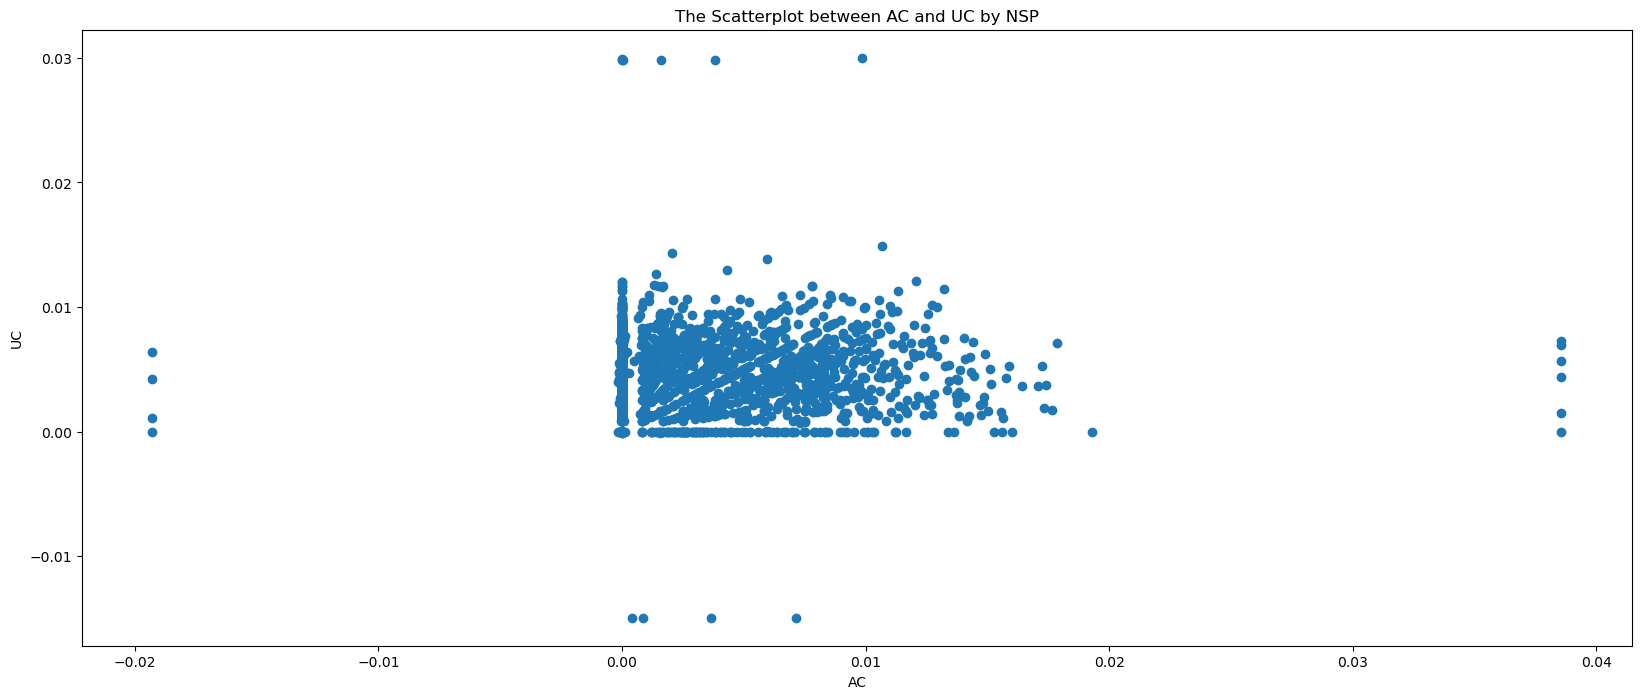

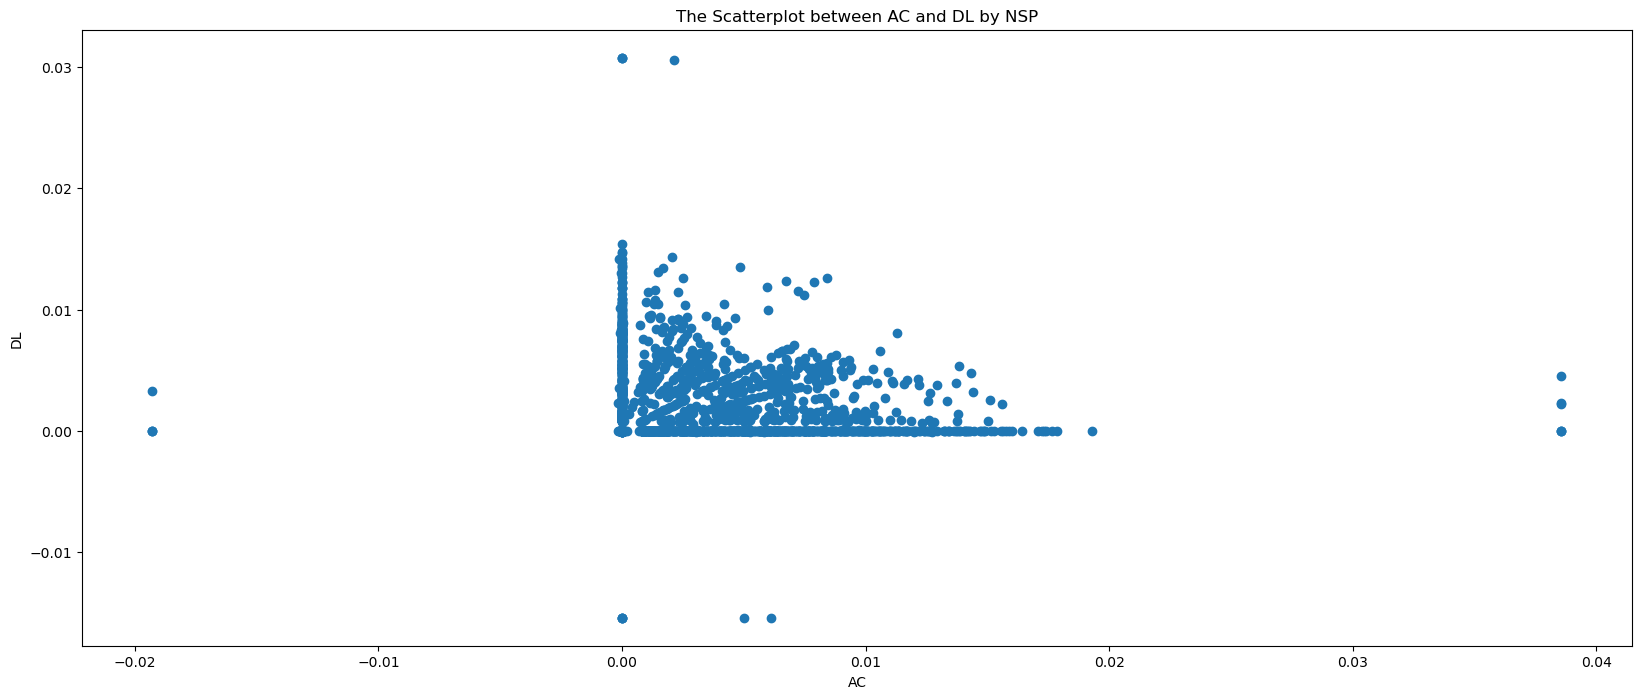

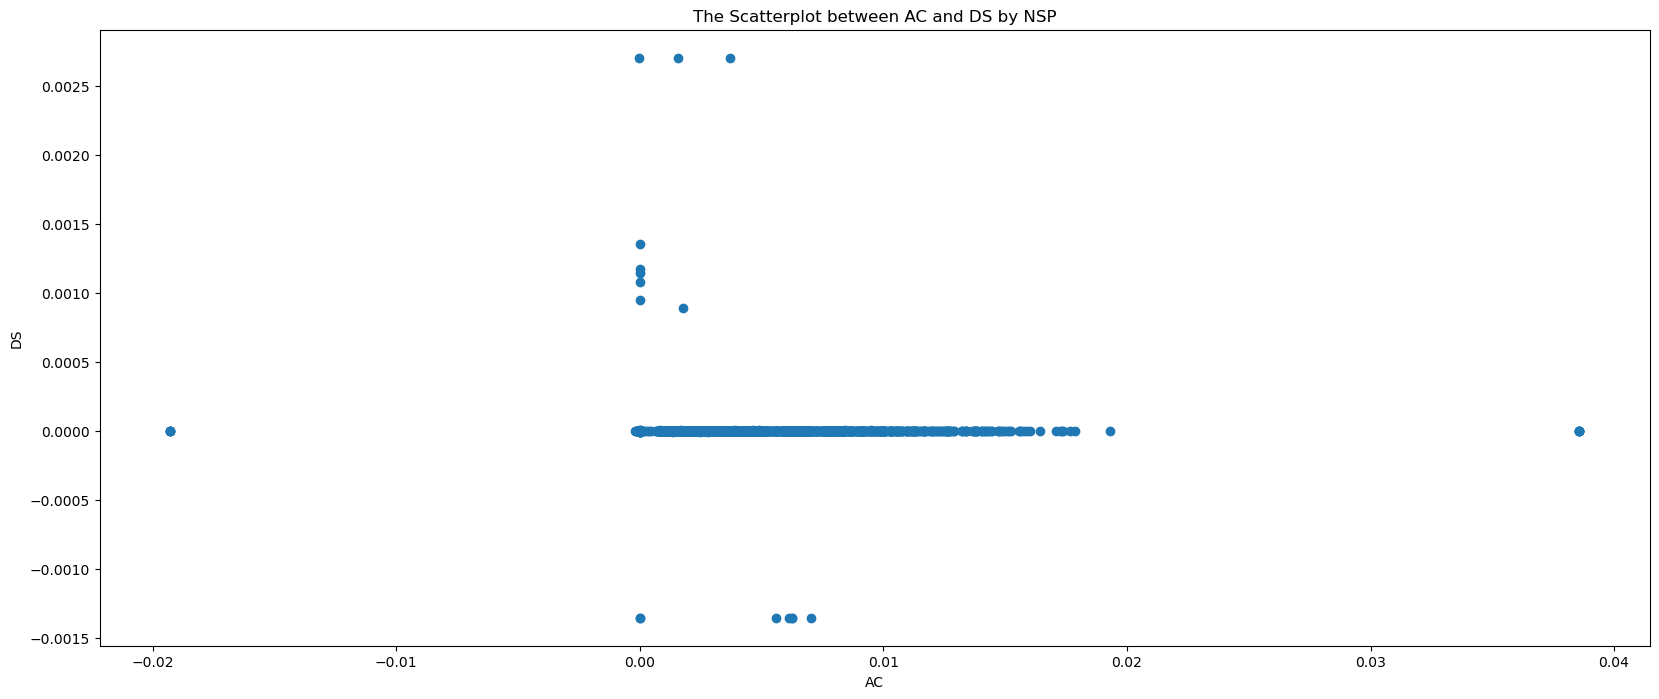

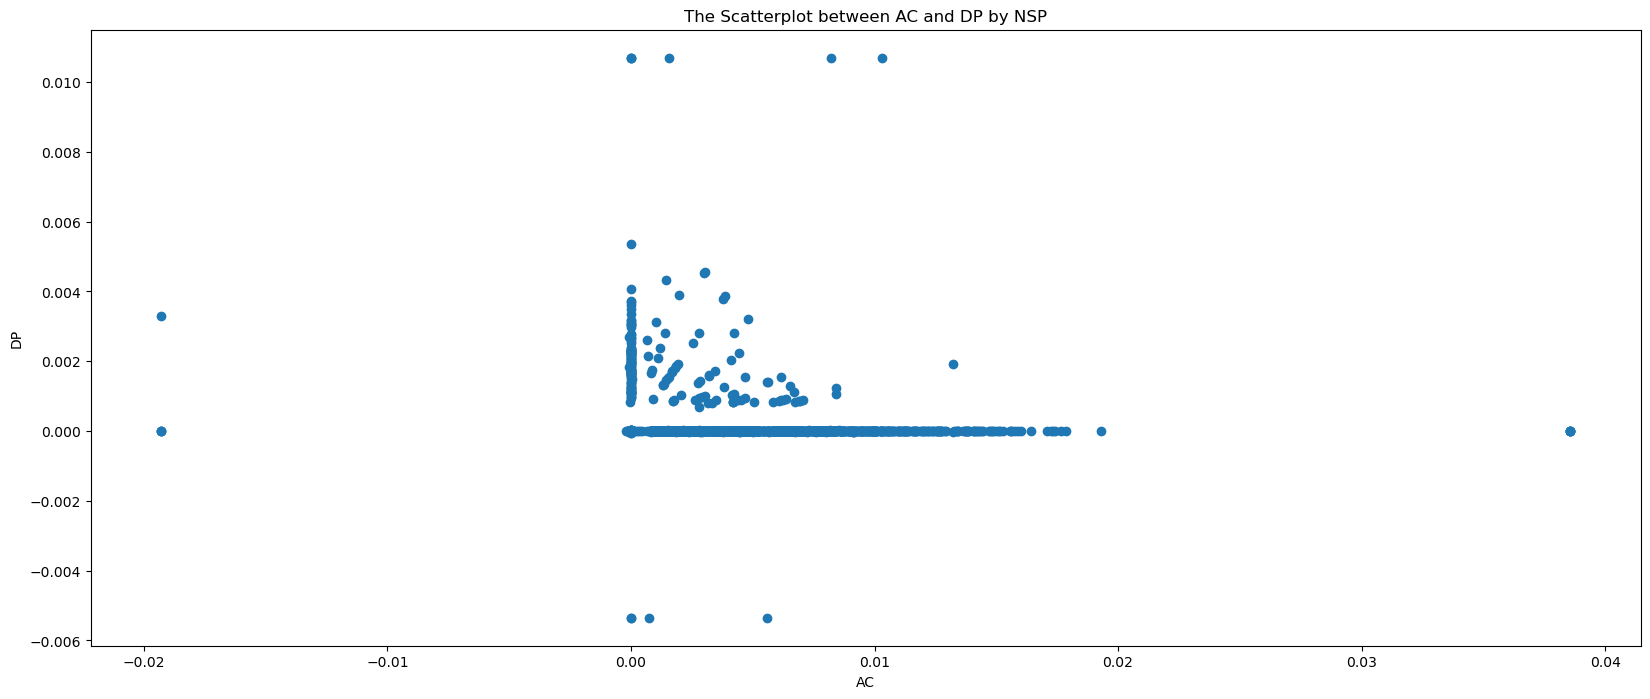

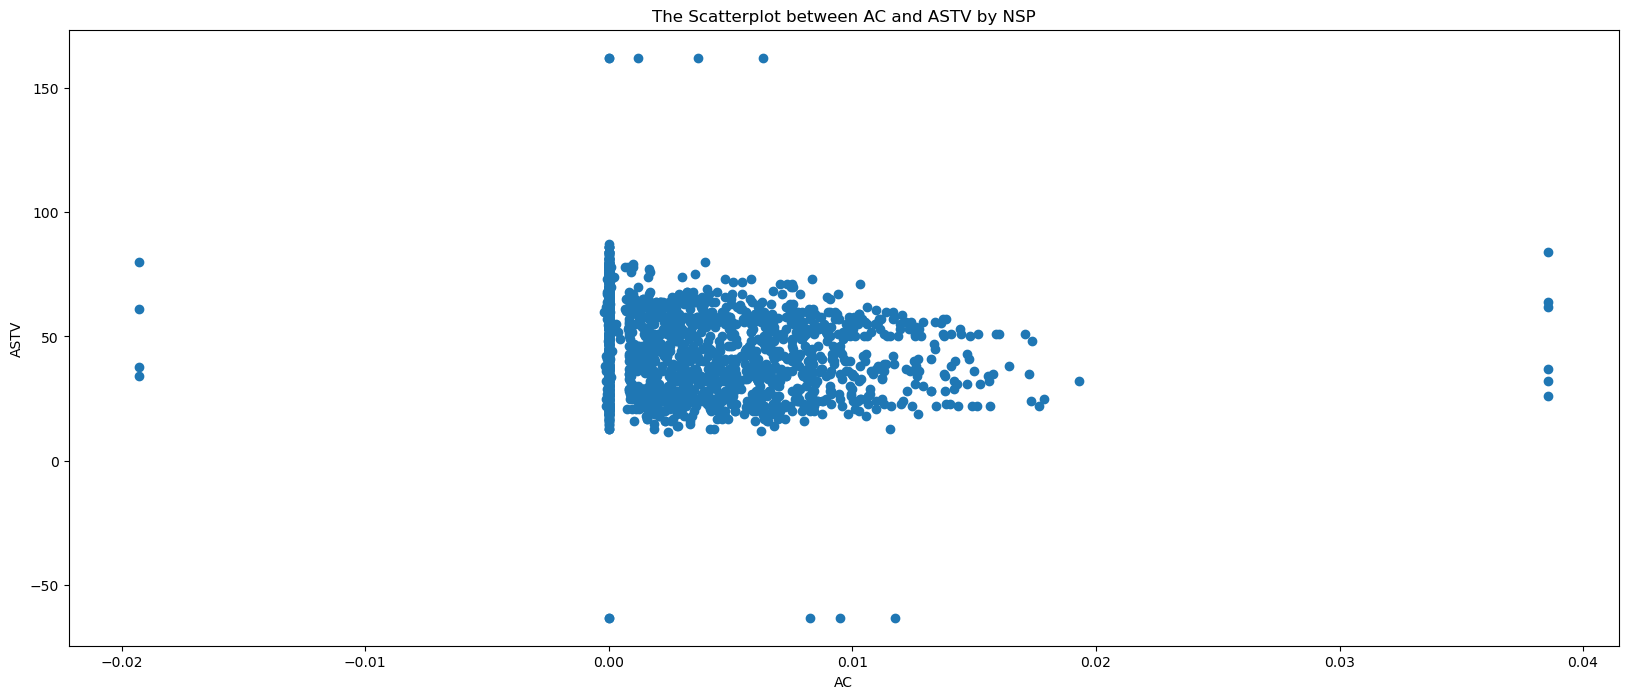

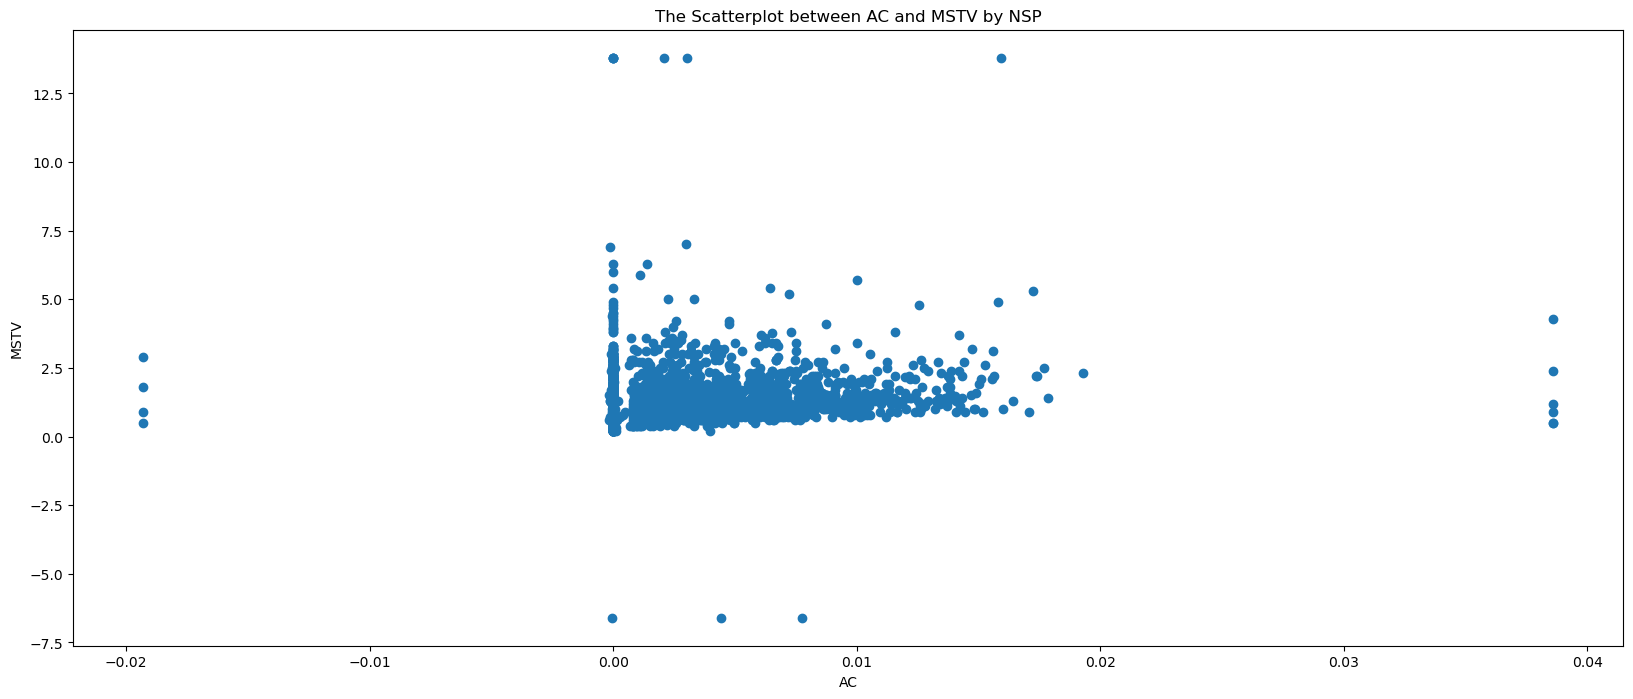

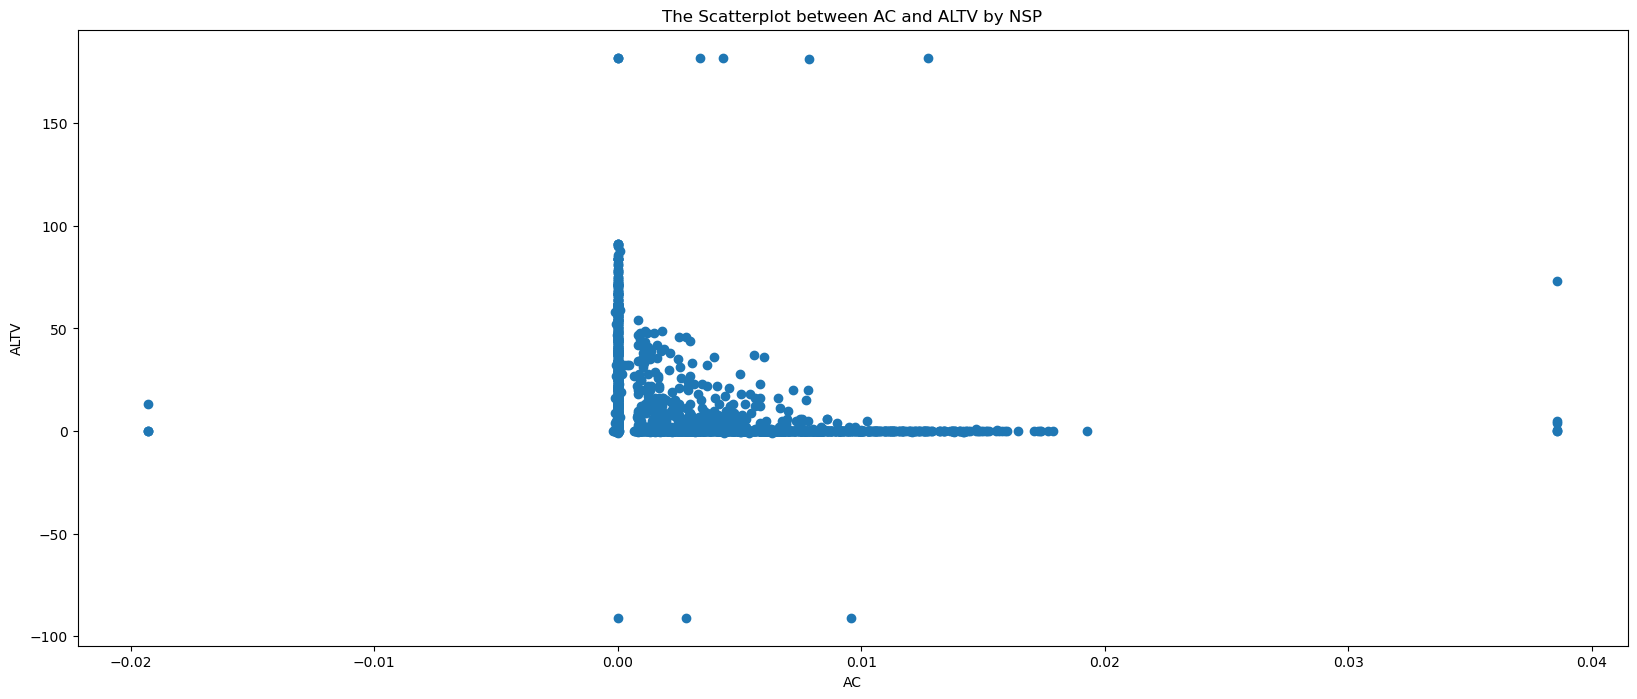

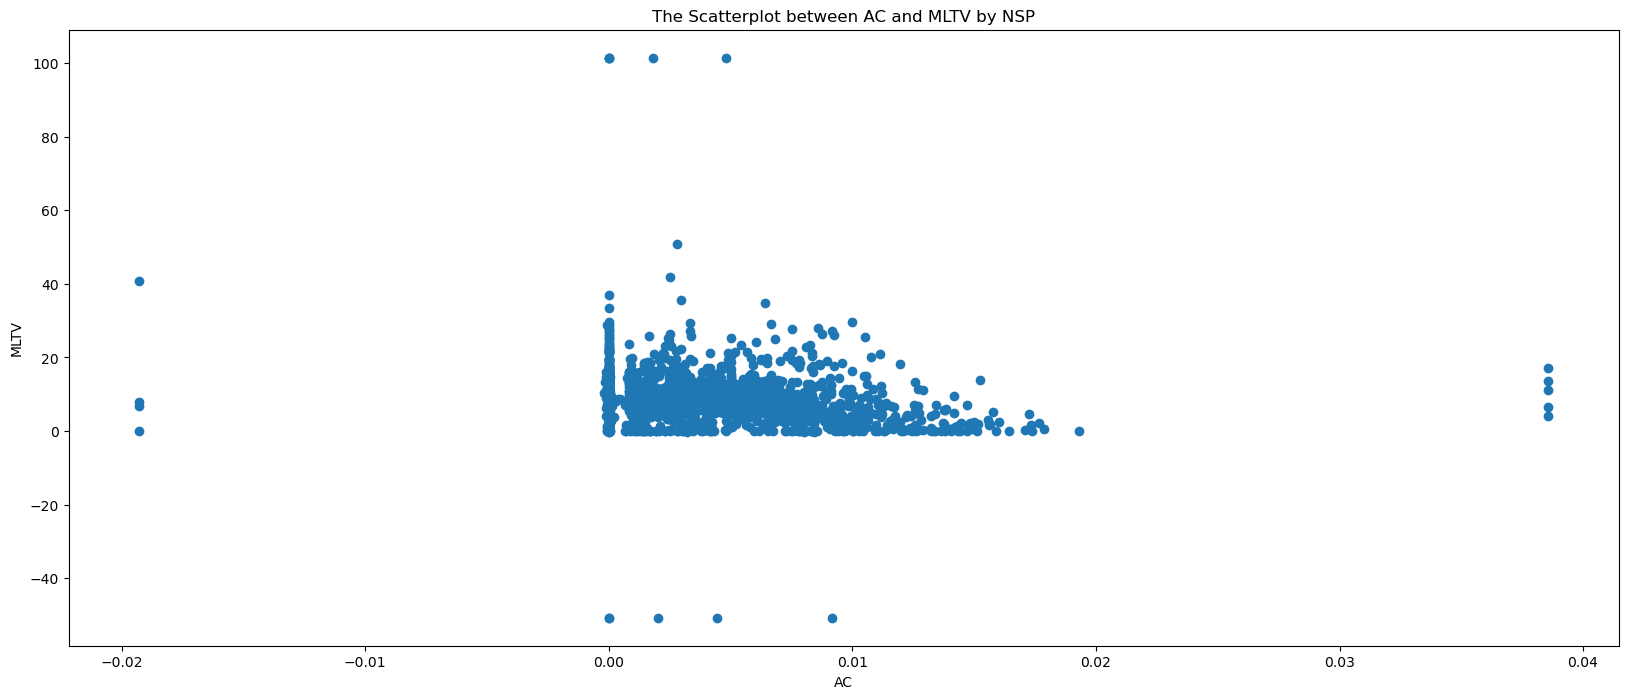

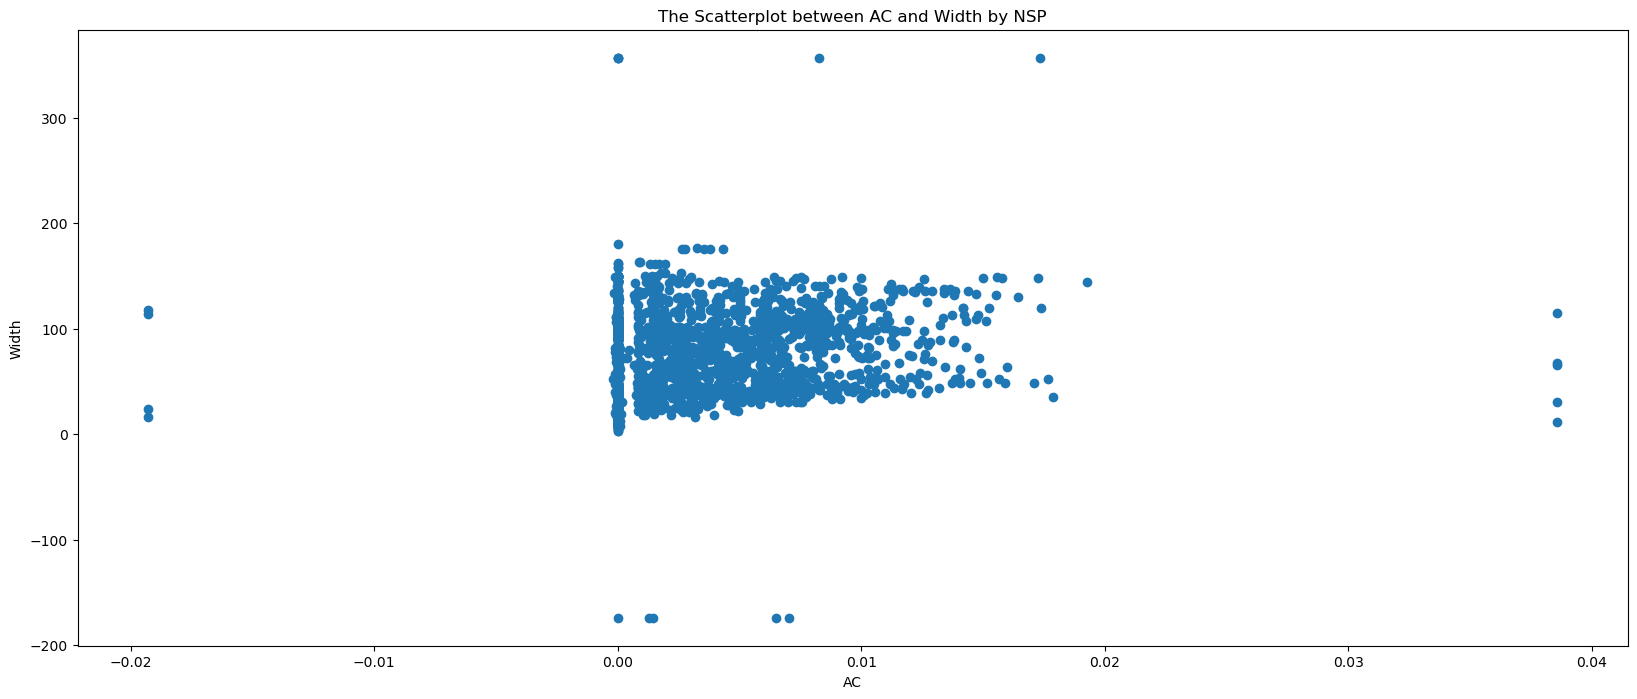

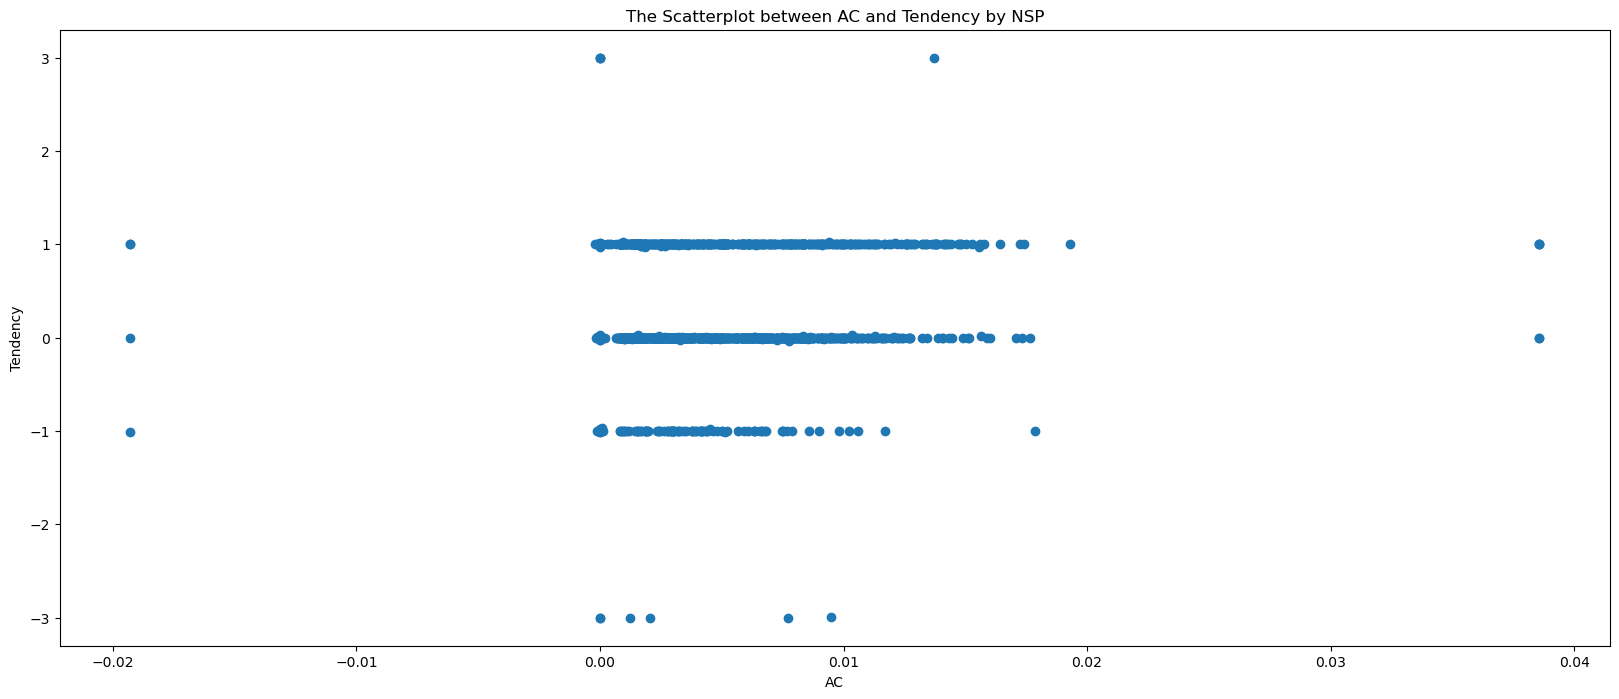

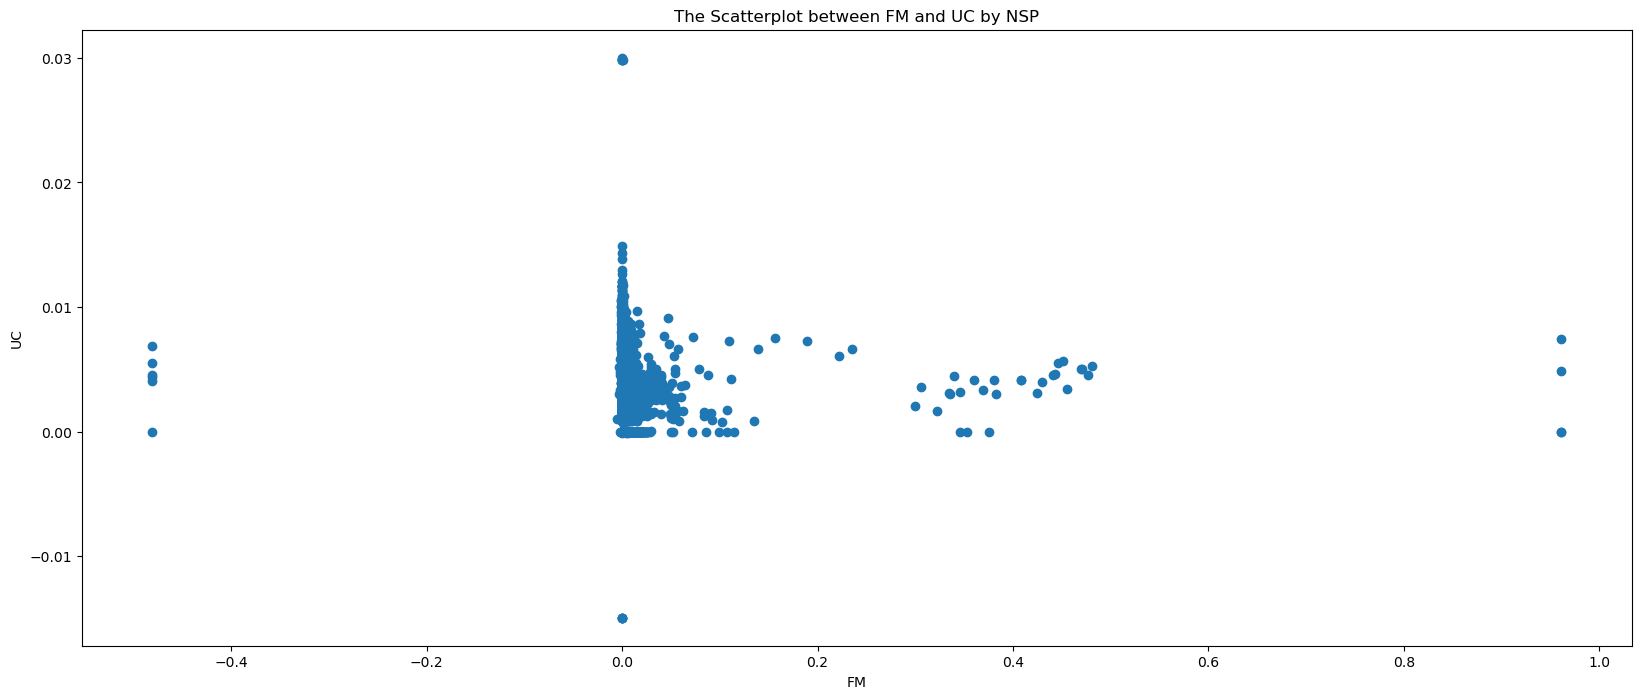

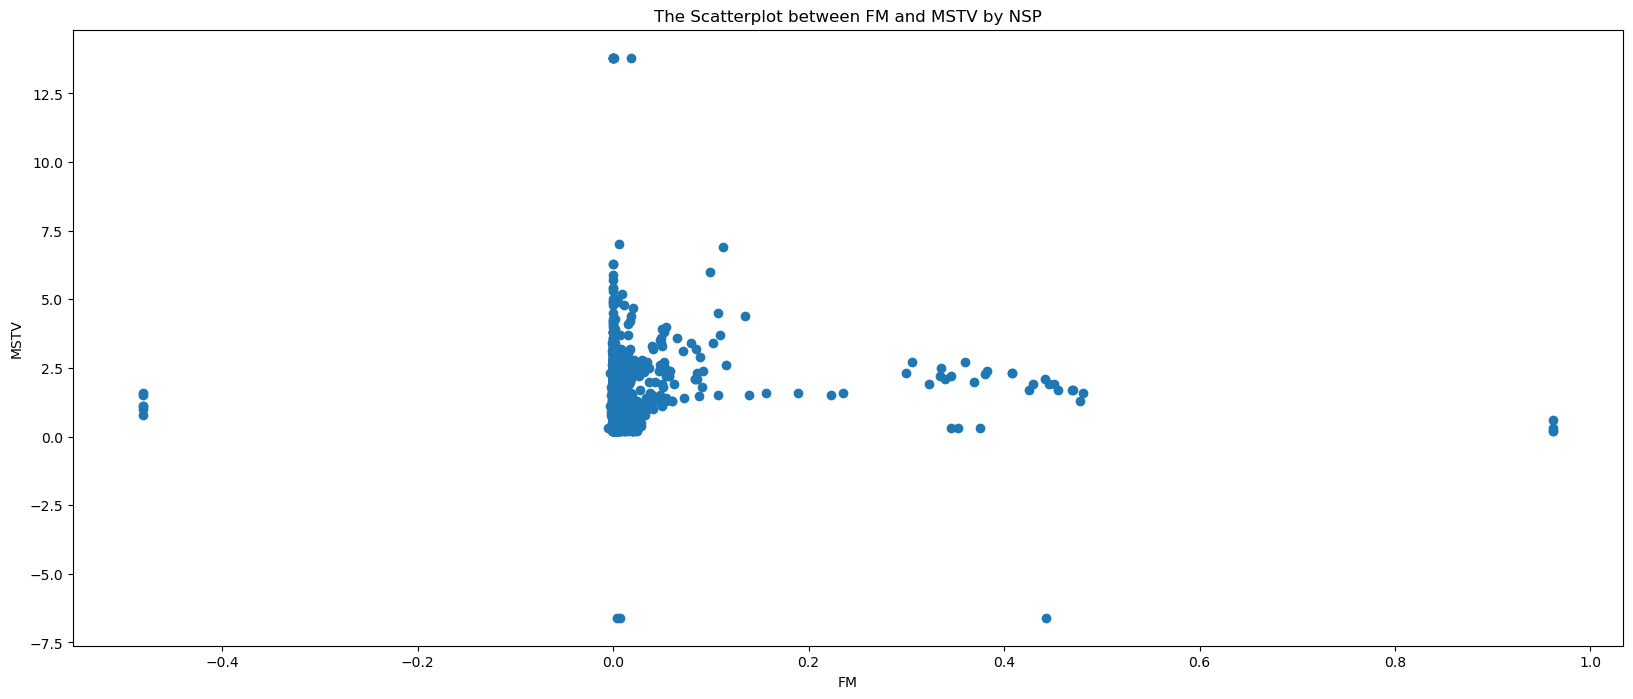

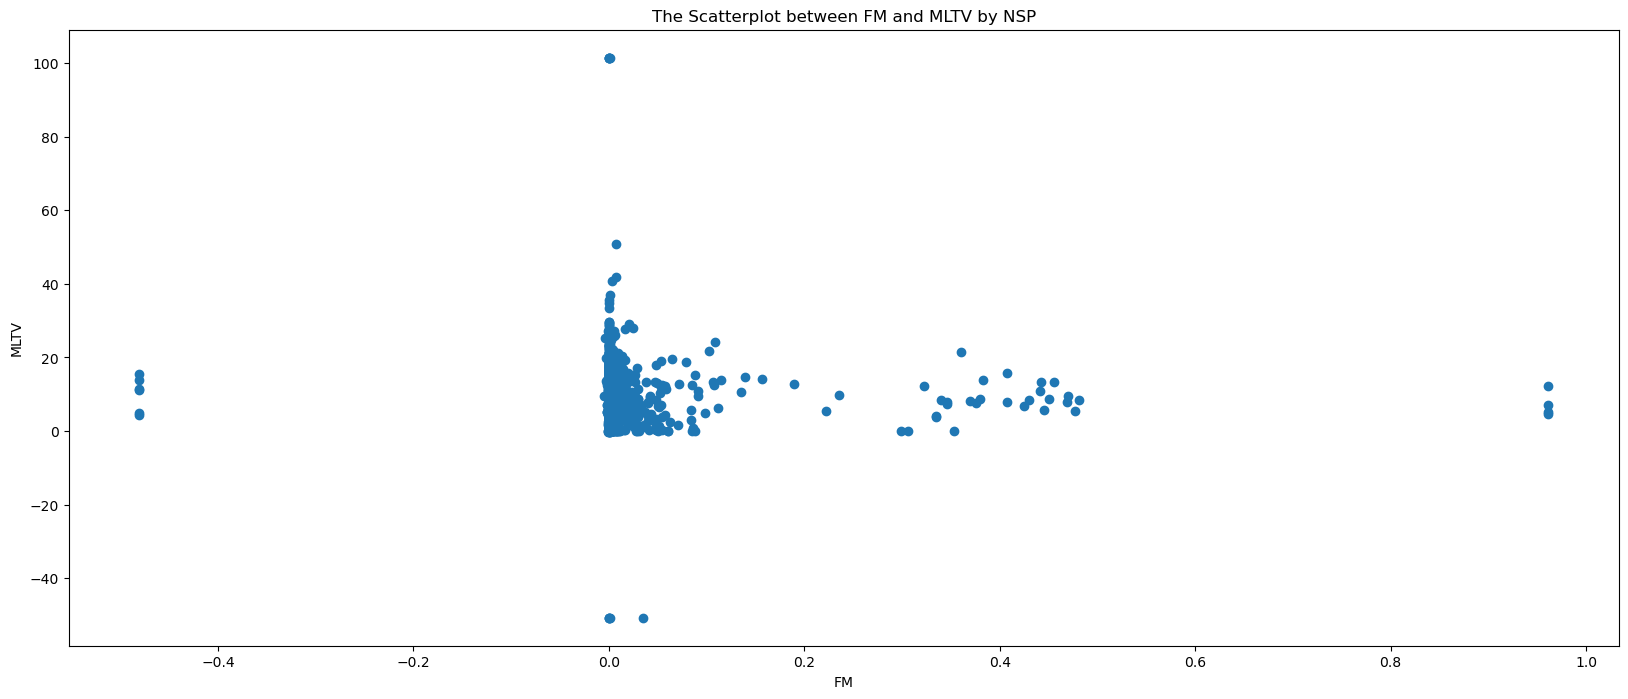

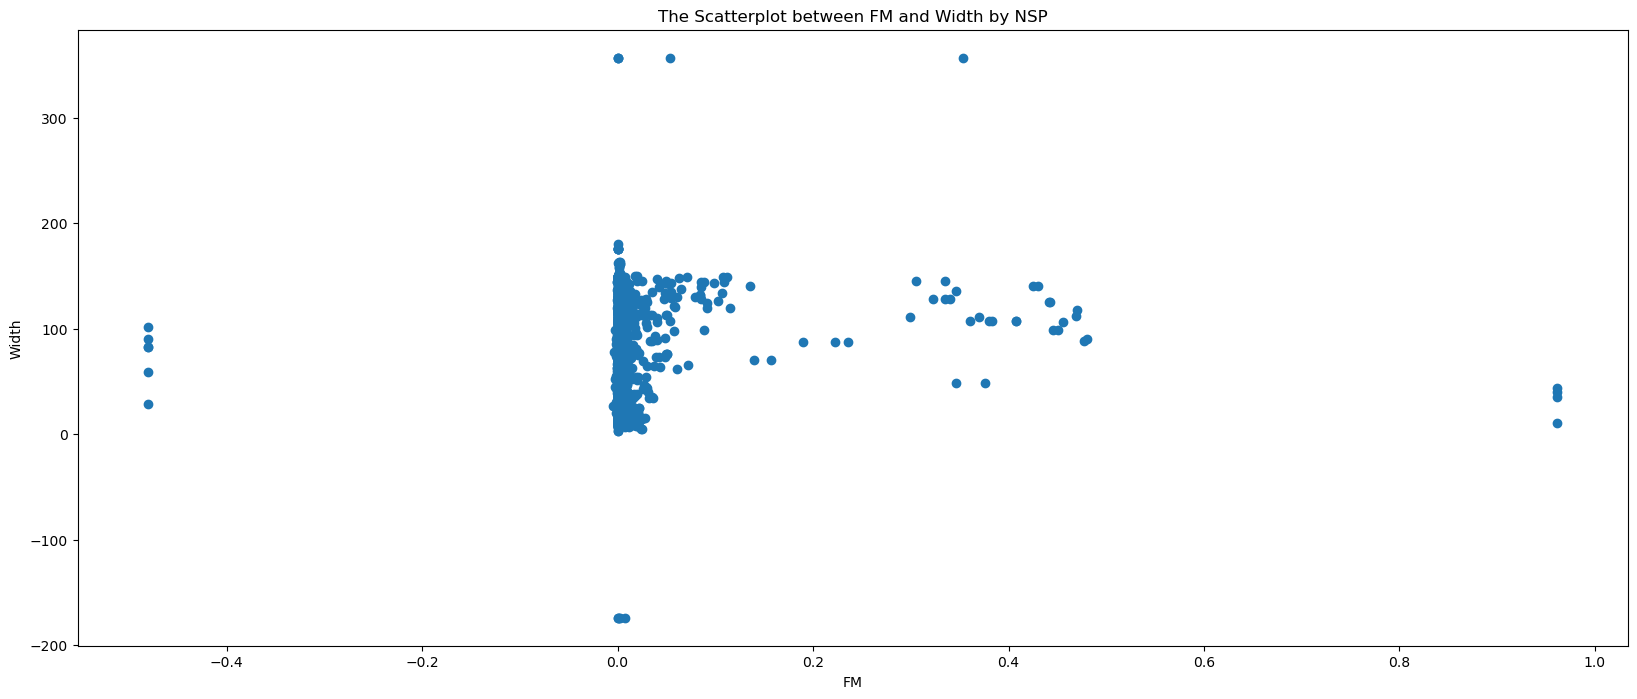

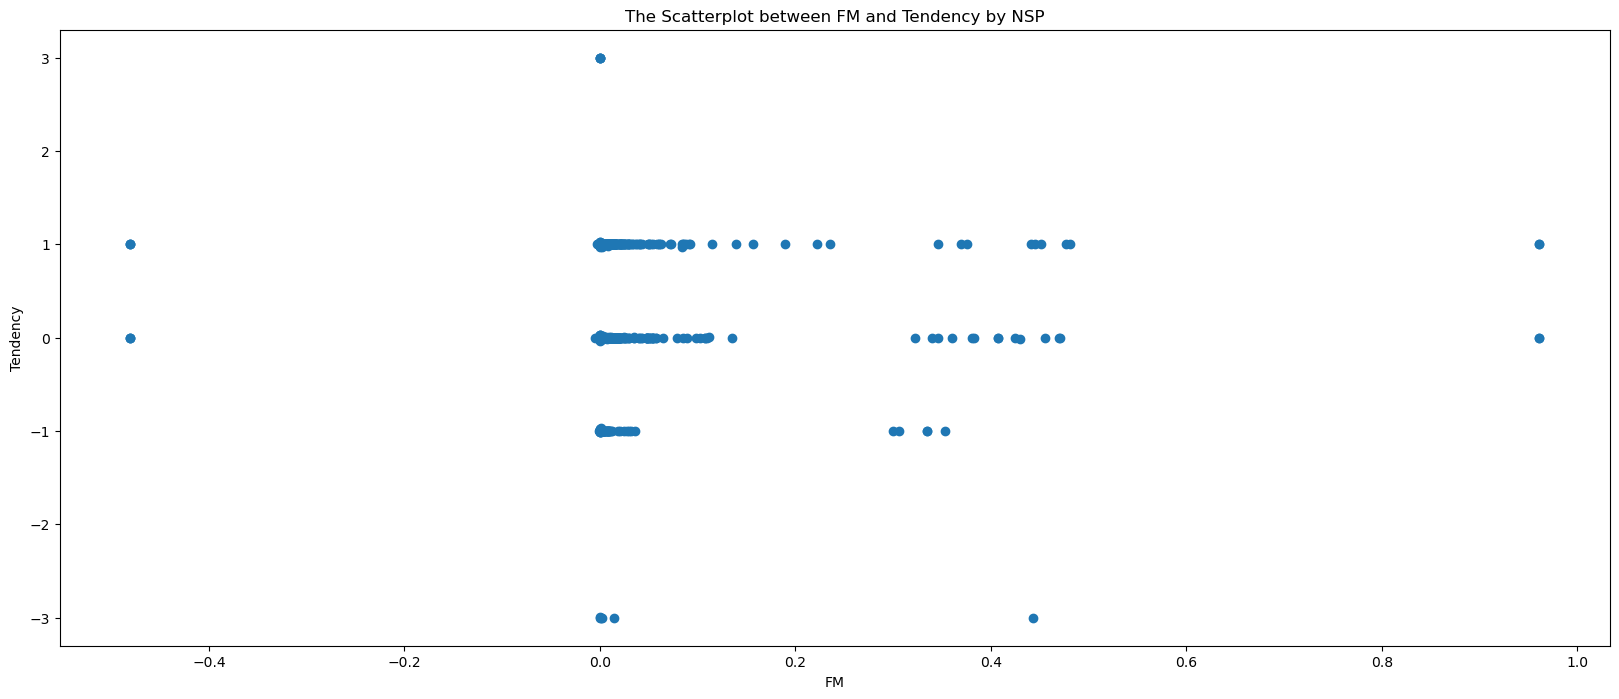

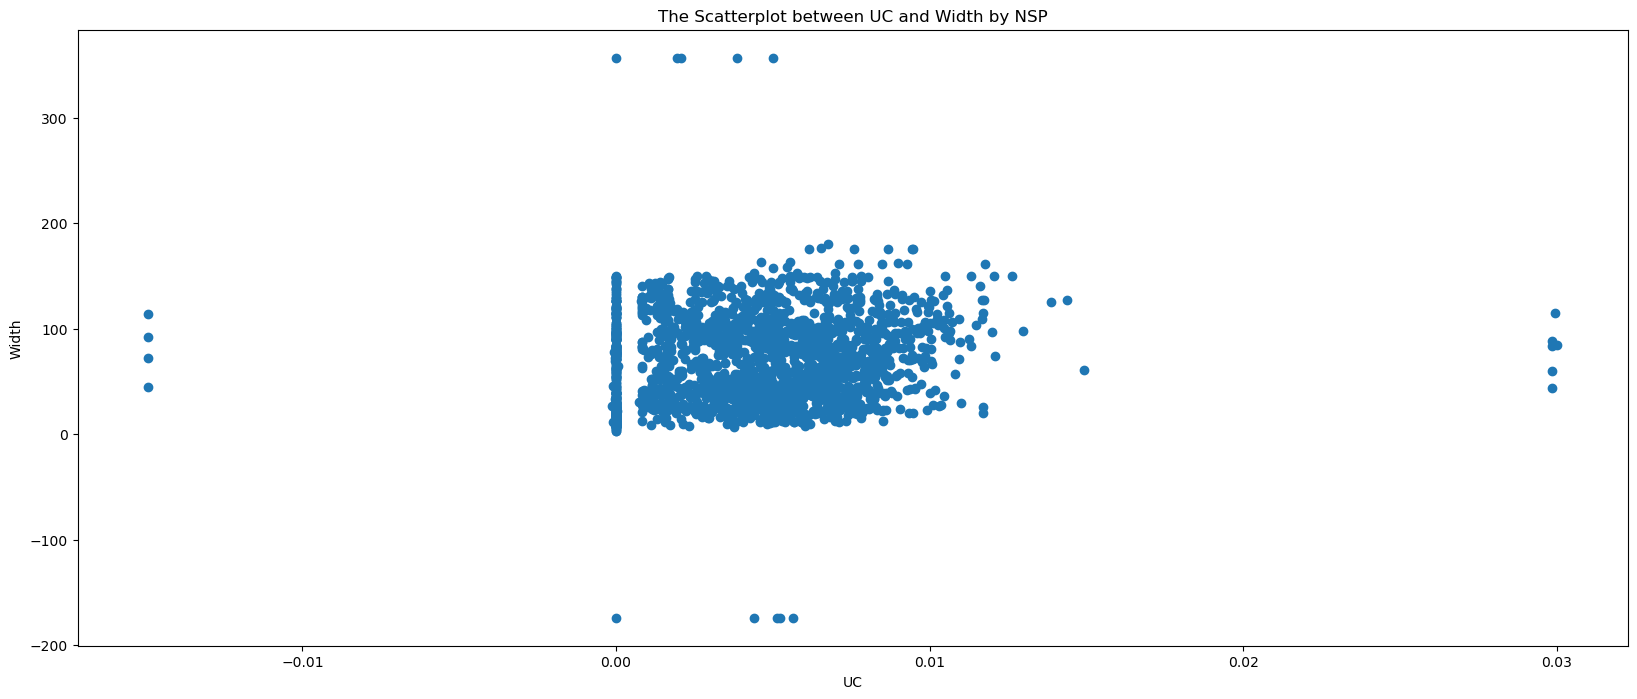

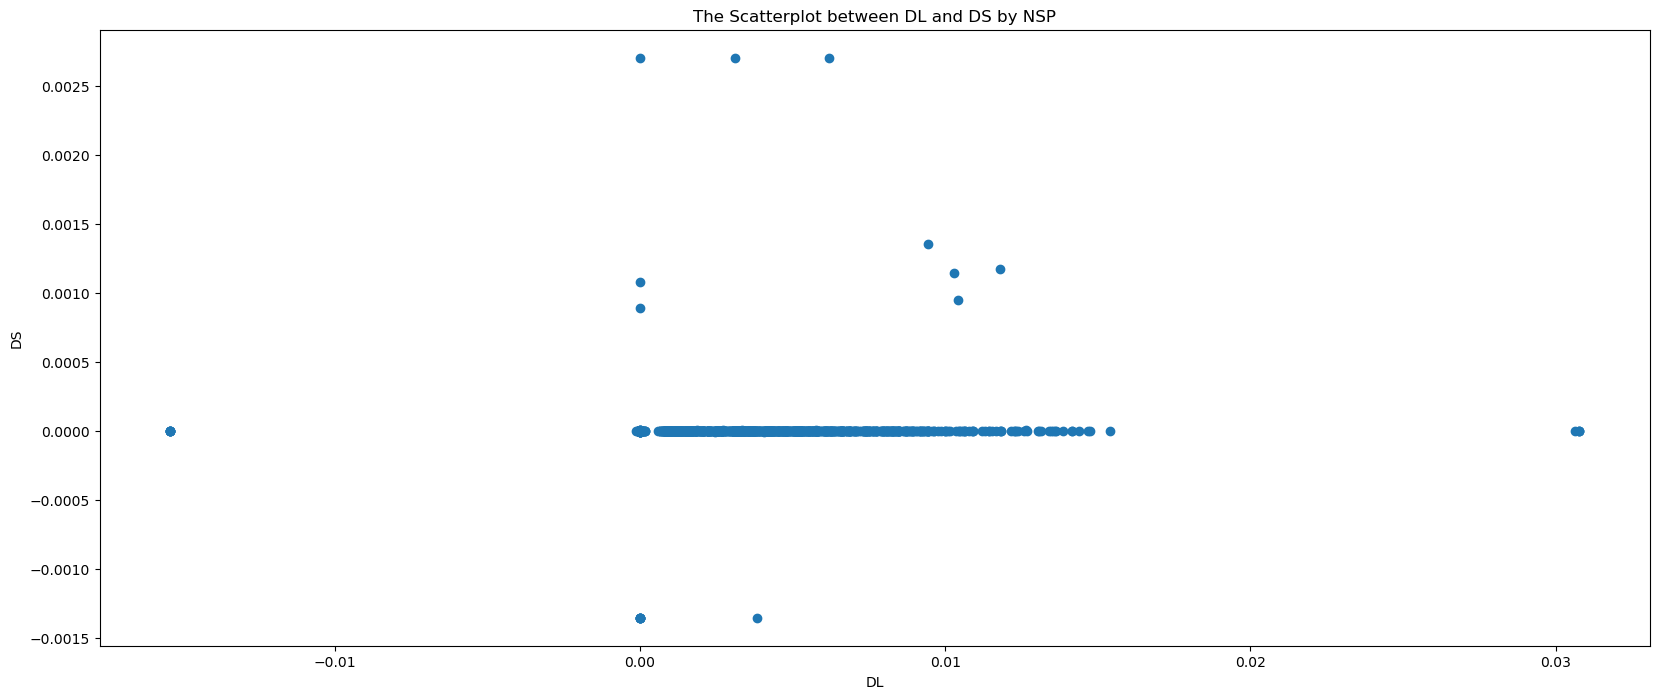

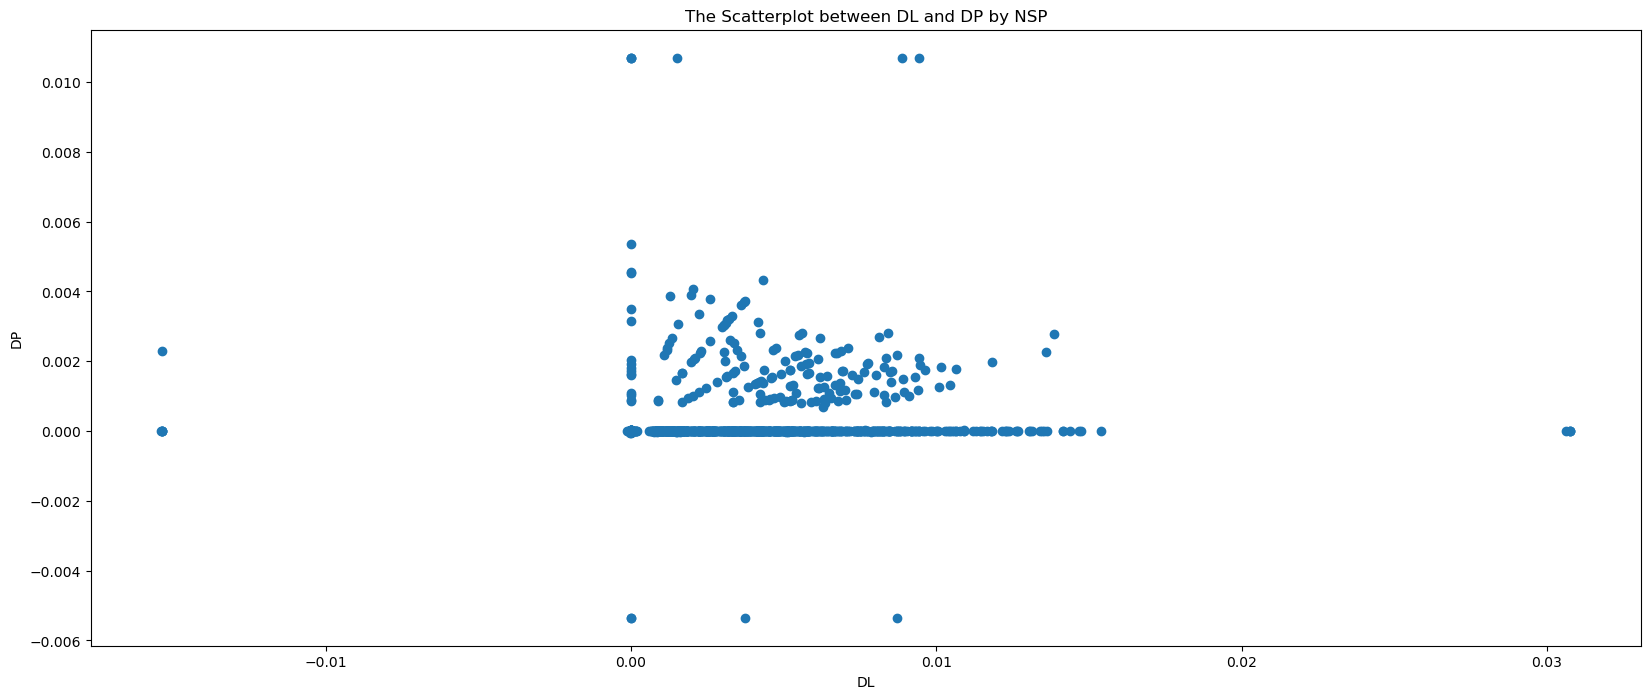

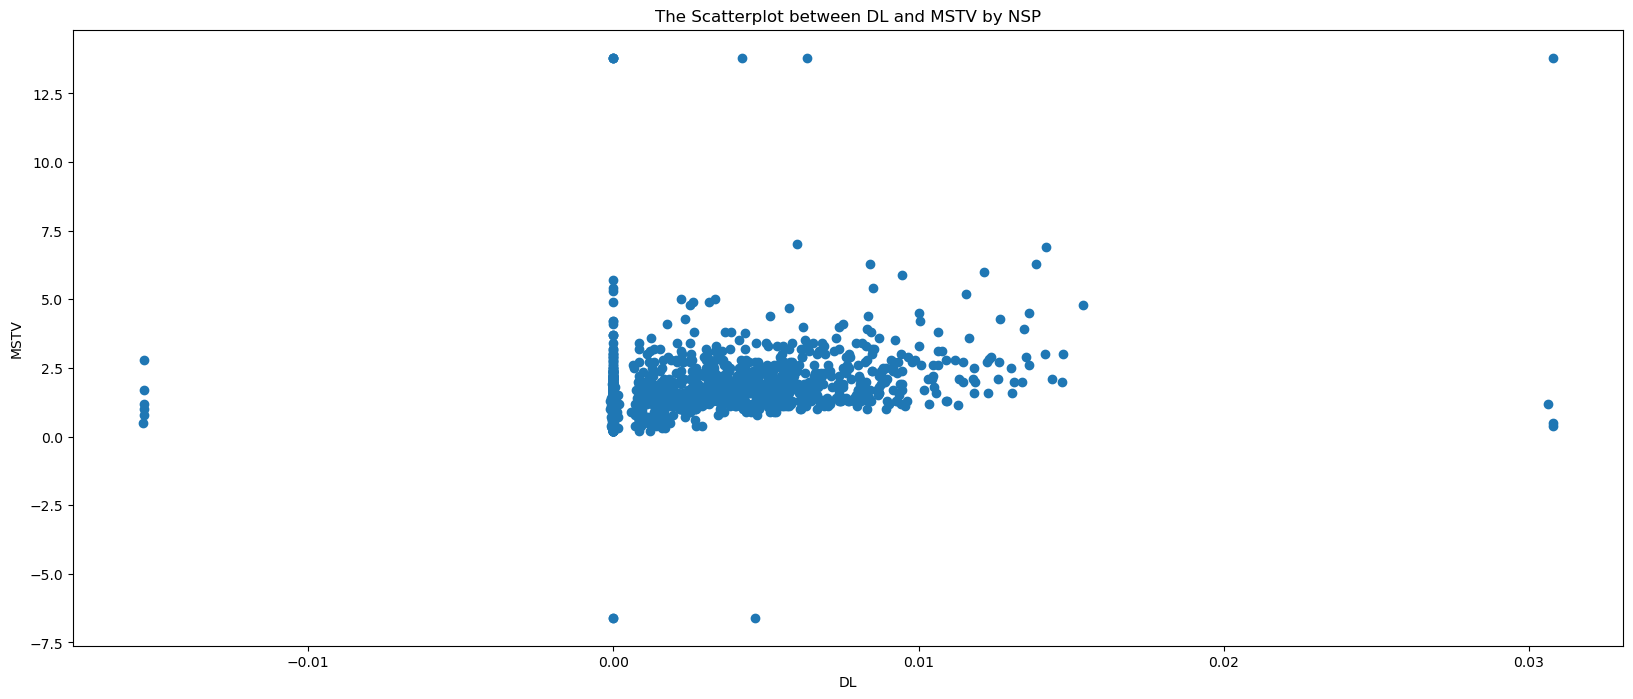

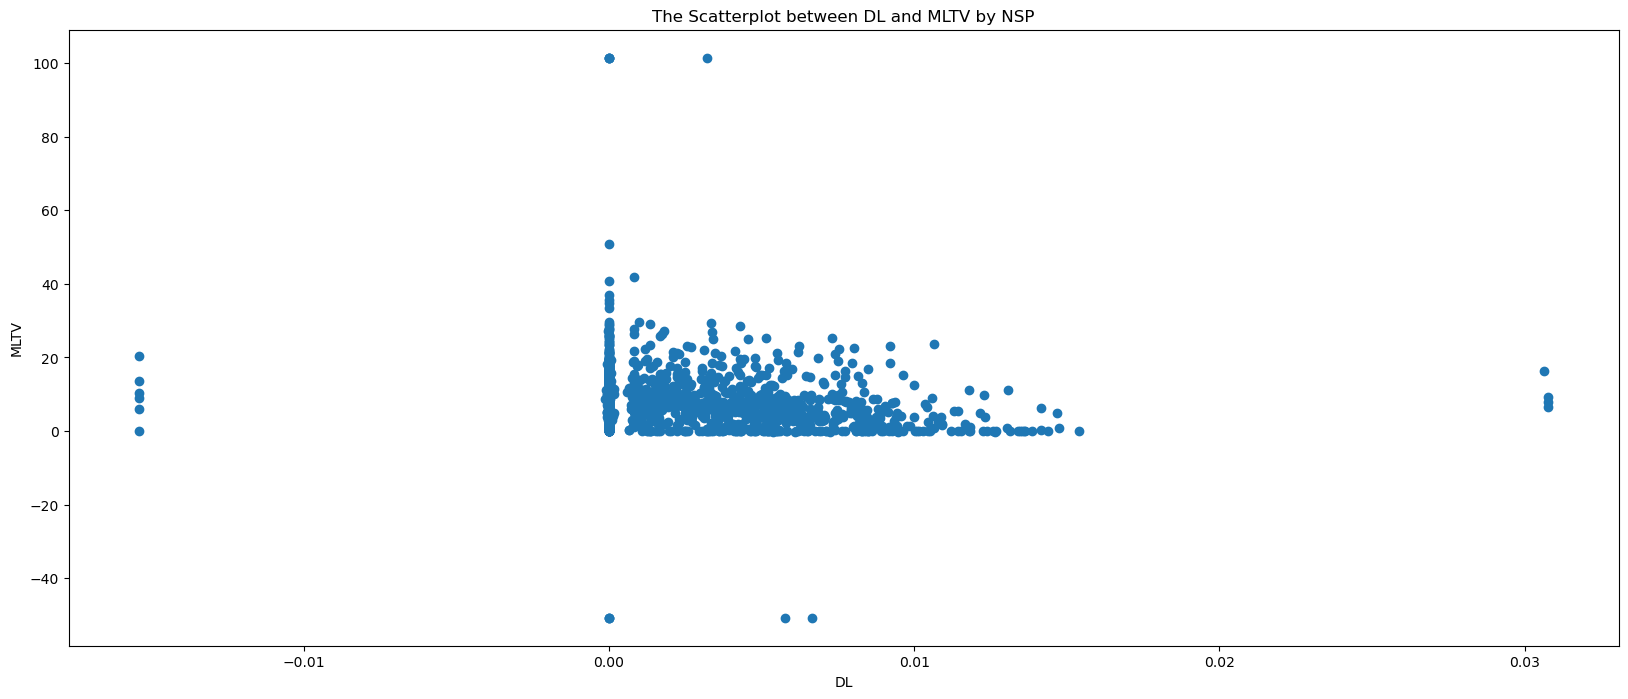

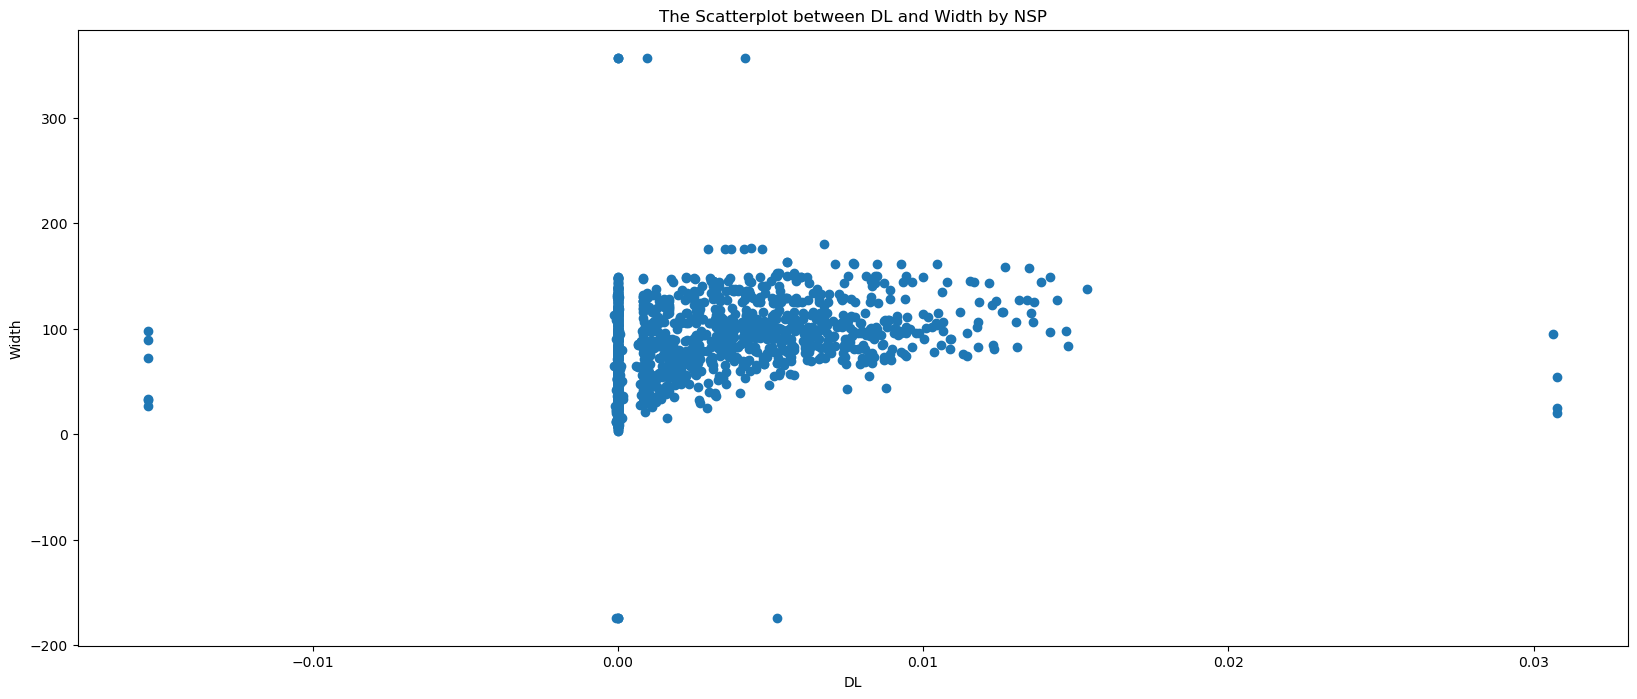

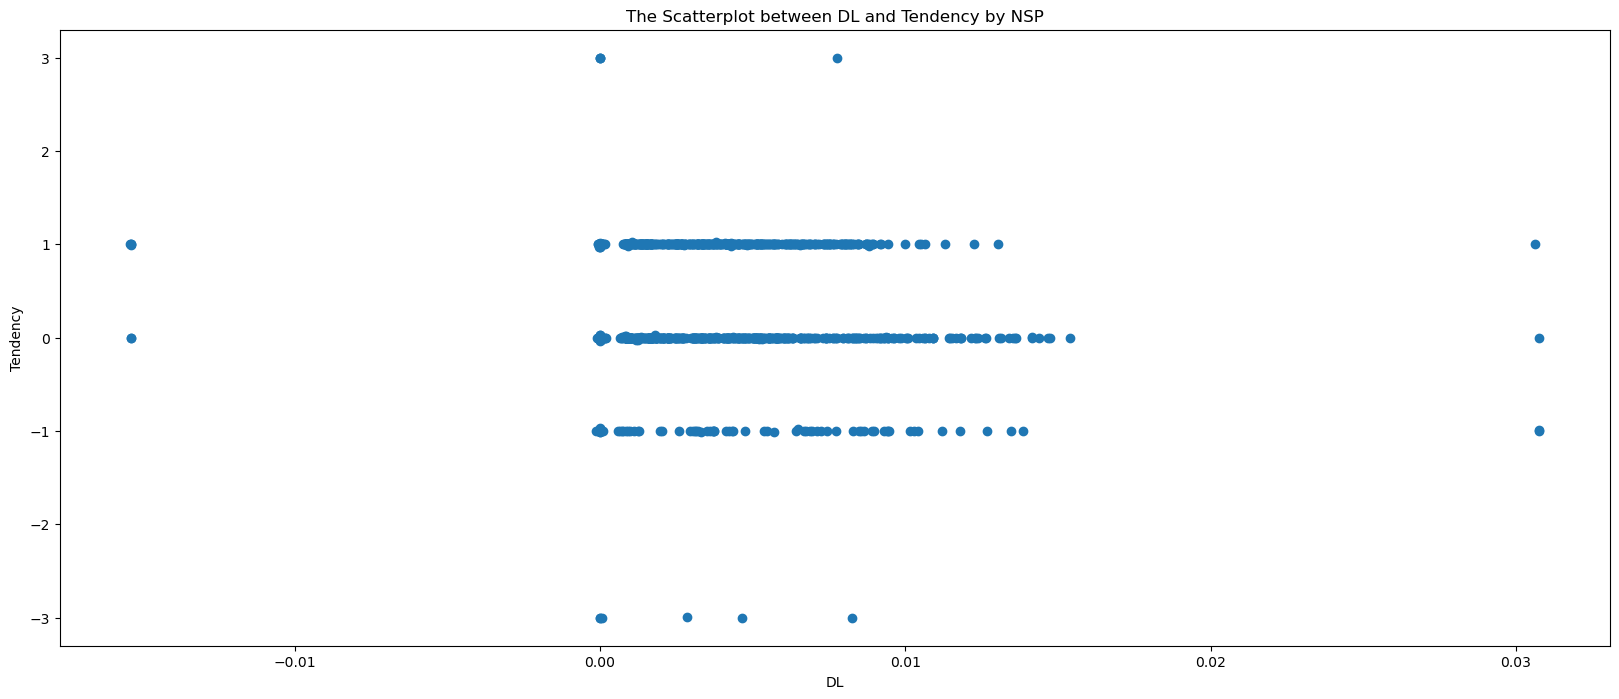

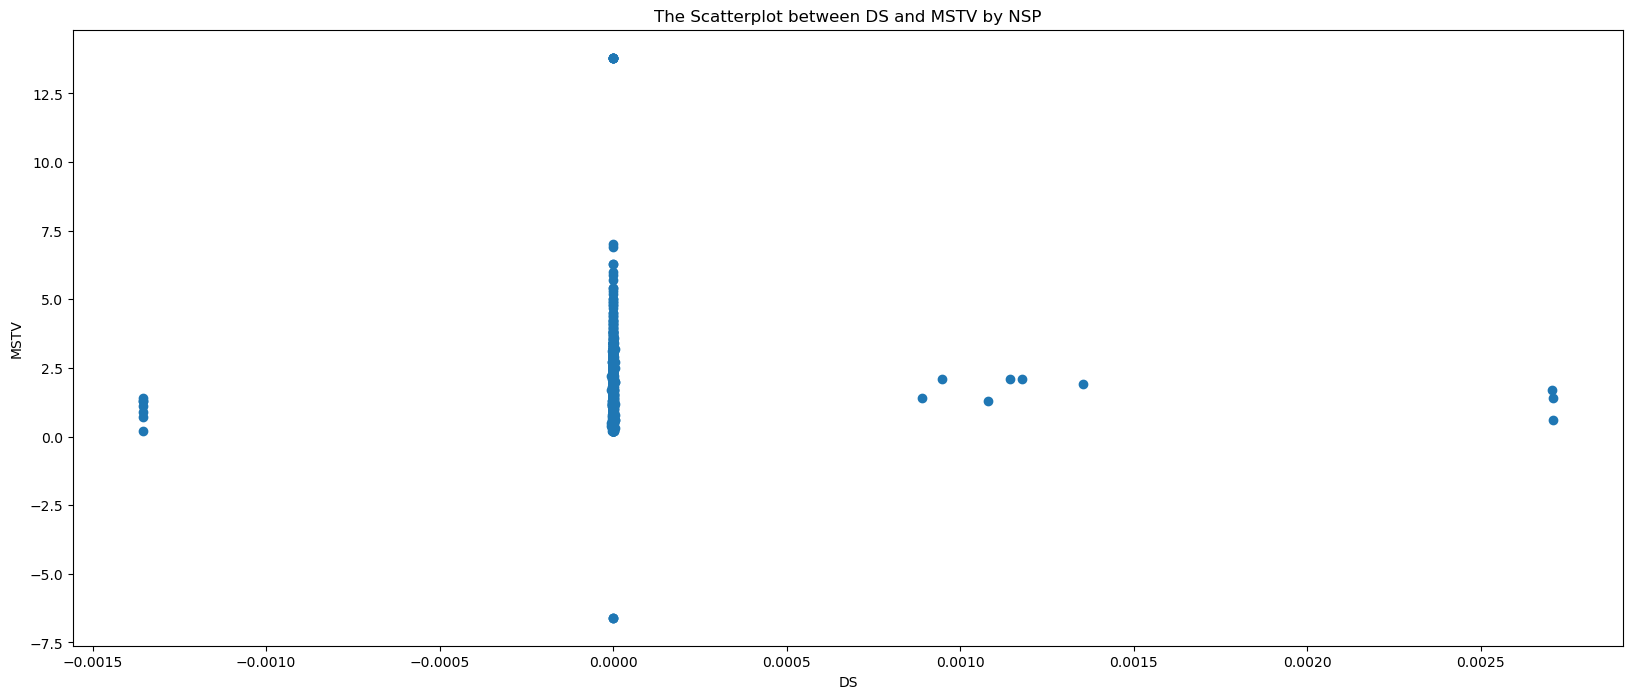

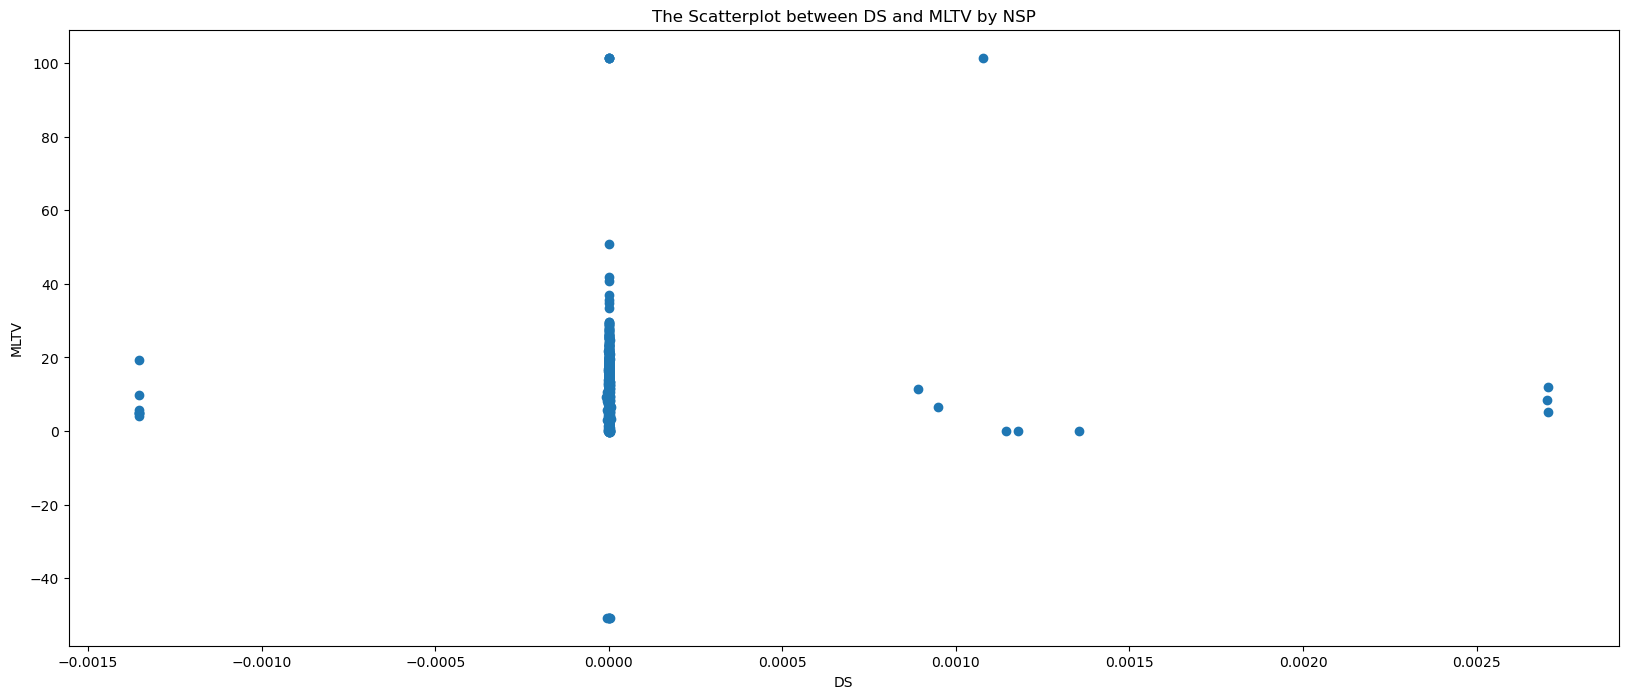

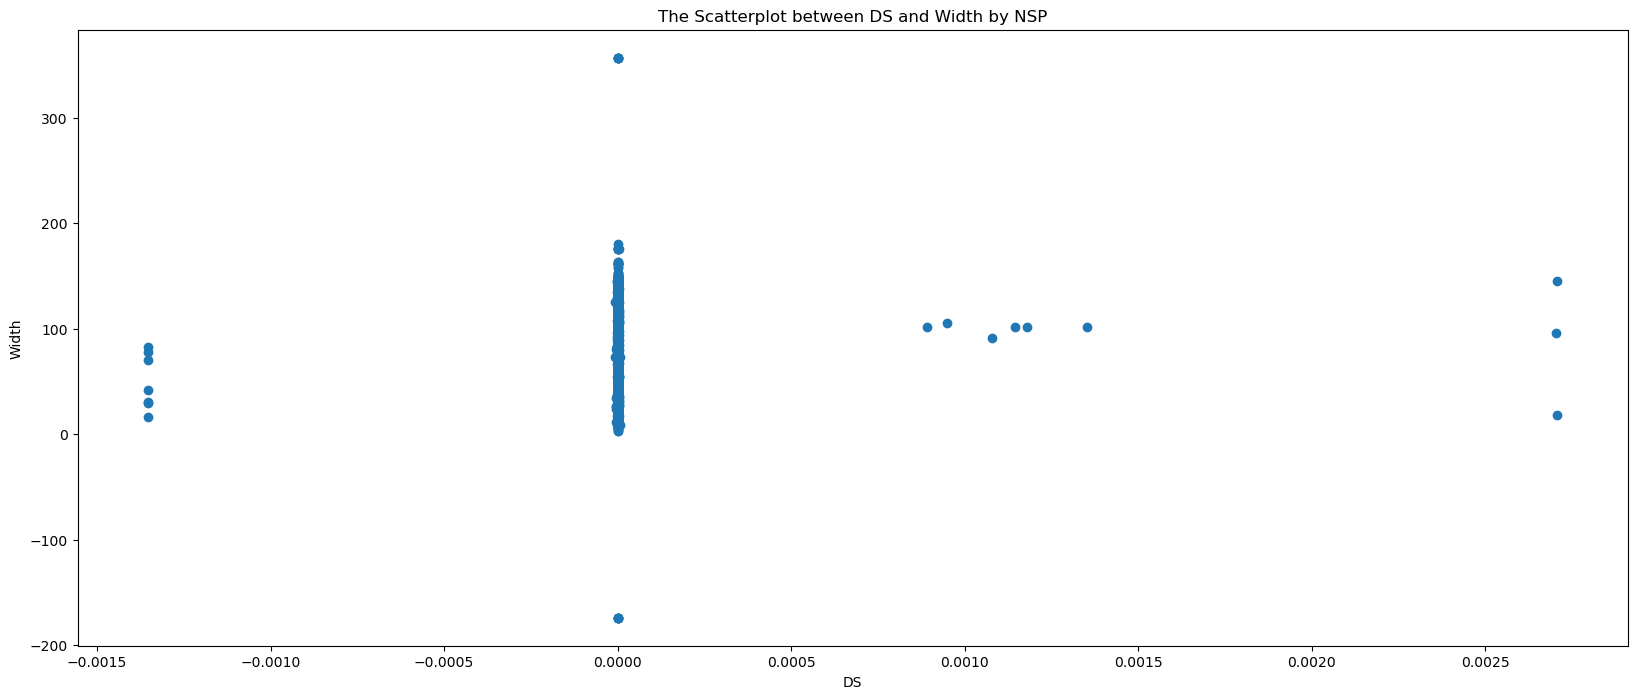

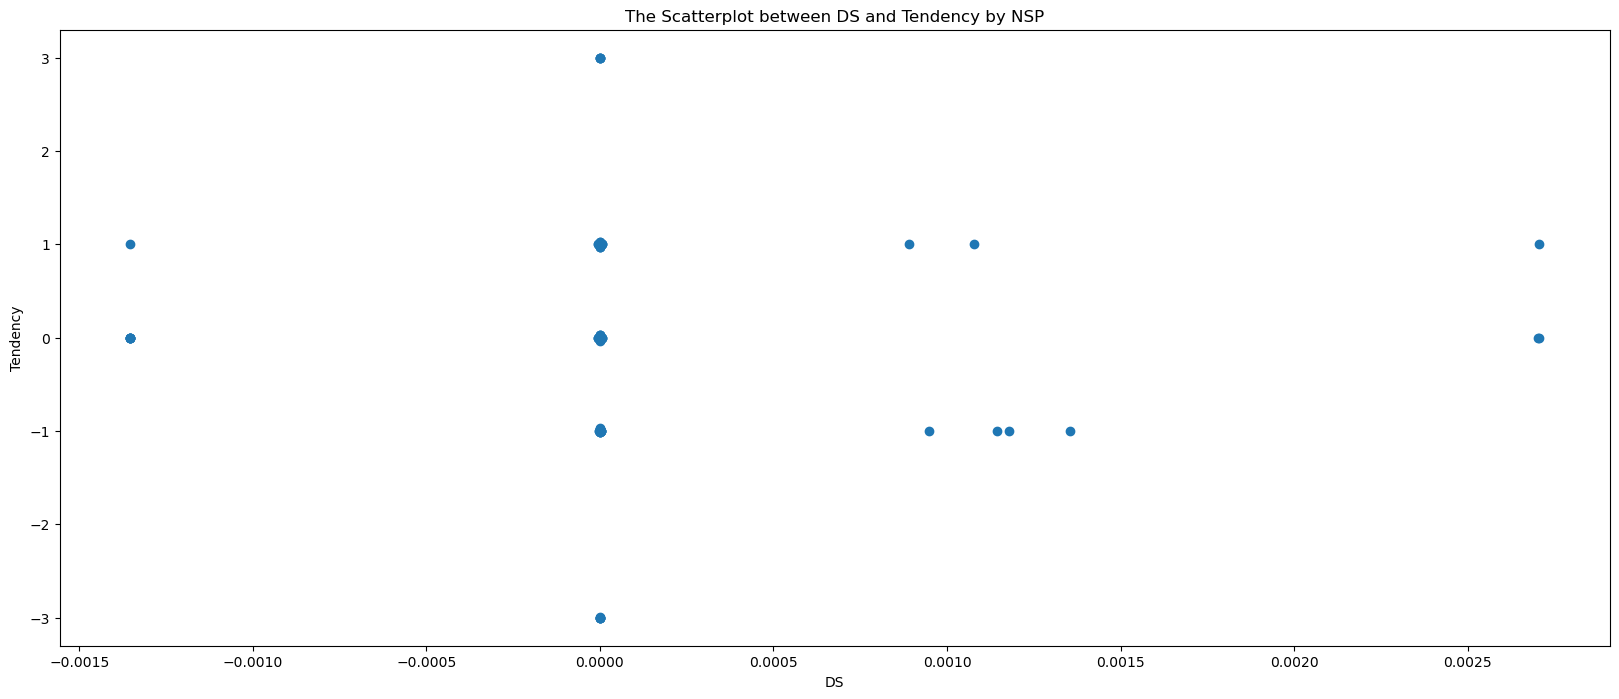

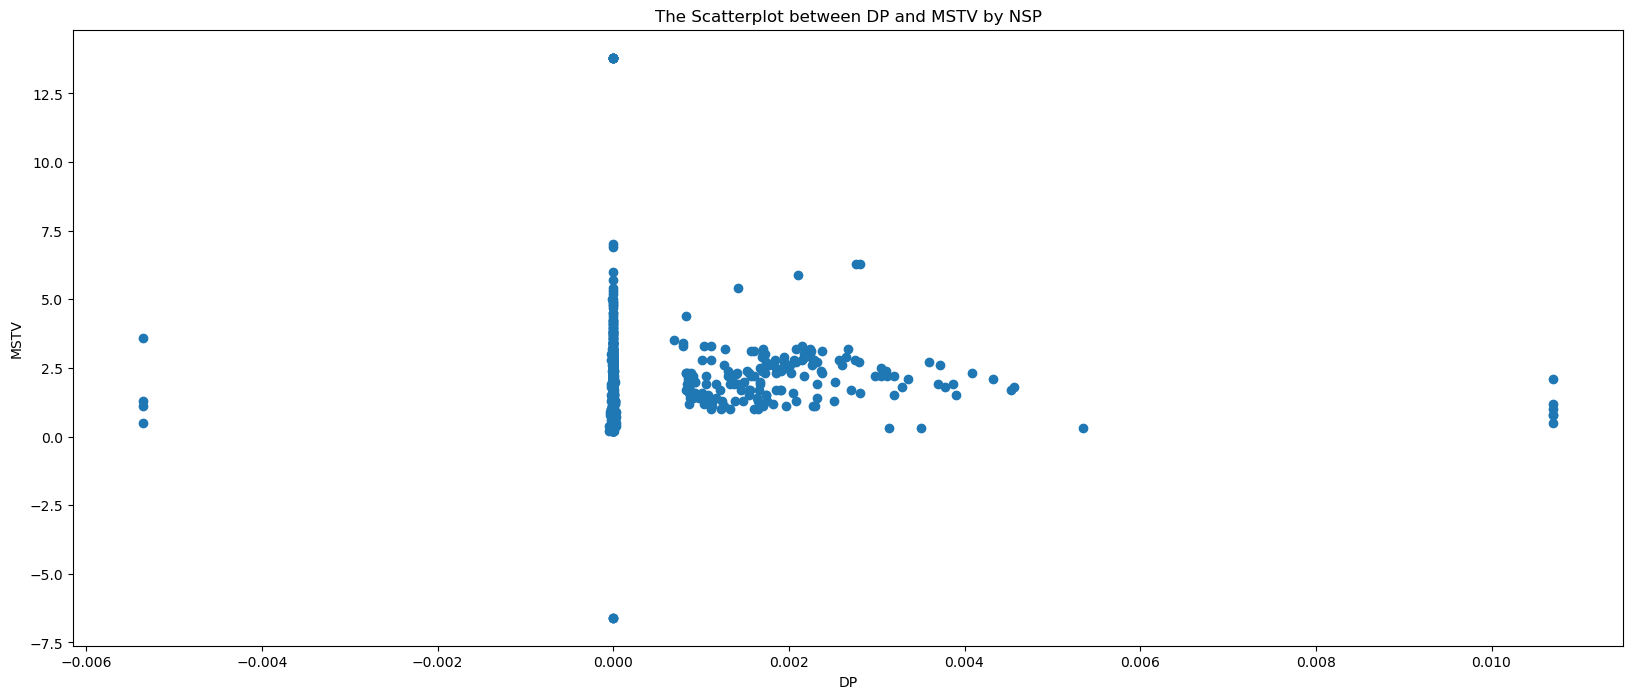

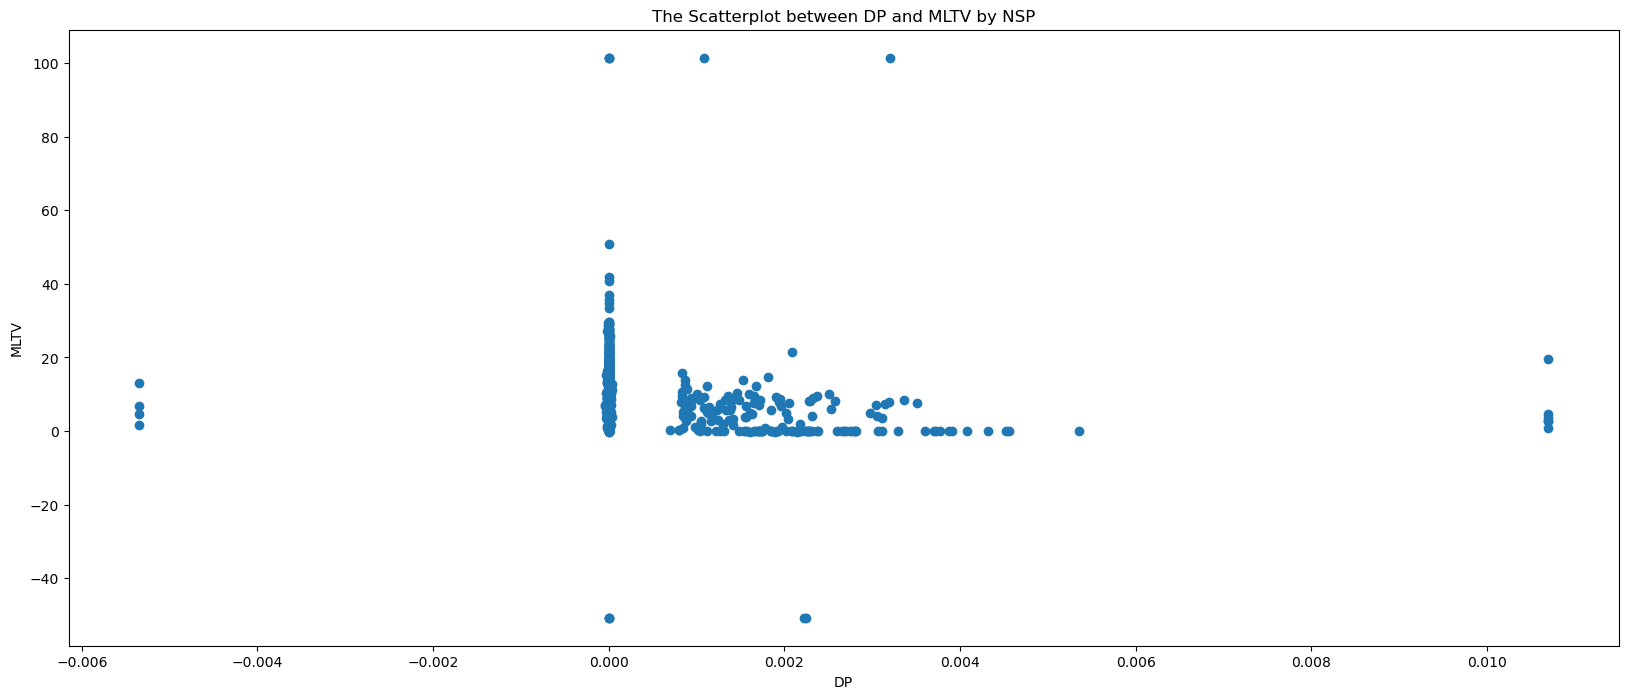

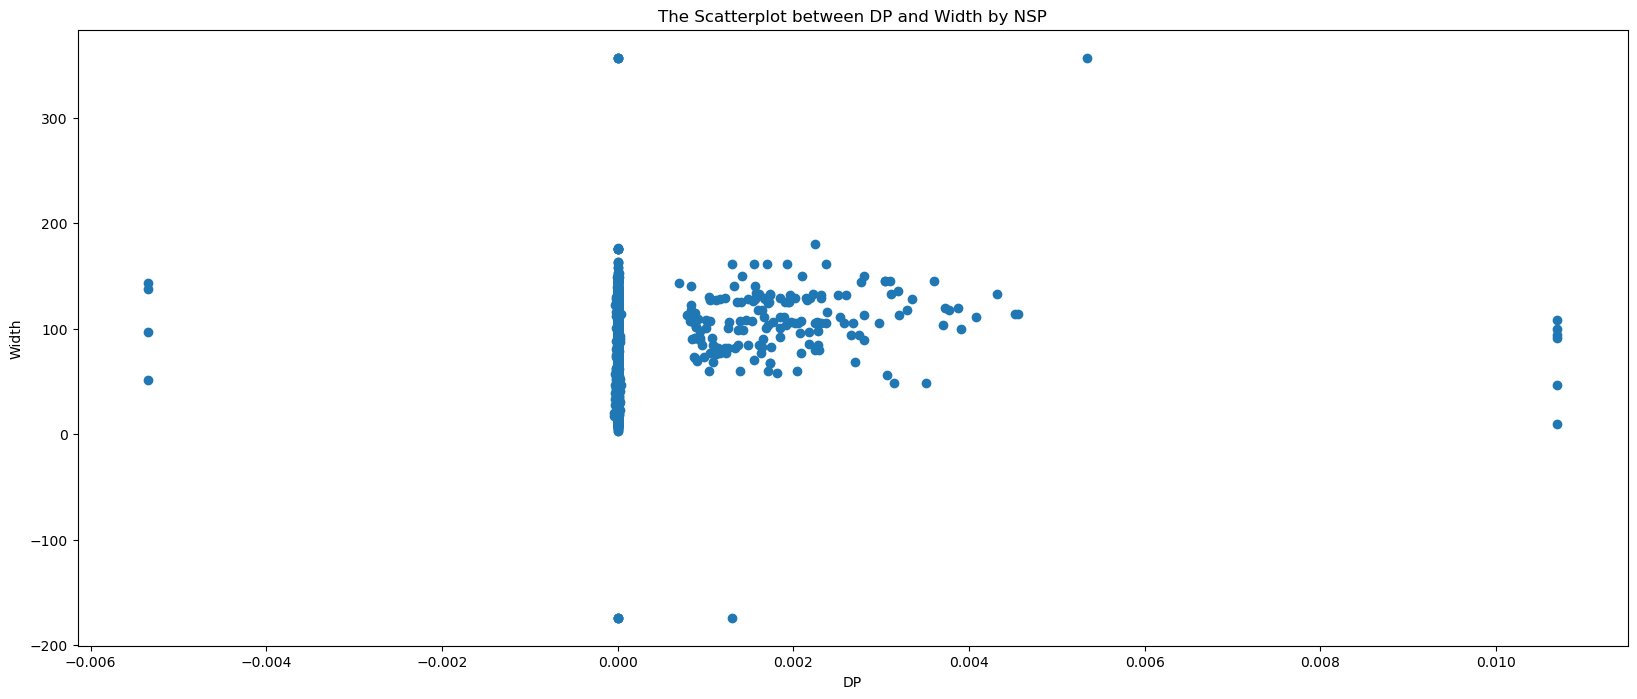

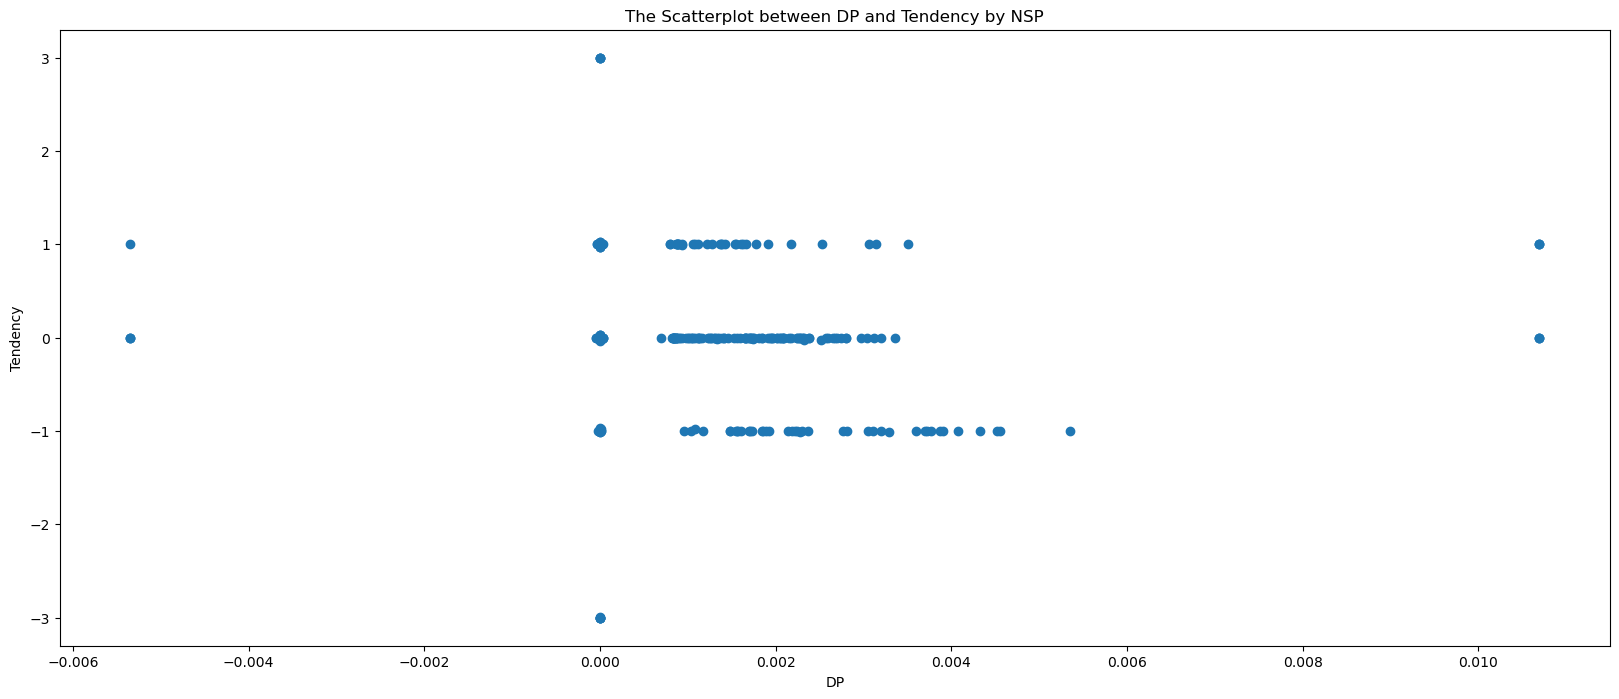

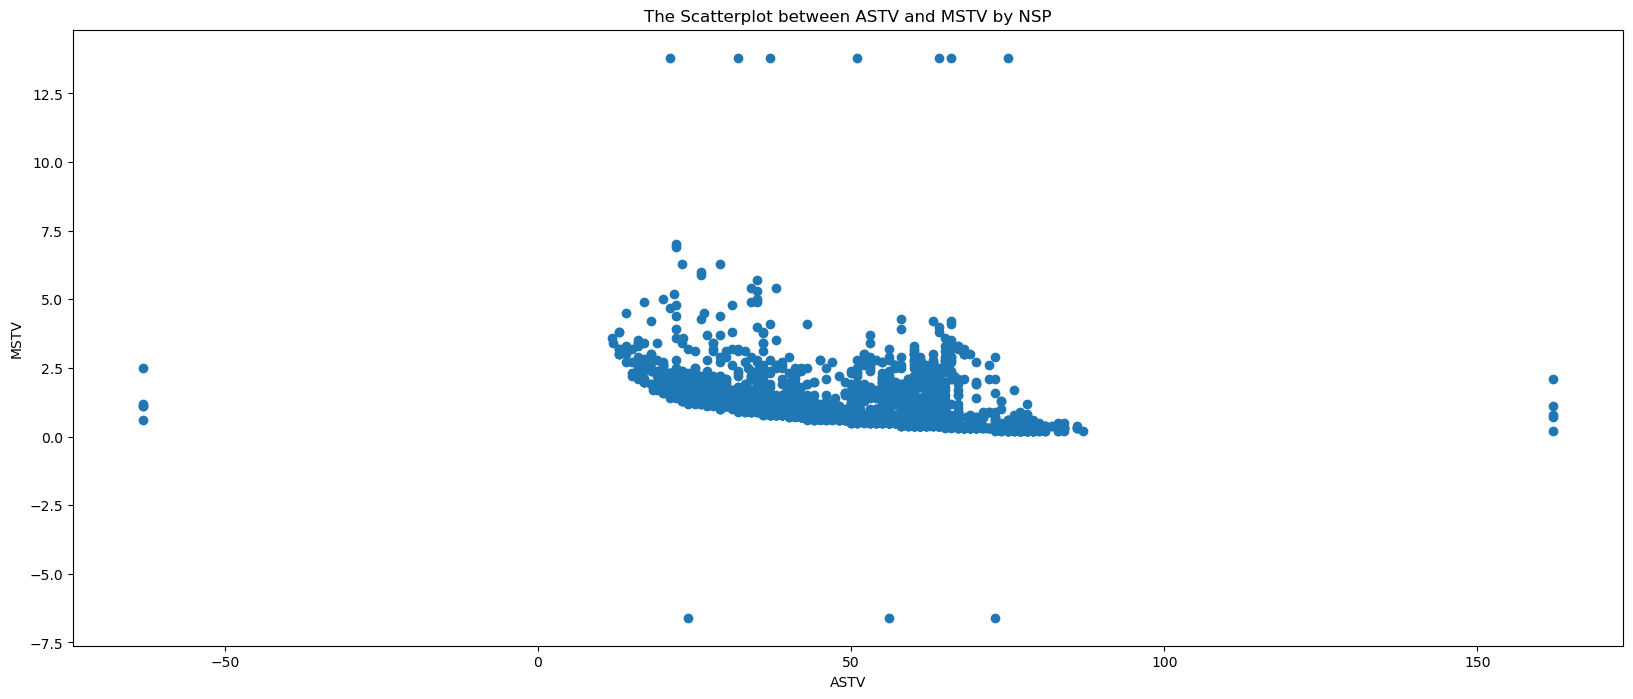

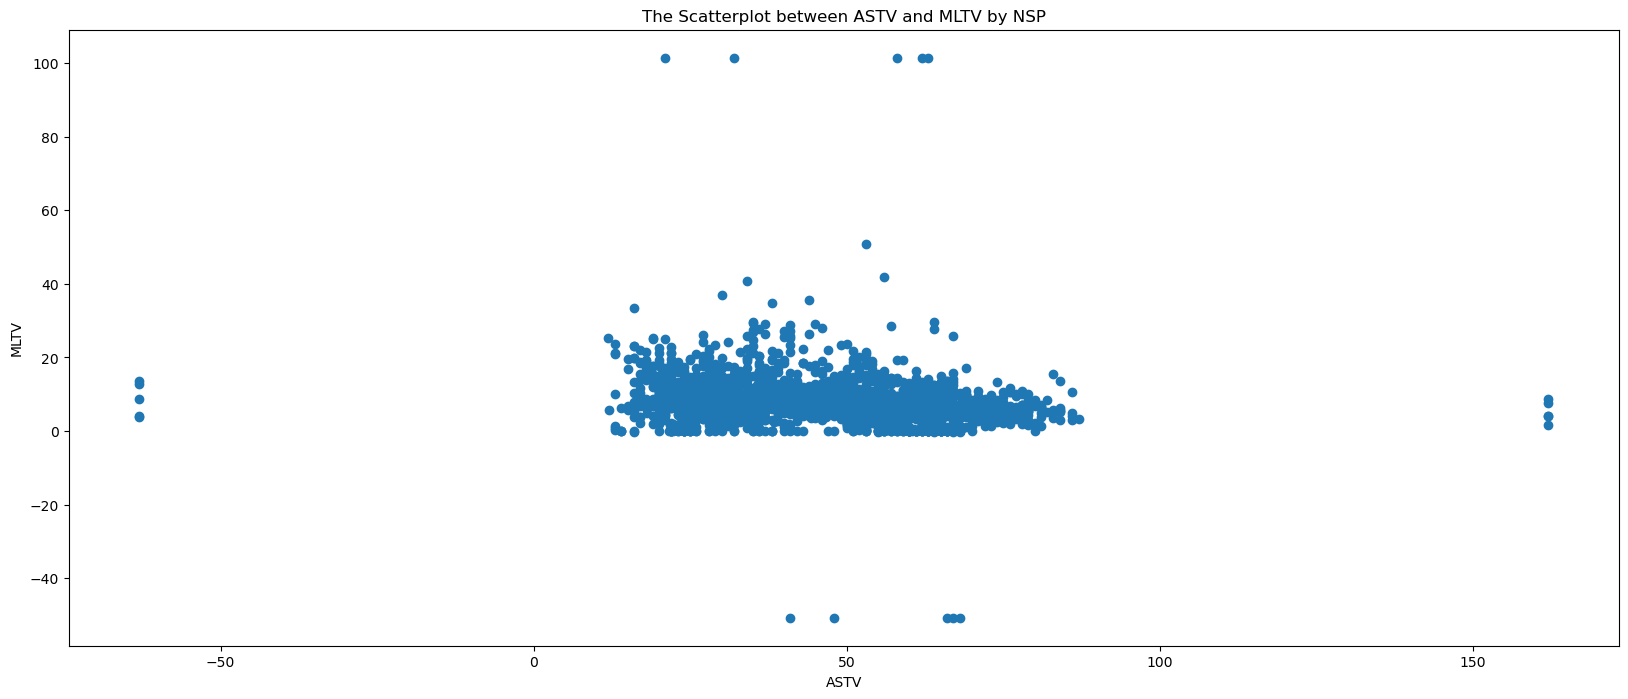

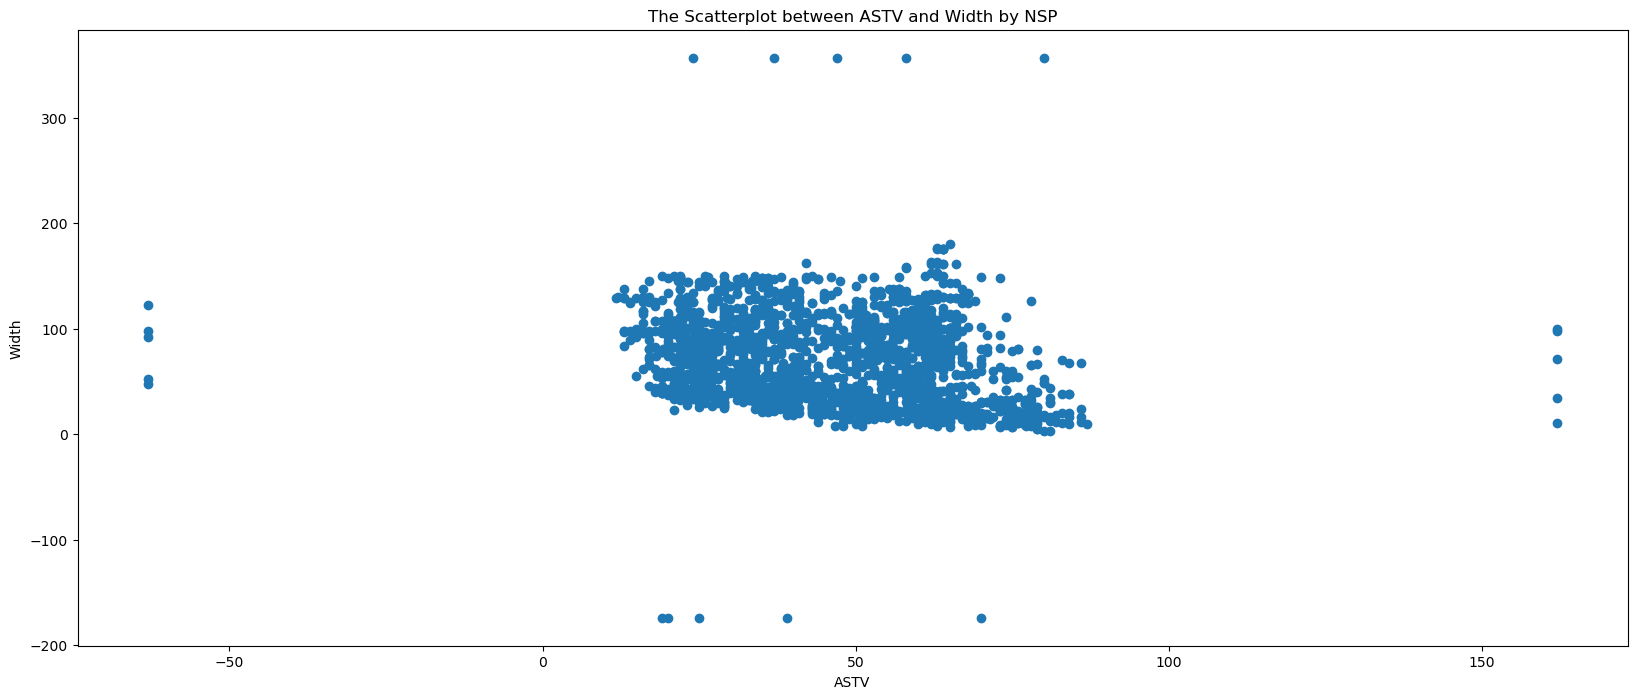

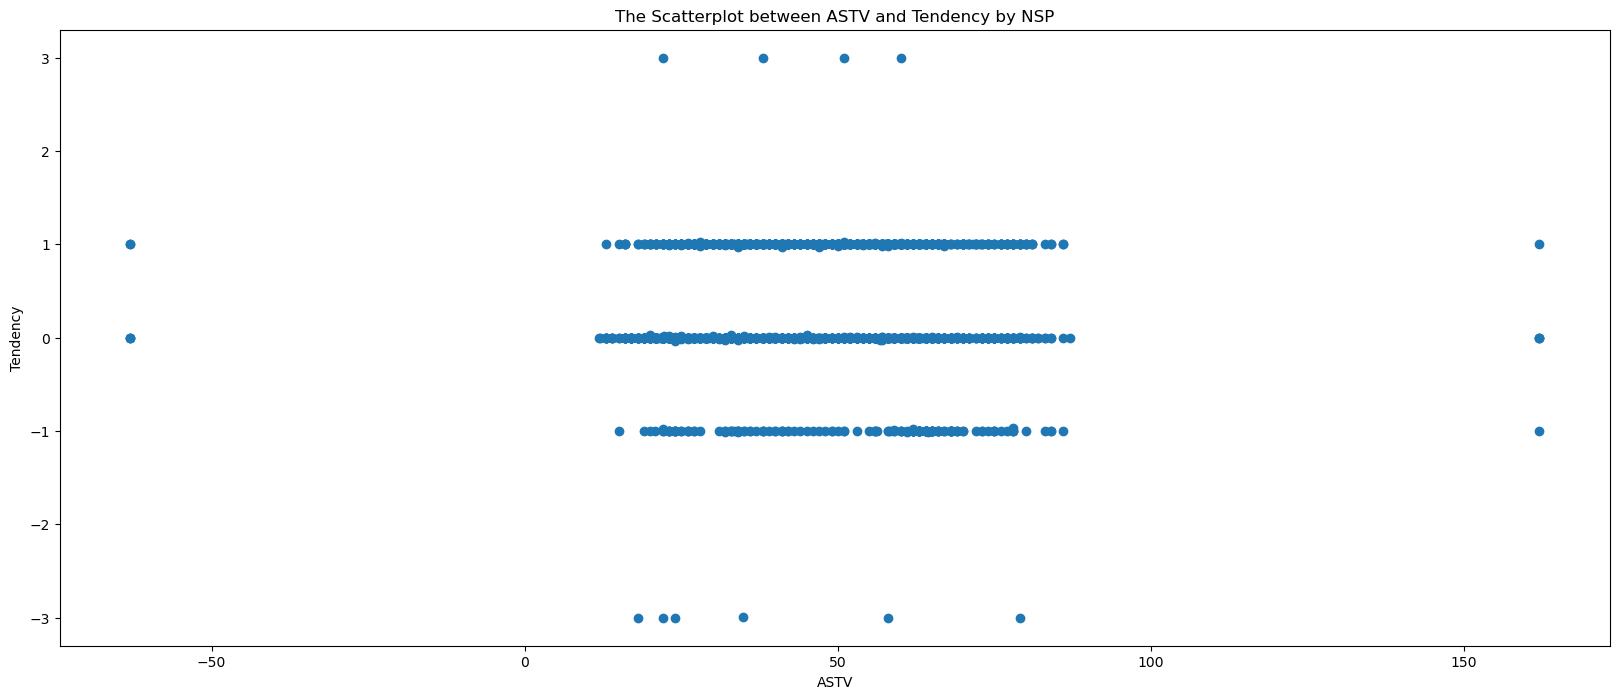

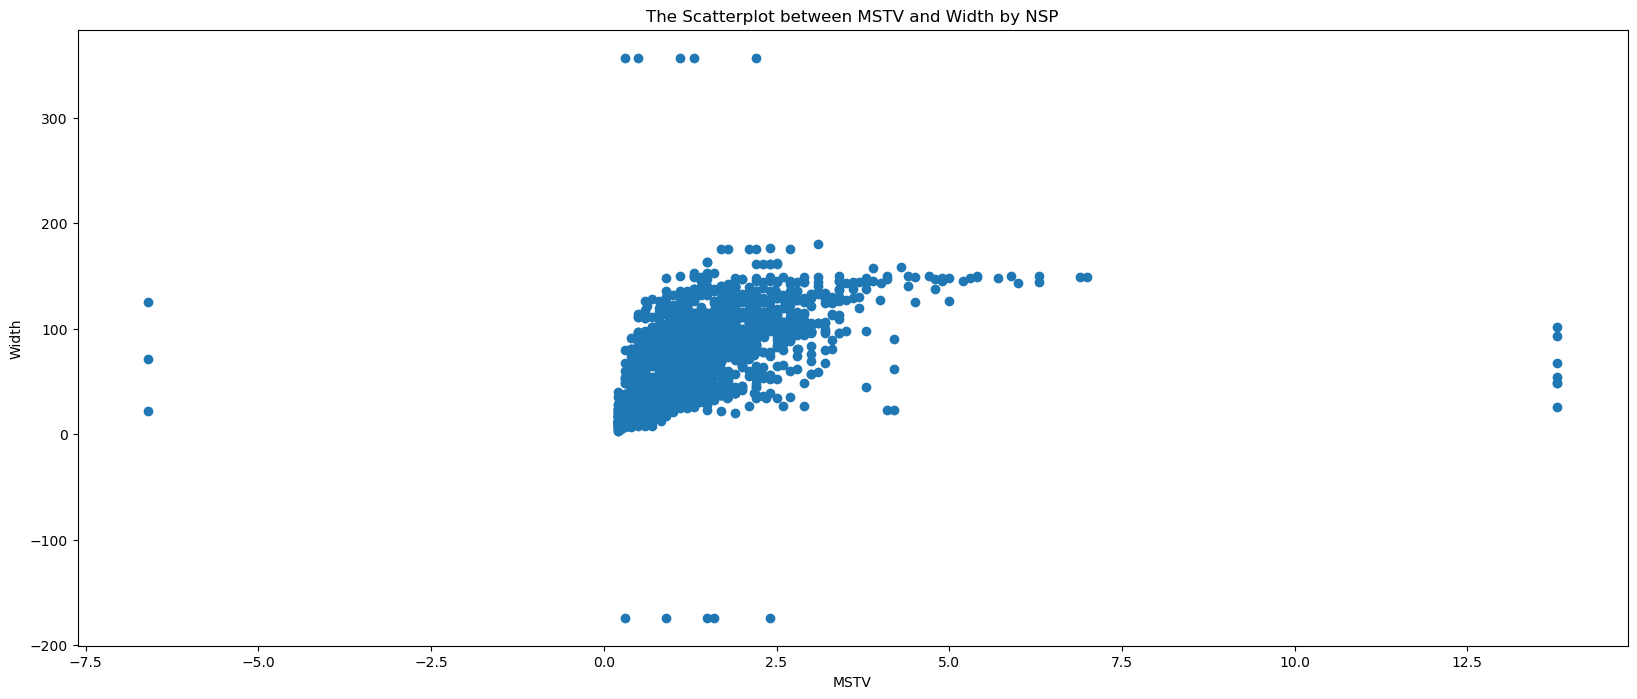

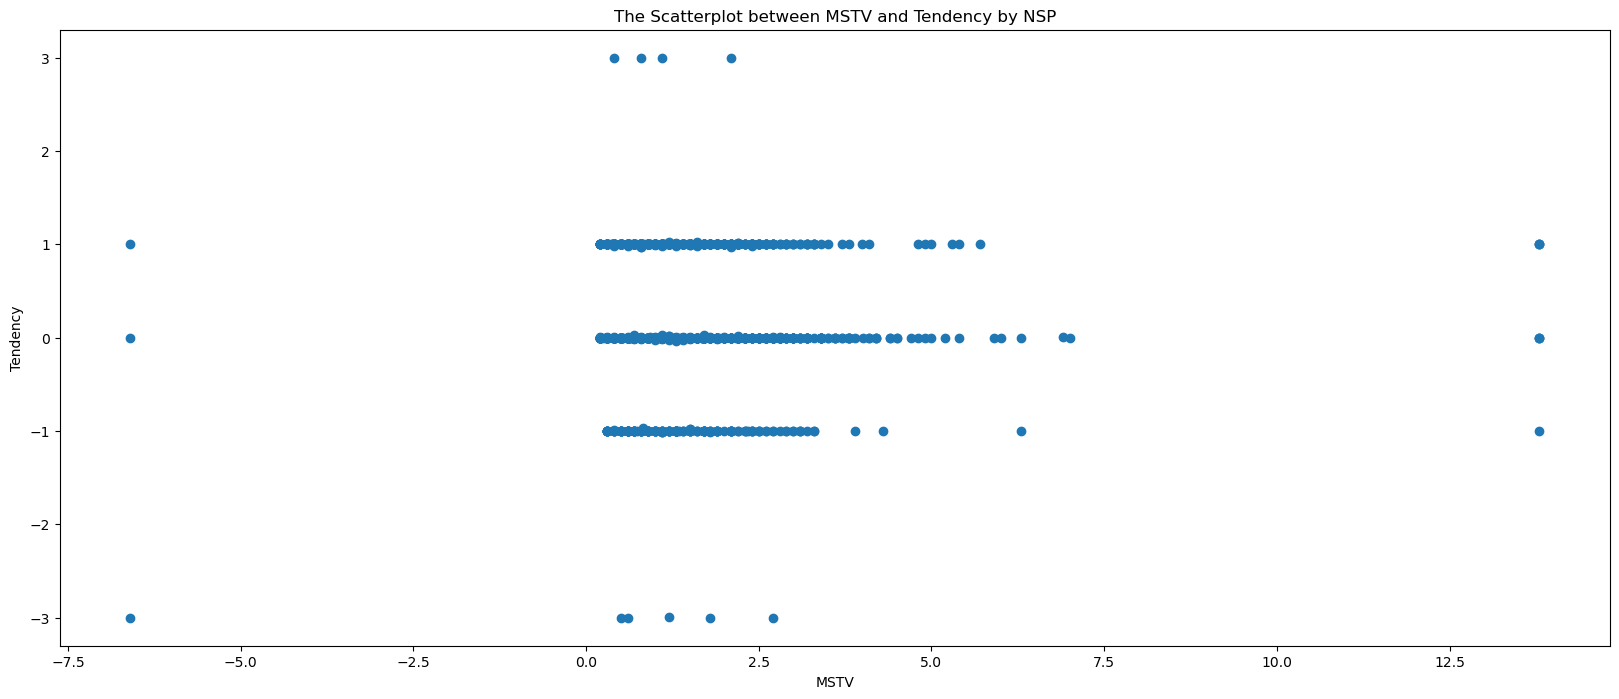

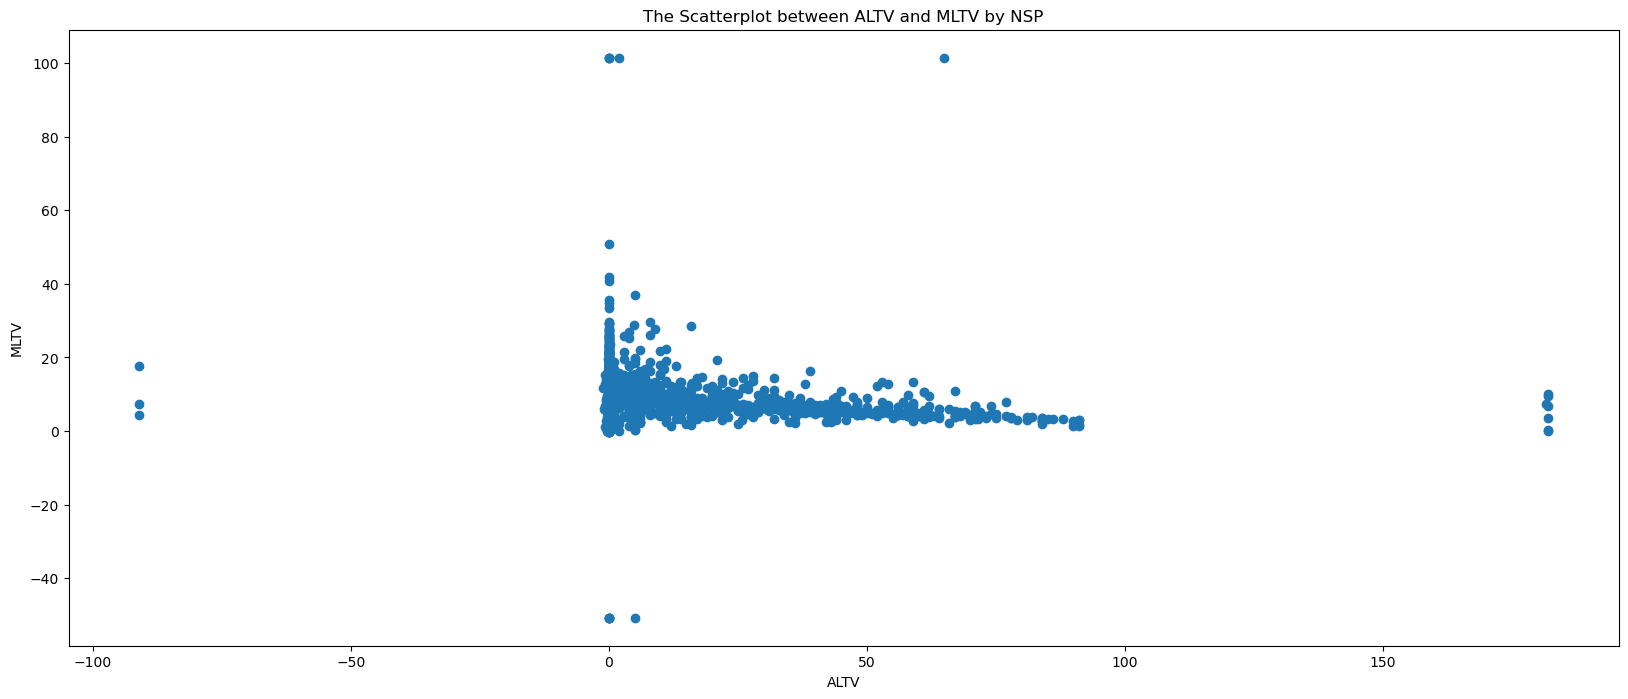

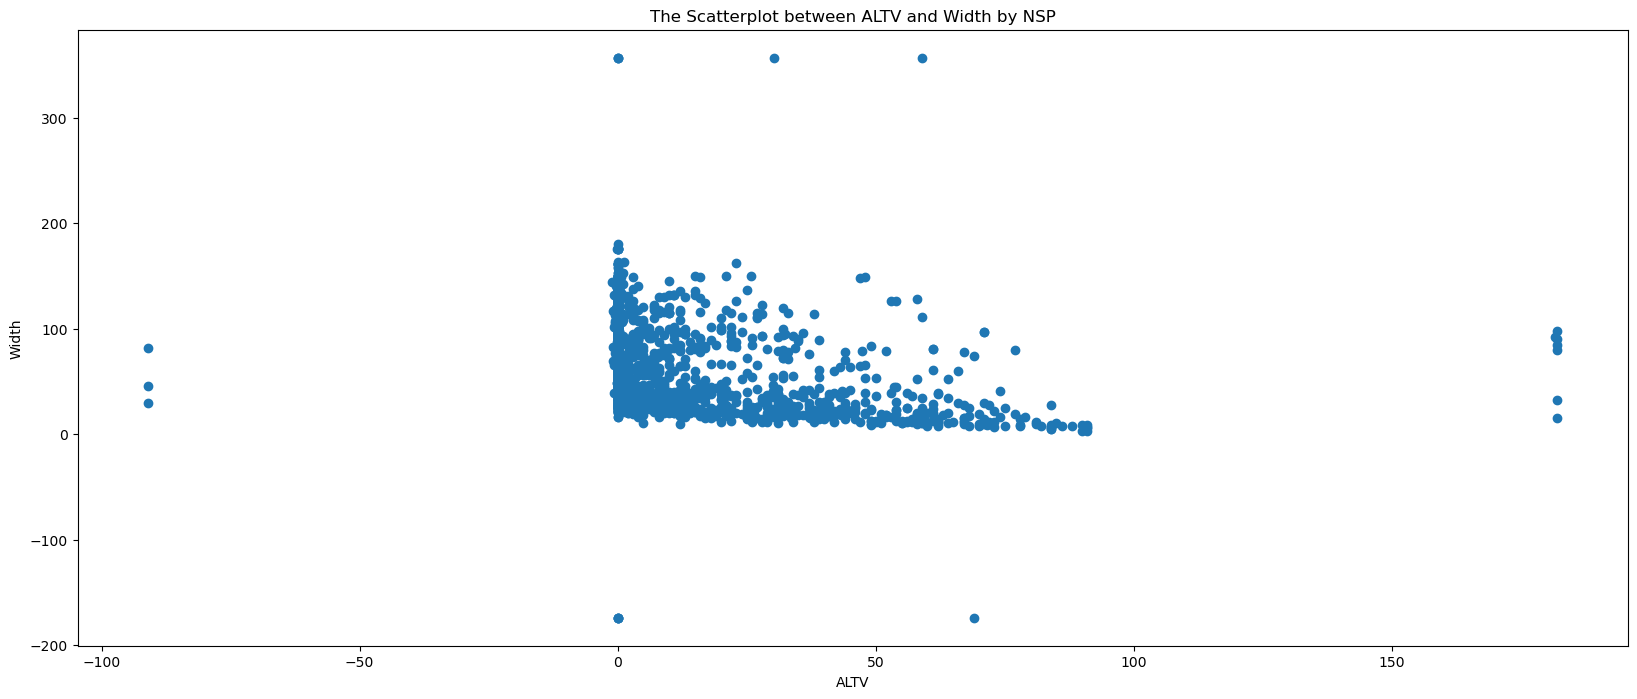

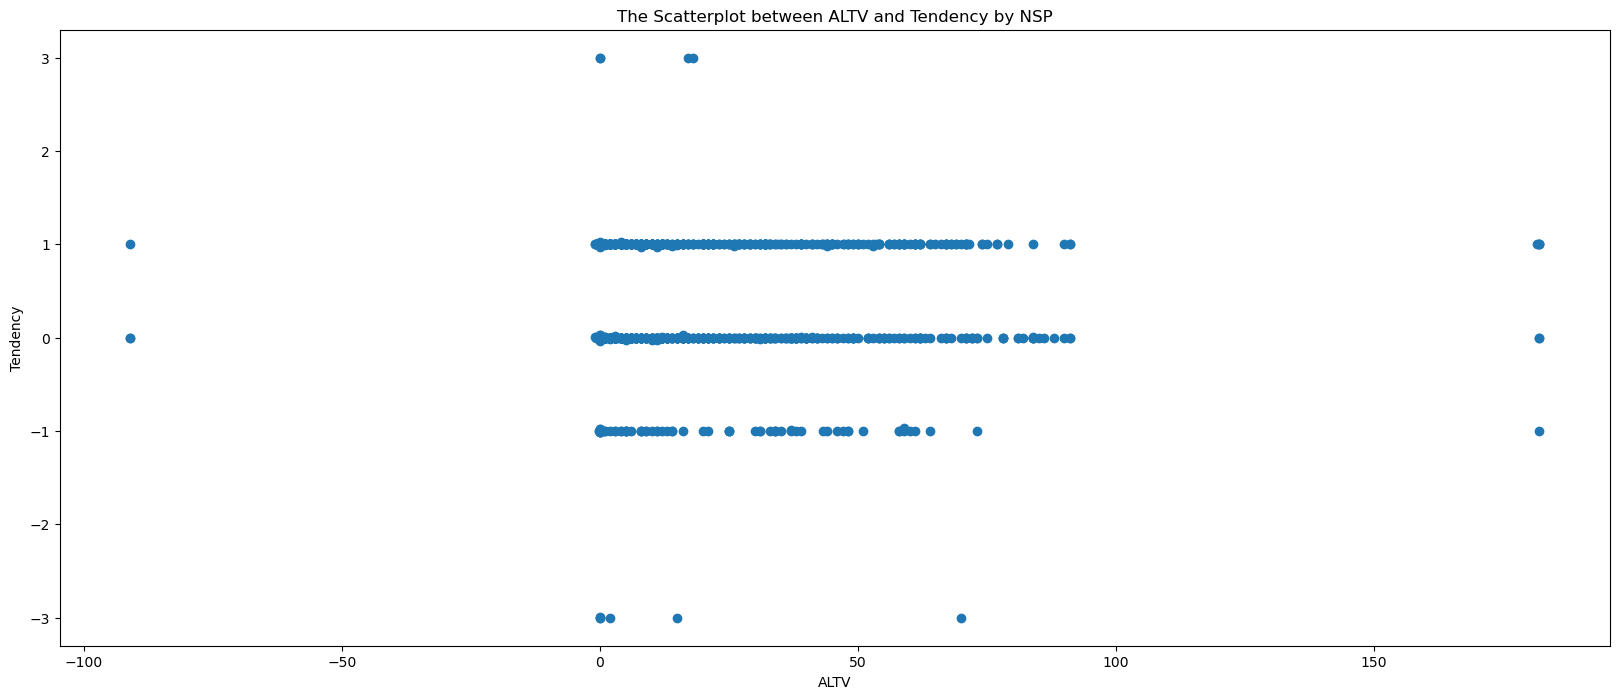

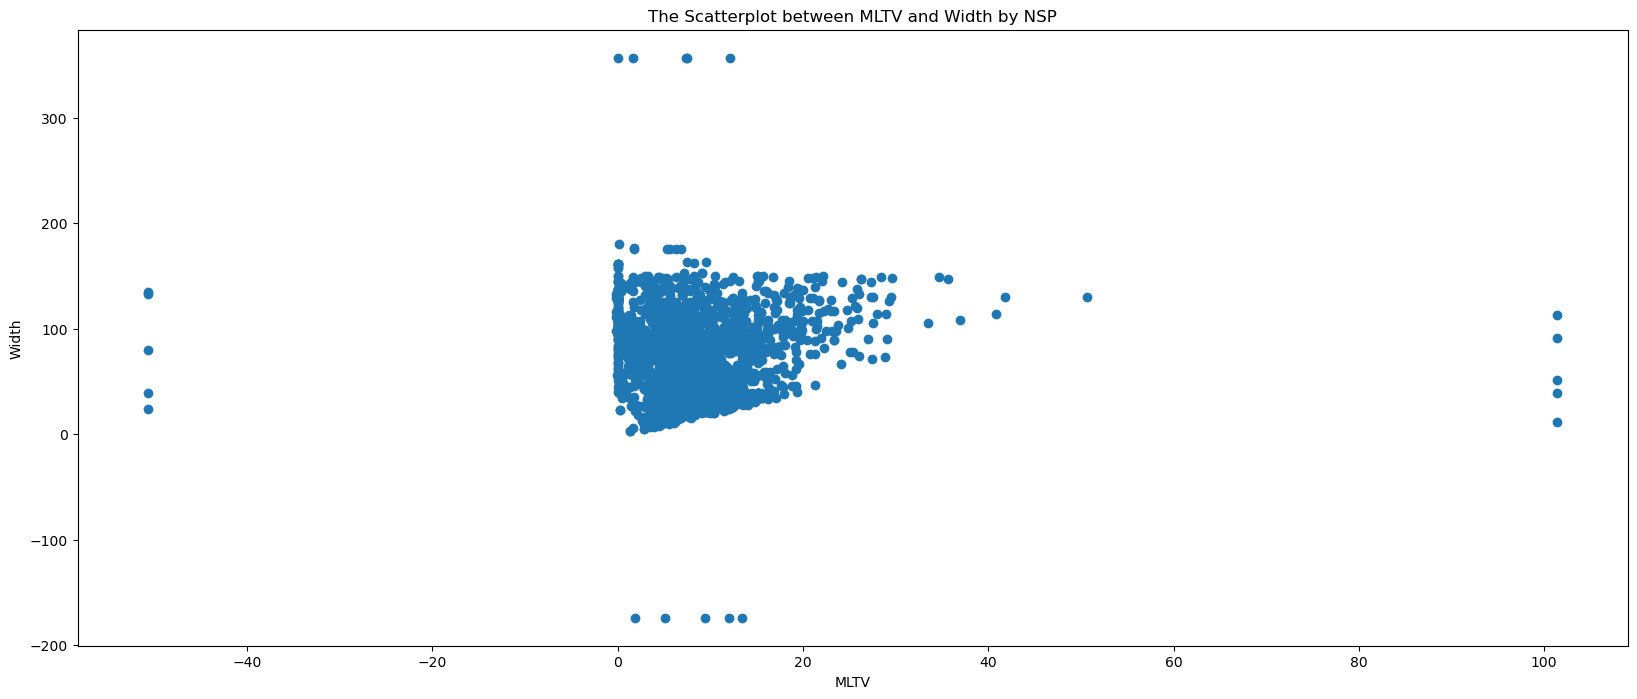

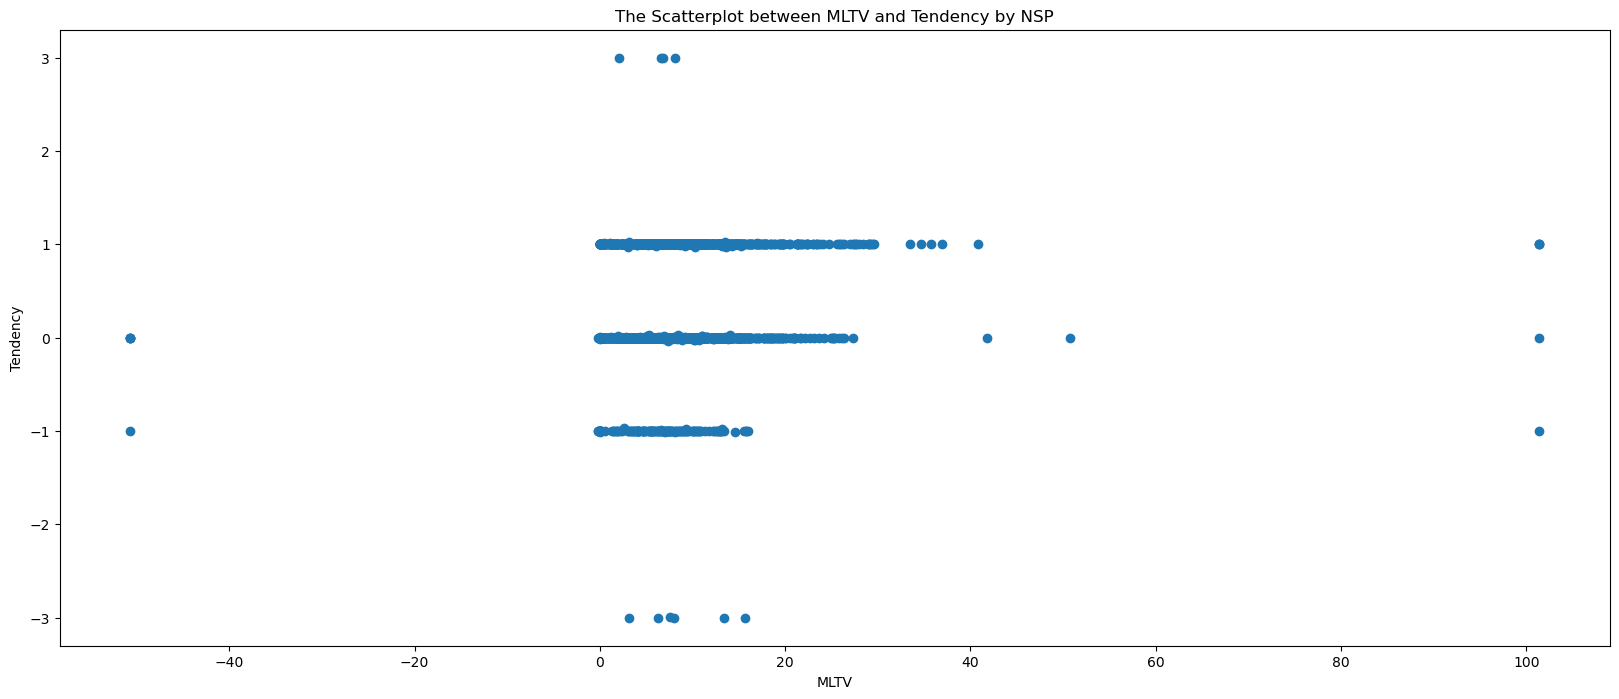

In [6]:
# Bivariate EDA


# All Posiible Scatter plot between Numerical variables
for i,x_col in enumerate(numerical):
    for y_col in numerical[i+1:]:
        if x_col < y_col:
            plt.figure(figsize=(20,8))
            plt.title(f"The Scatterplot between {x_col} and {y_col} by NSP")
            plt.xlabel(x_col)
            plt.ylabel(y_col)
            plt.scatter(x=x_col, y=y_col, data=df)
            plt.show()

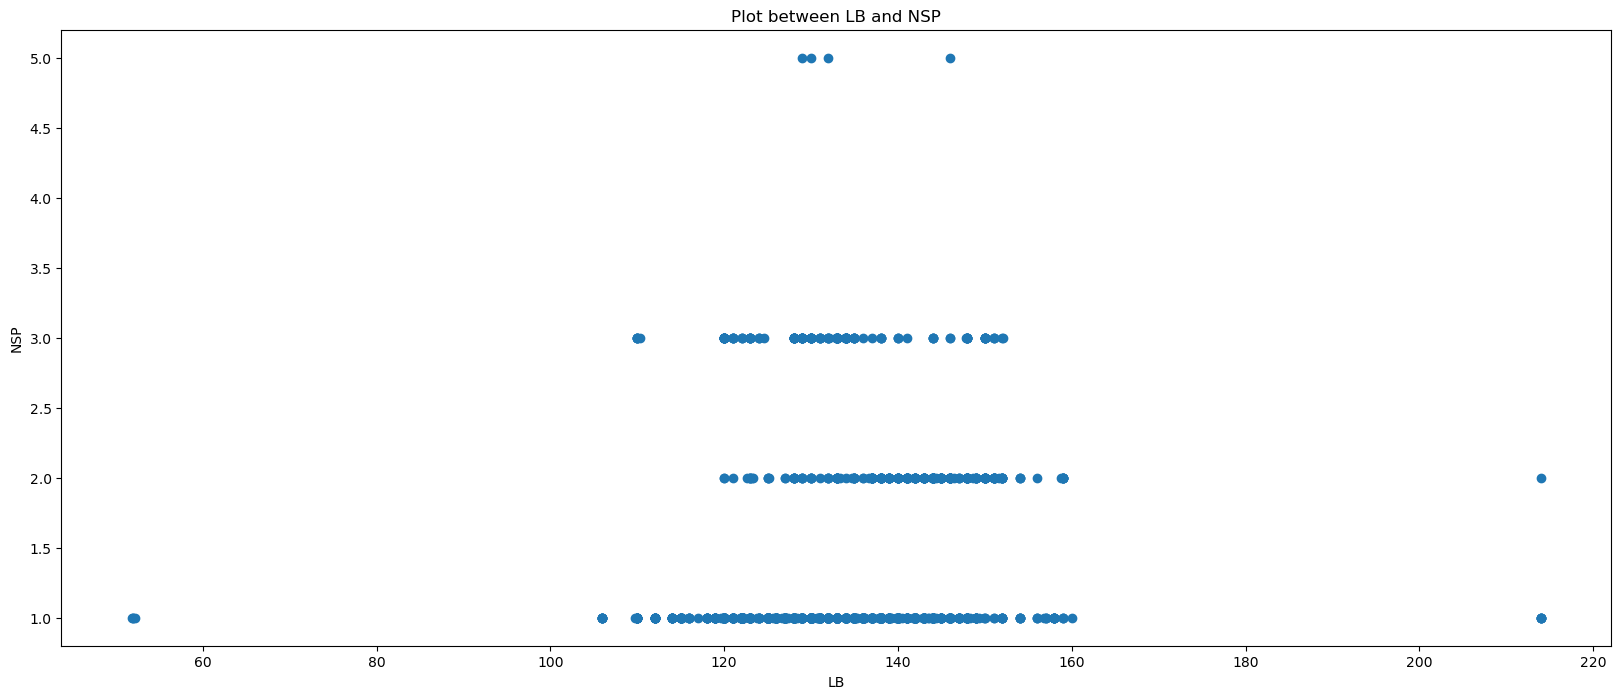

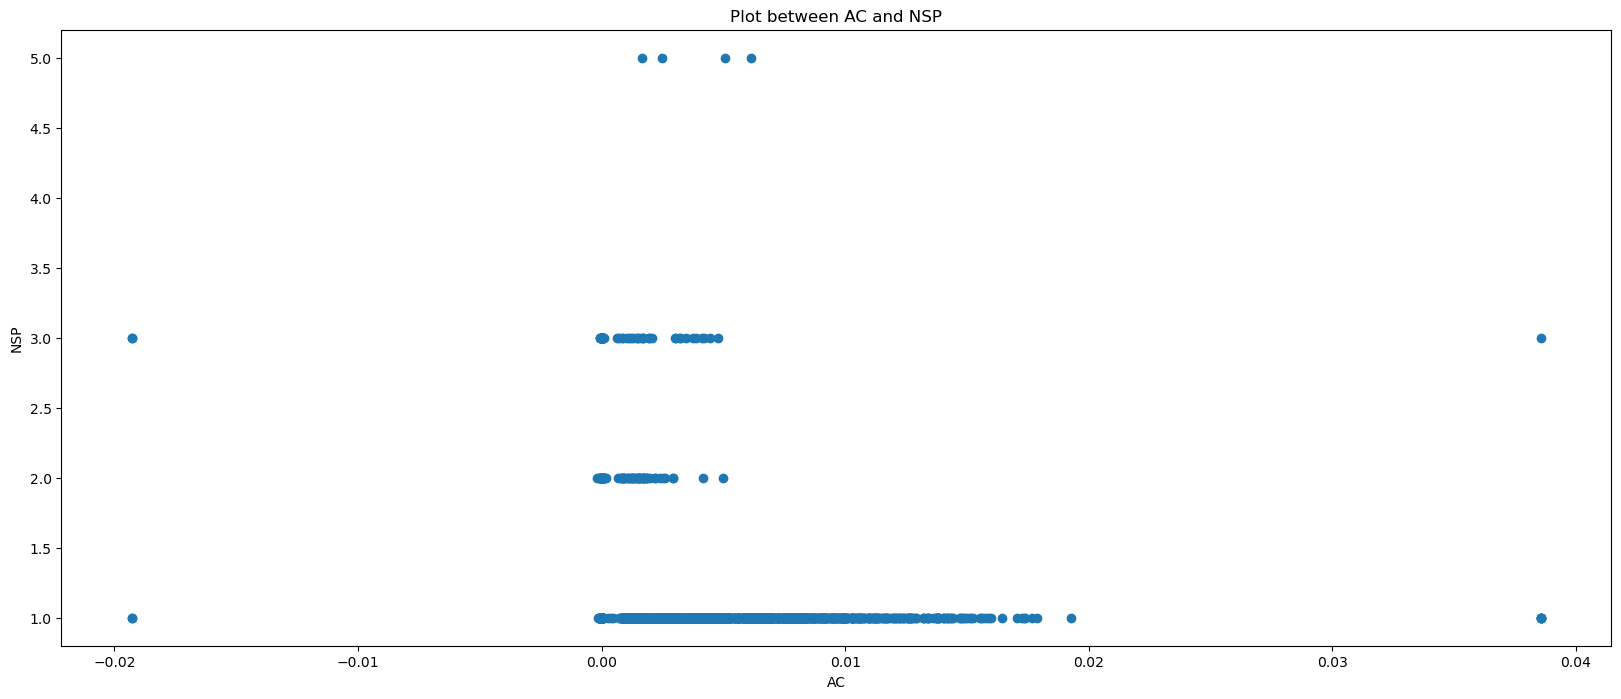

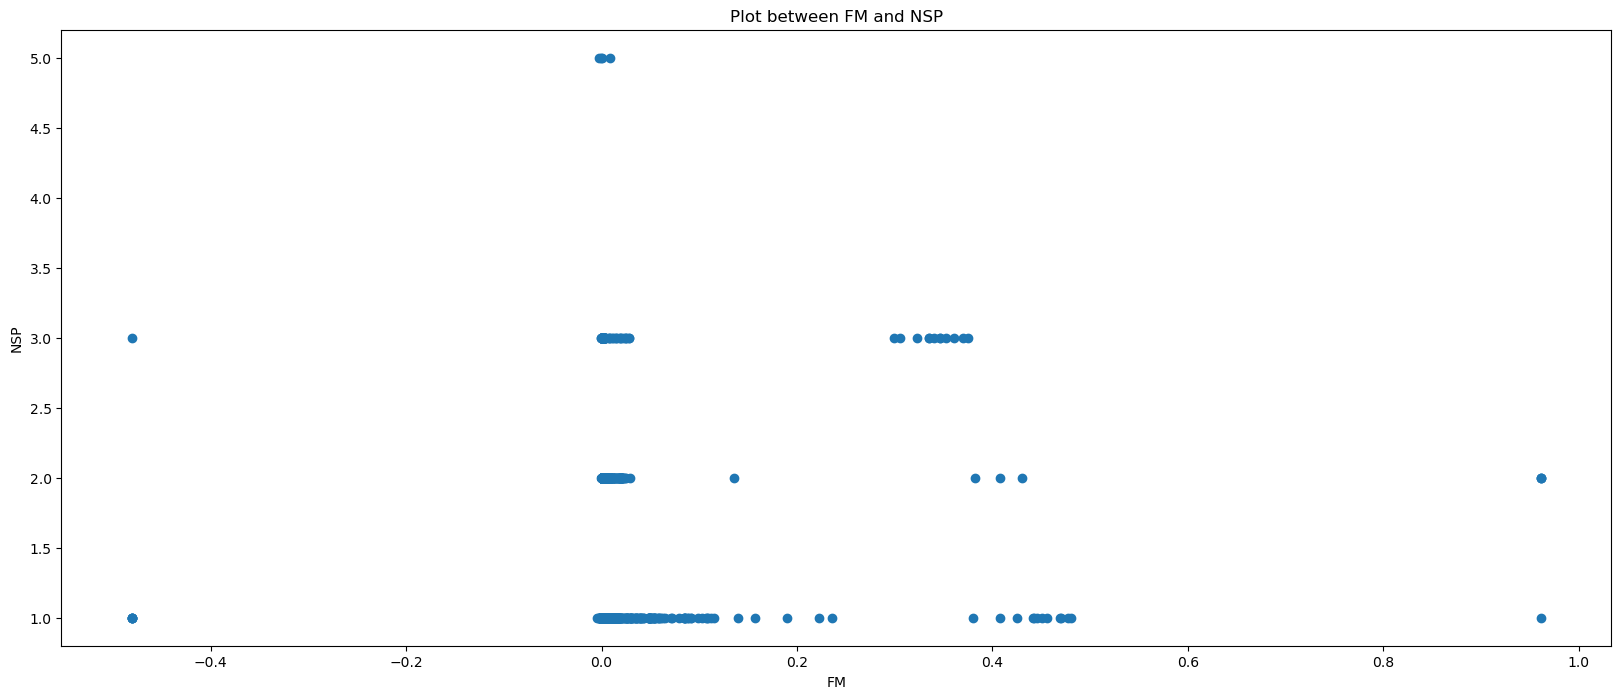

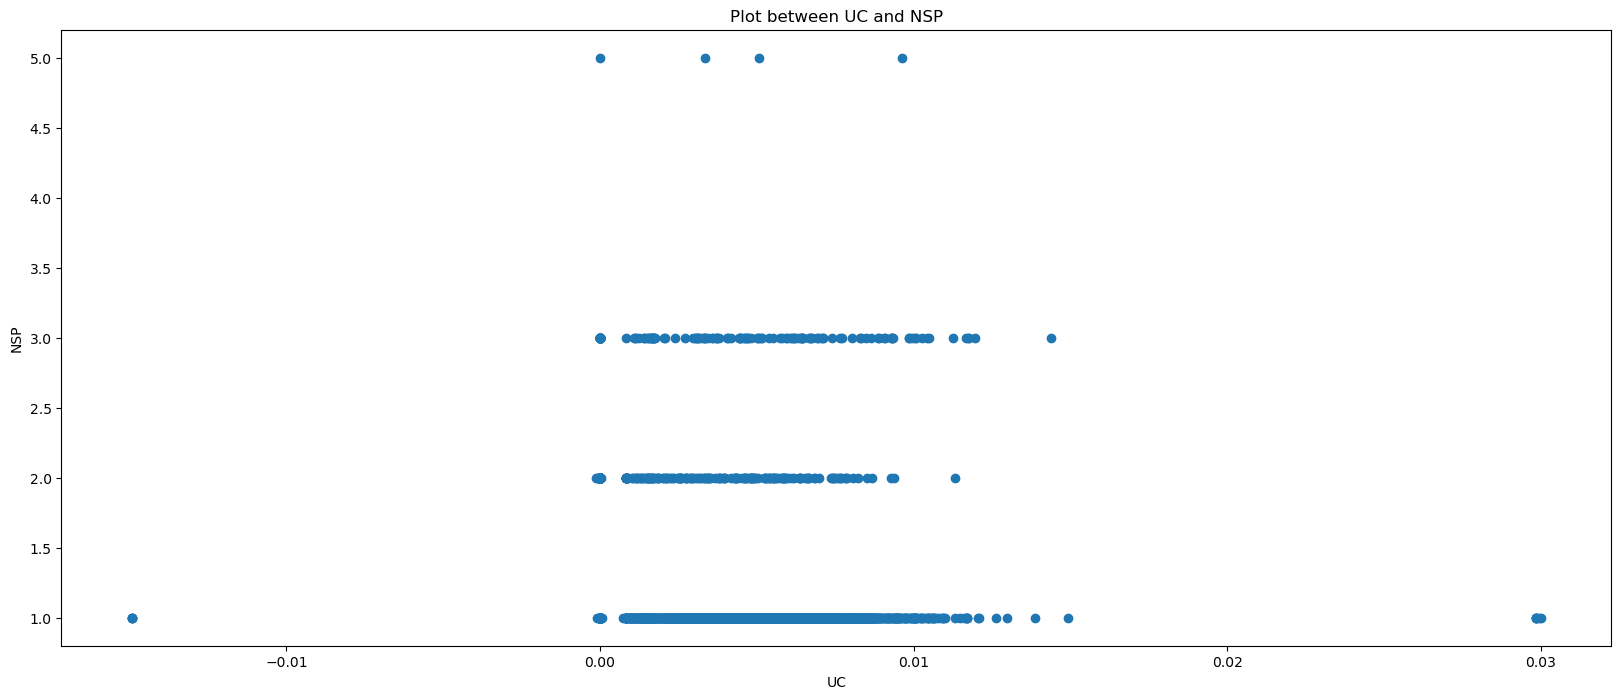

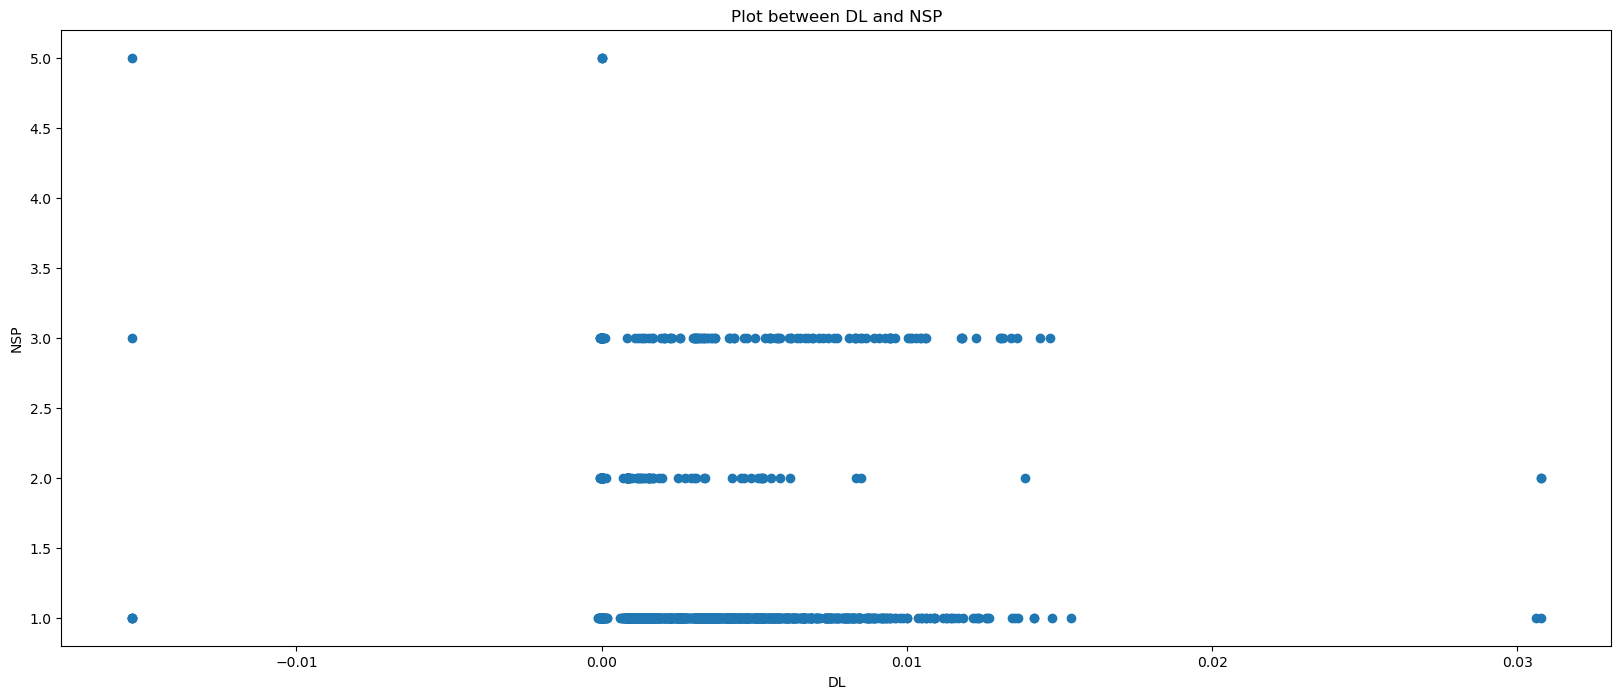

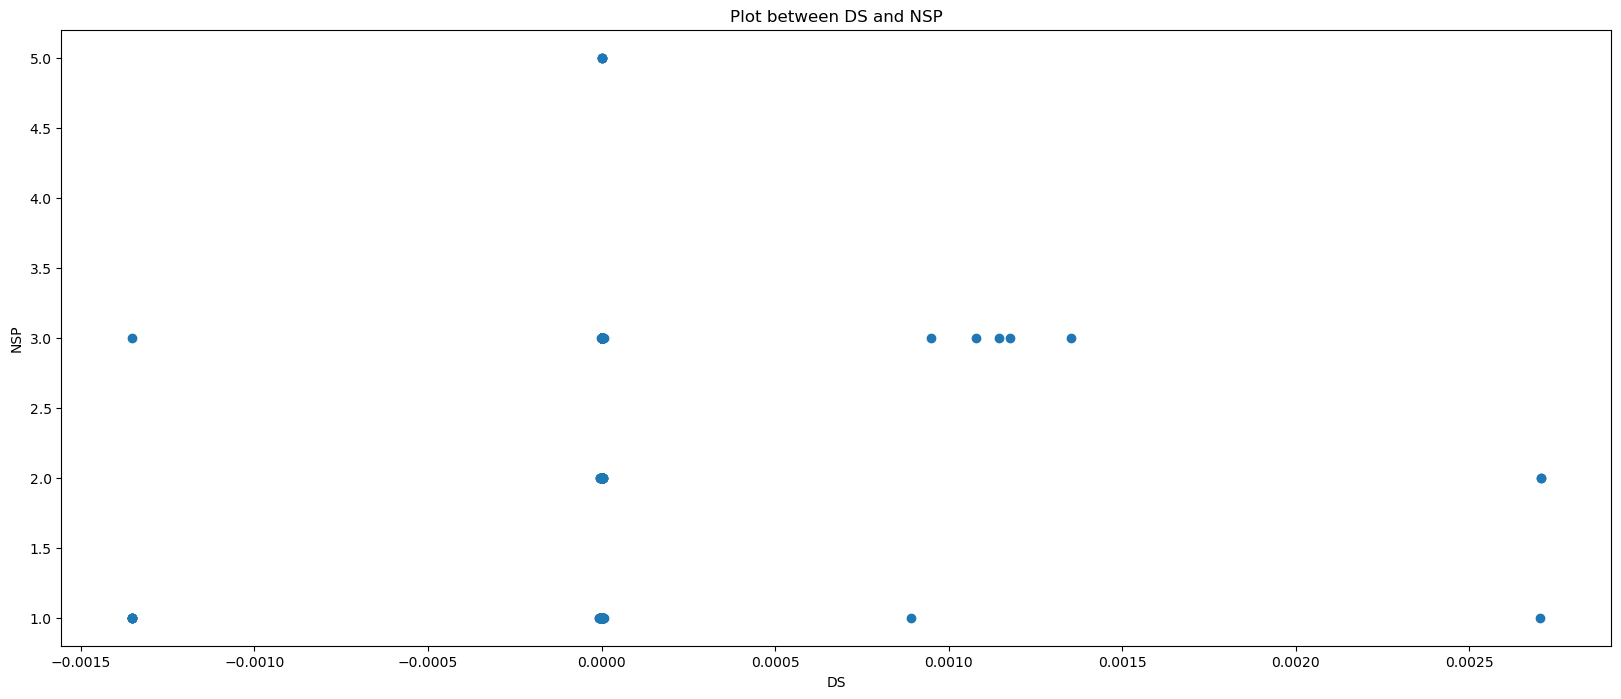

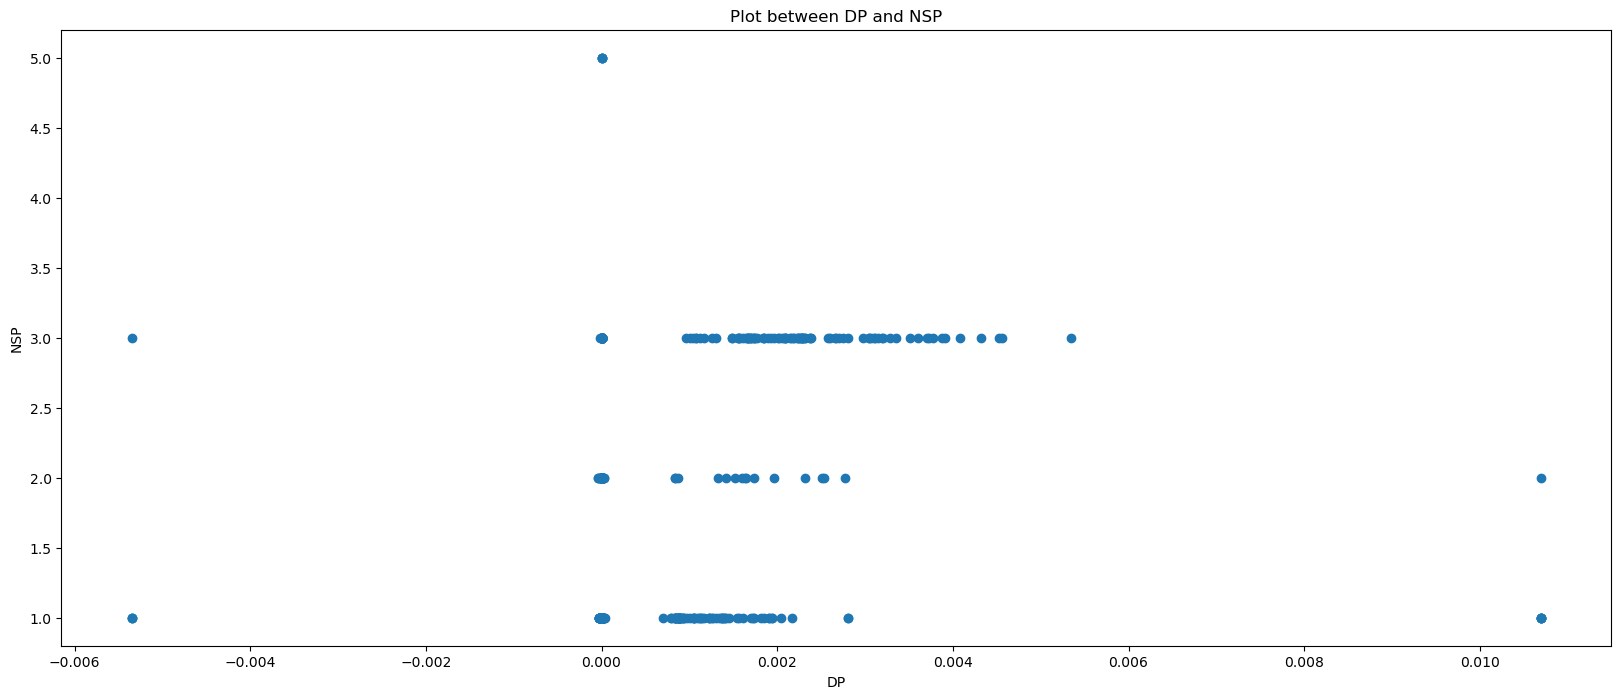

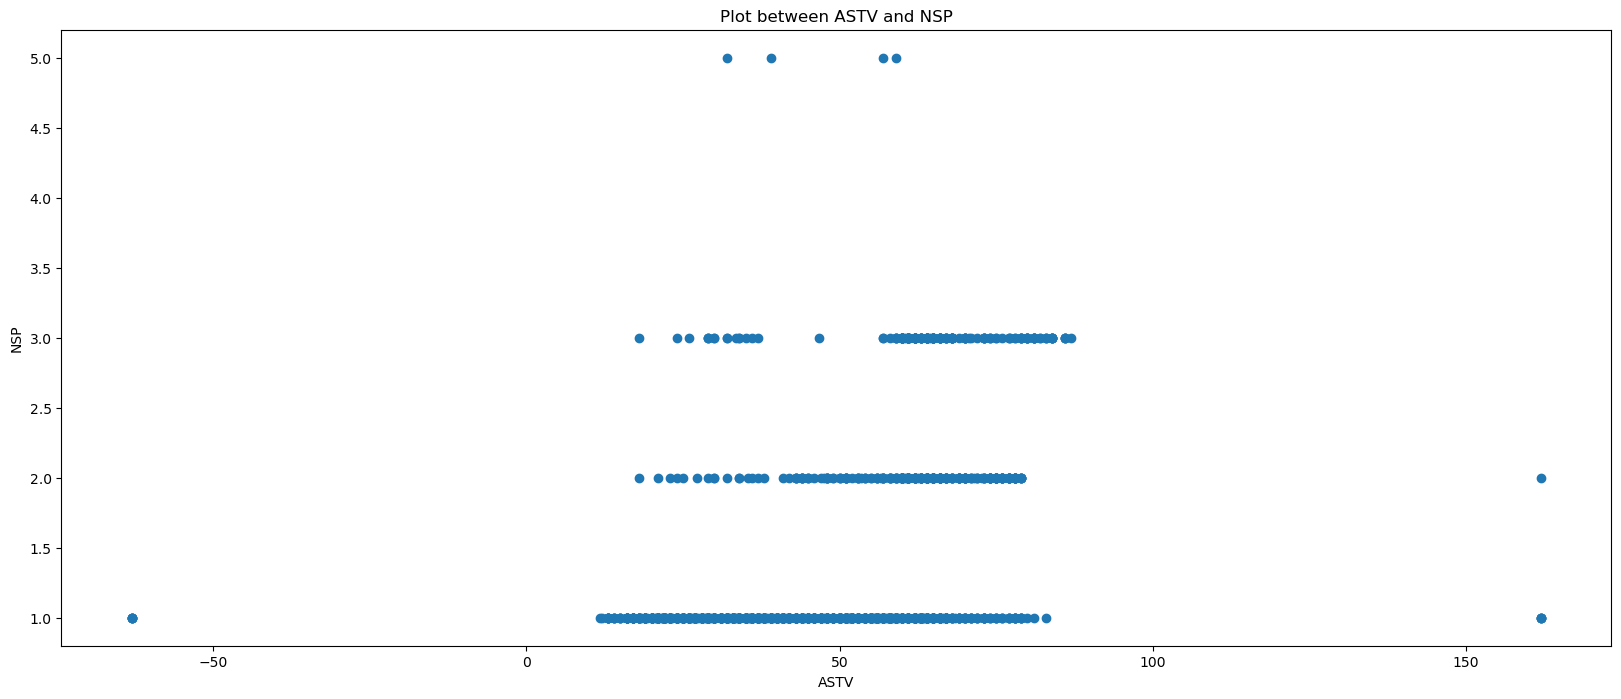

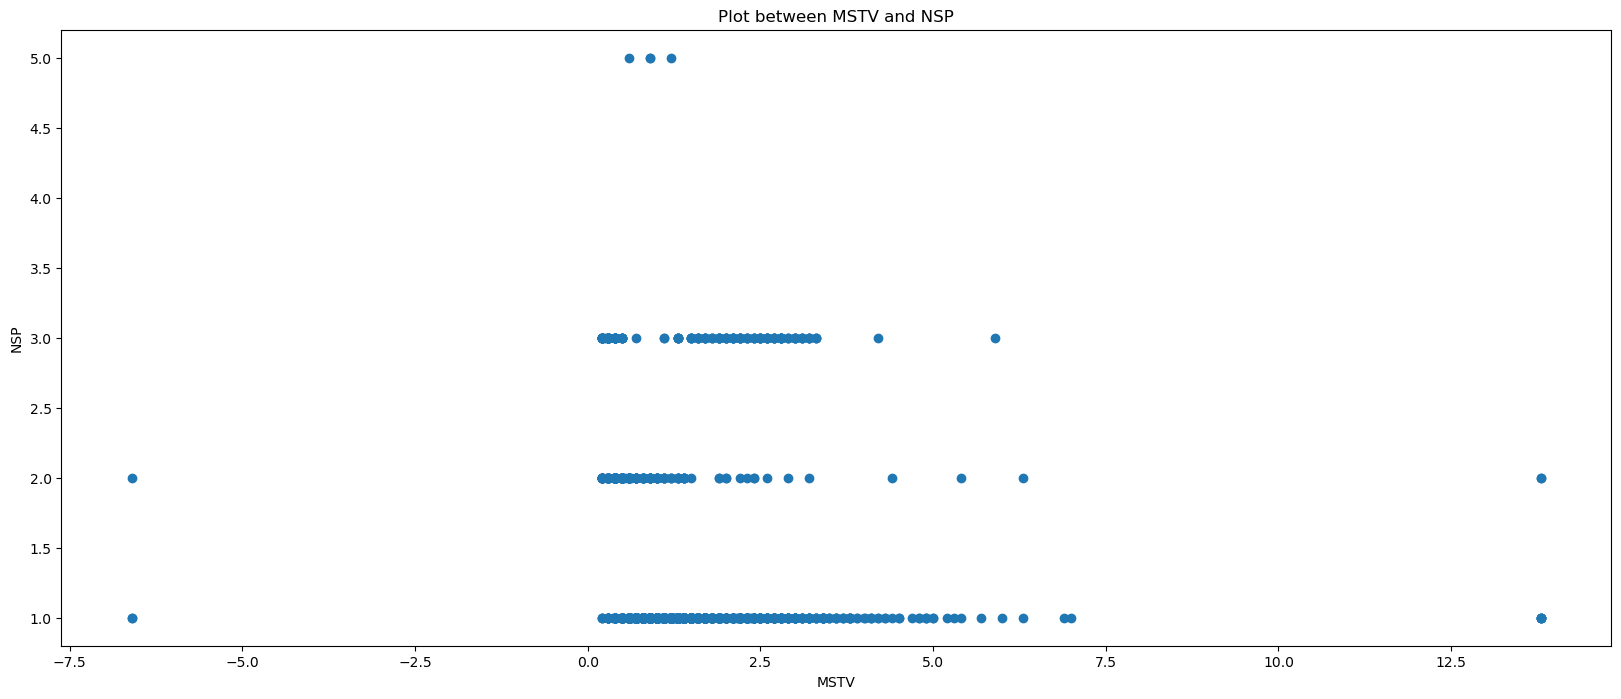

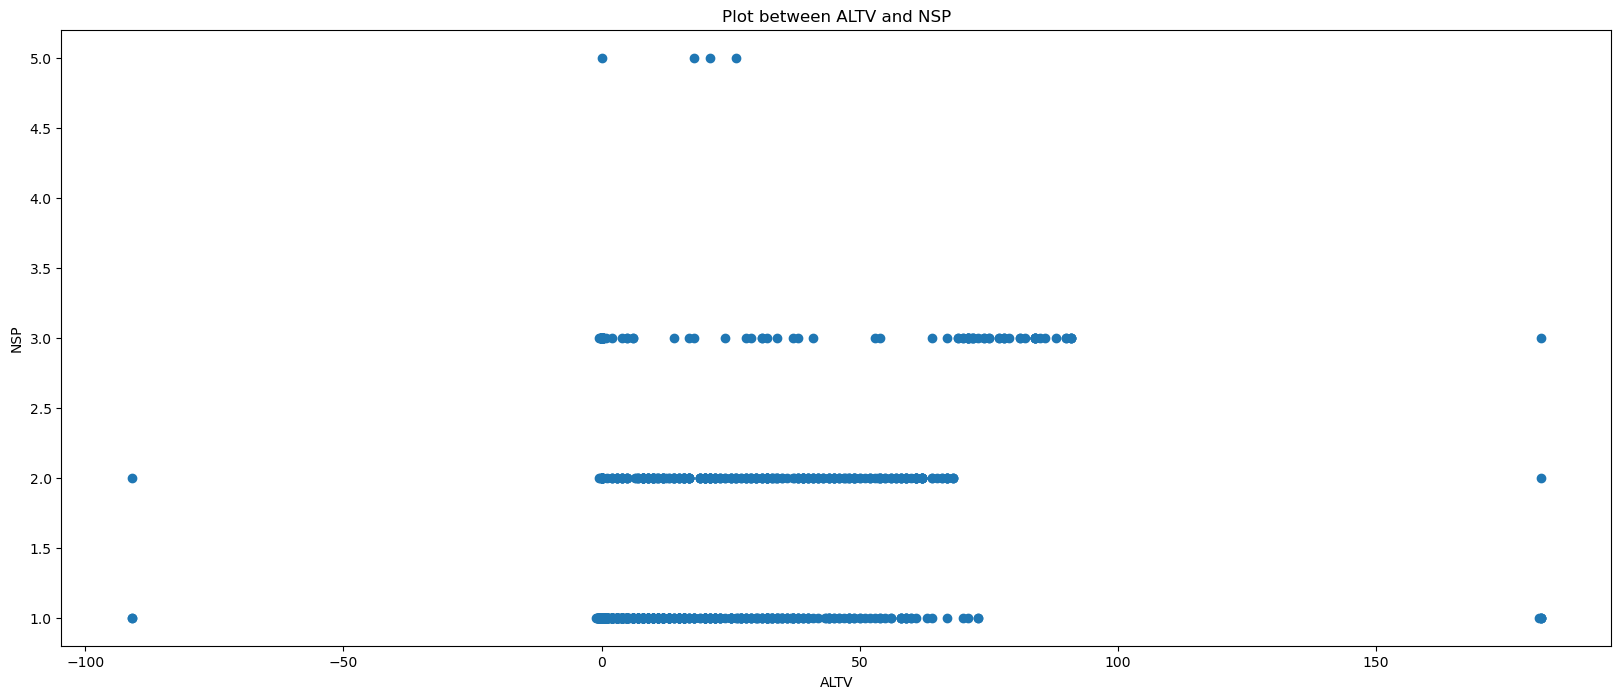

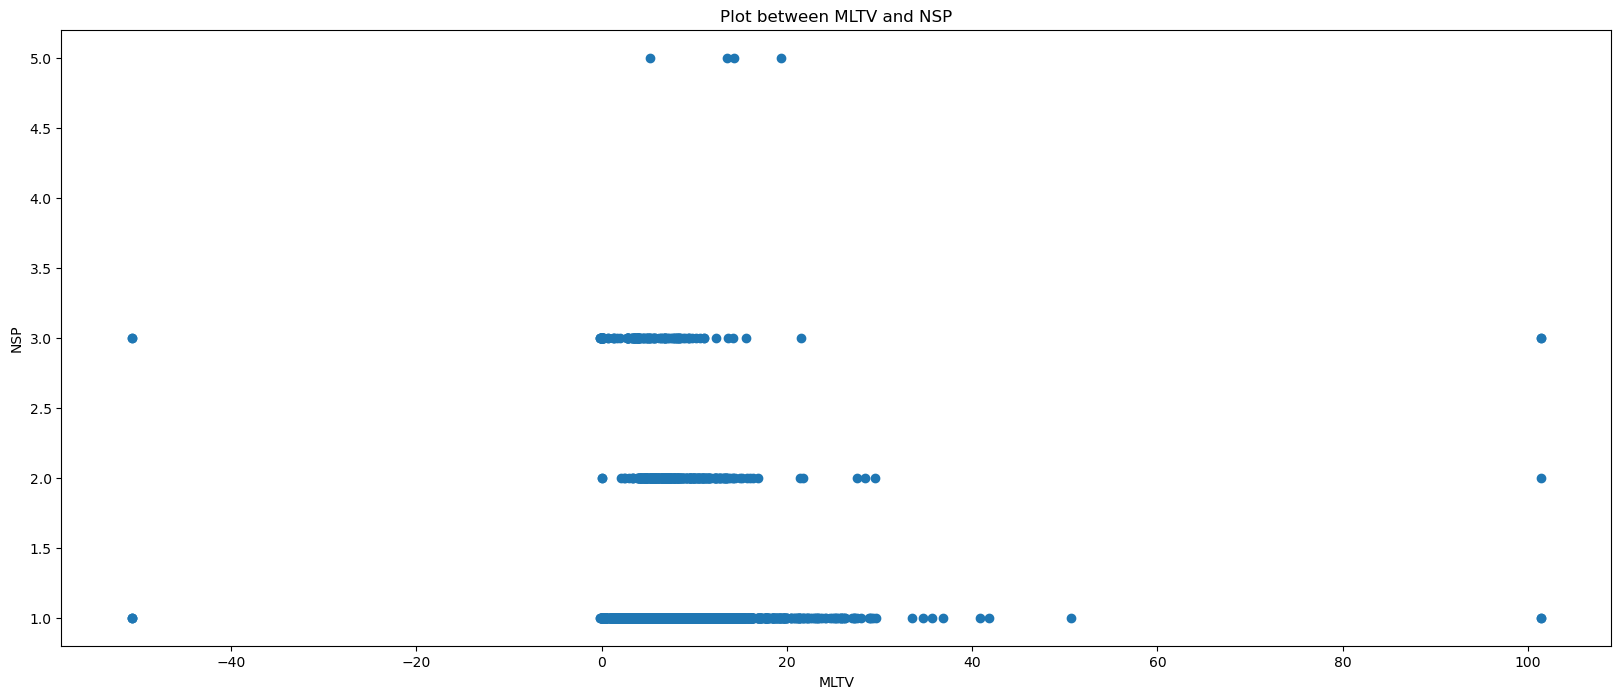

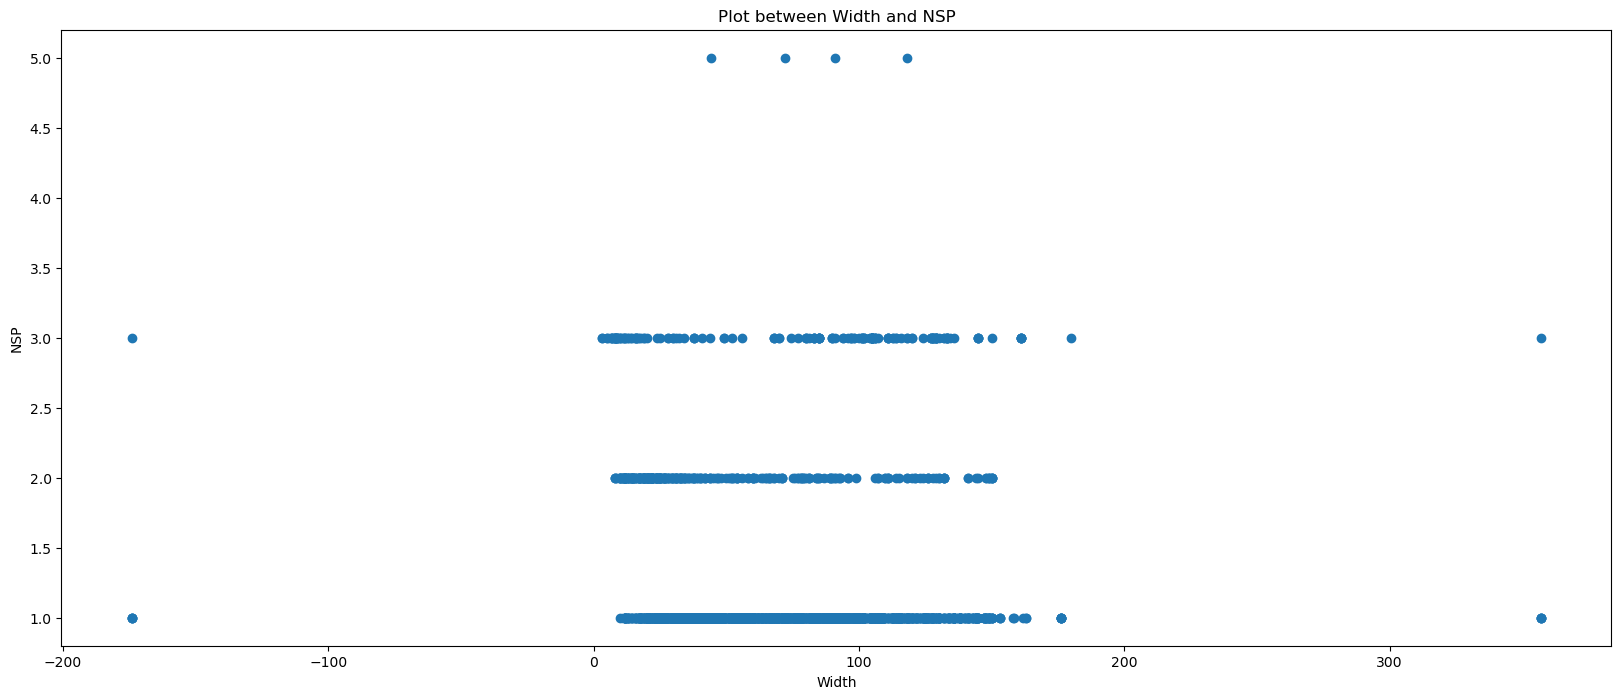

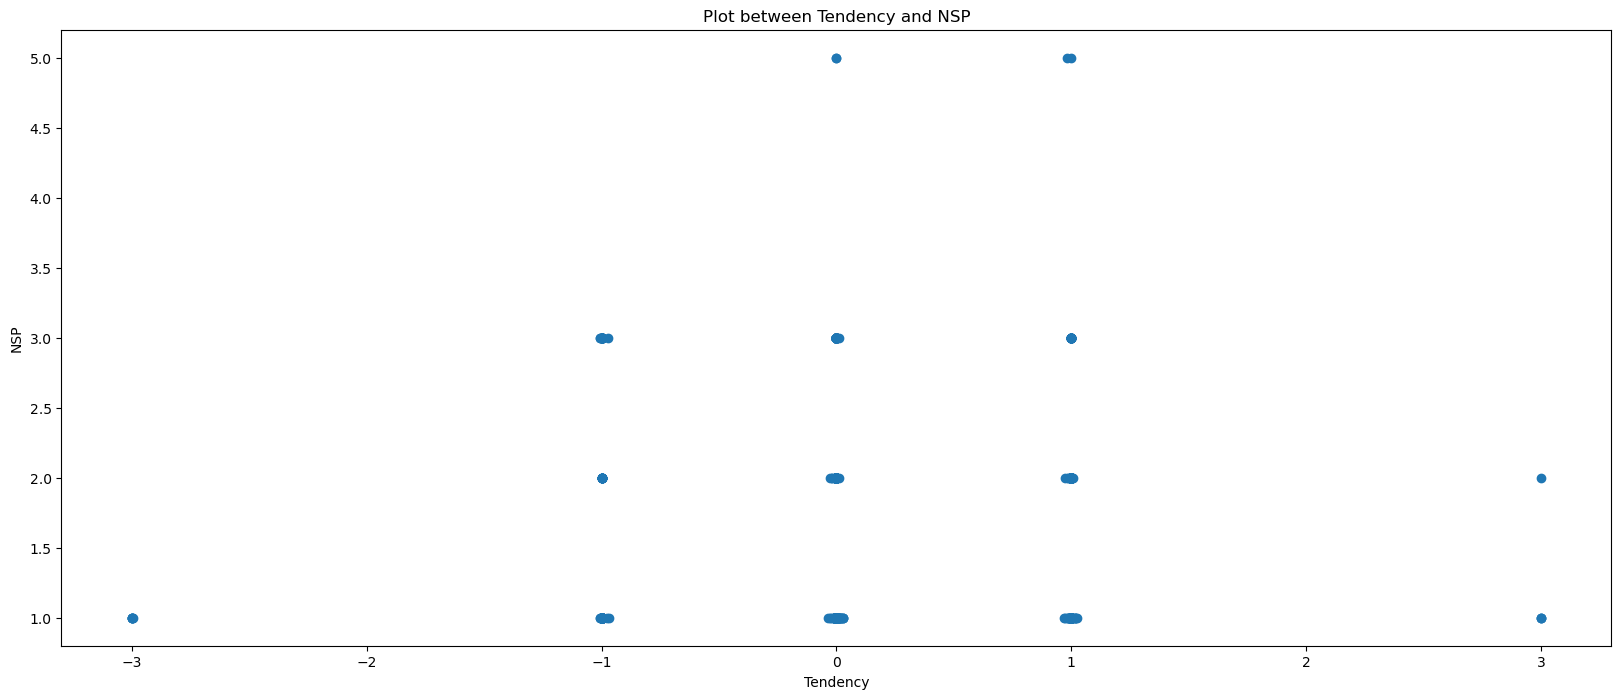

In [7]:
# Relationship between each numerical variables with the output categorical variable can be seen using Scatter plot below  
for col in numerical:
    plt.figure(figsize=(20,8))
    plt.title(f"Plot between {col} and NSP")
    plt.scatter(x=col, y='NSP',data=df)
    plt.xlabel(col)
    plt.ylabel('NSP')
    plt.show()

## Advance Visualization techniques

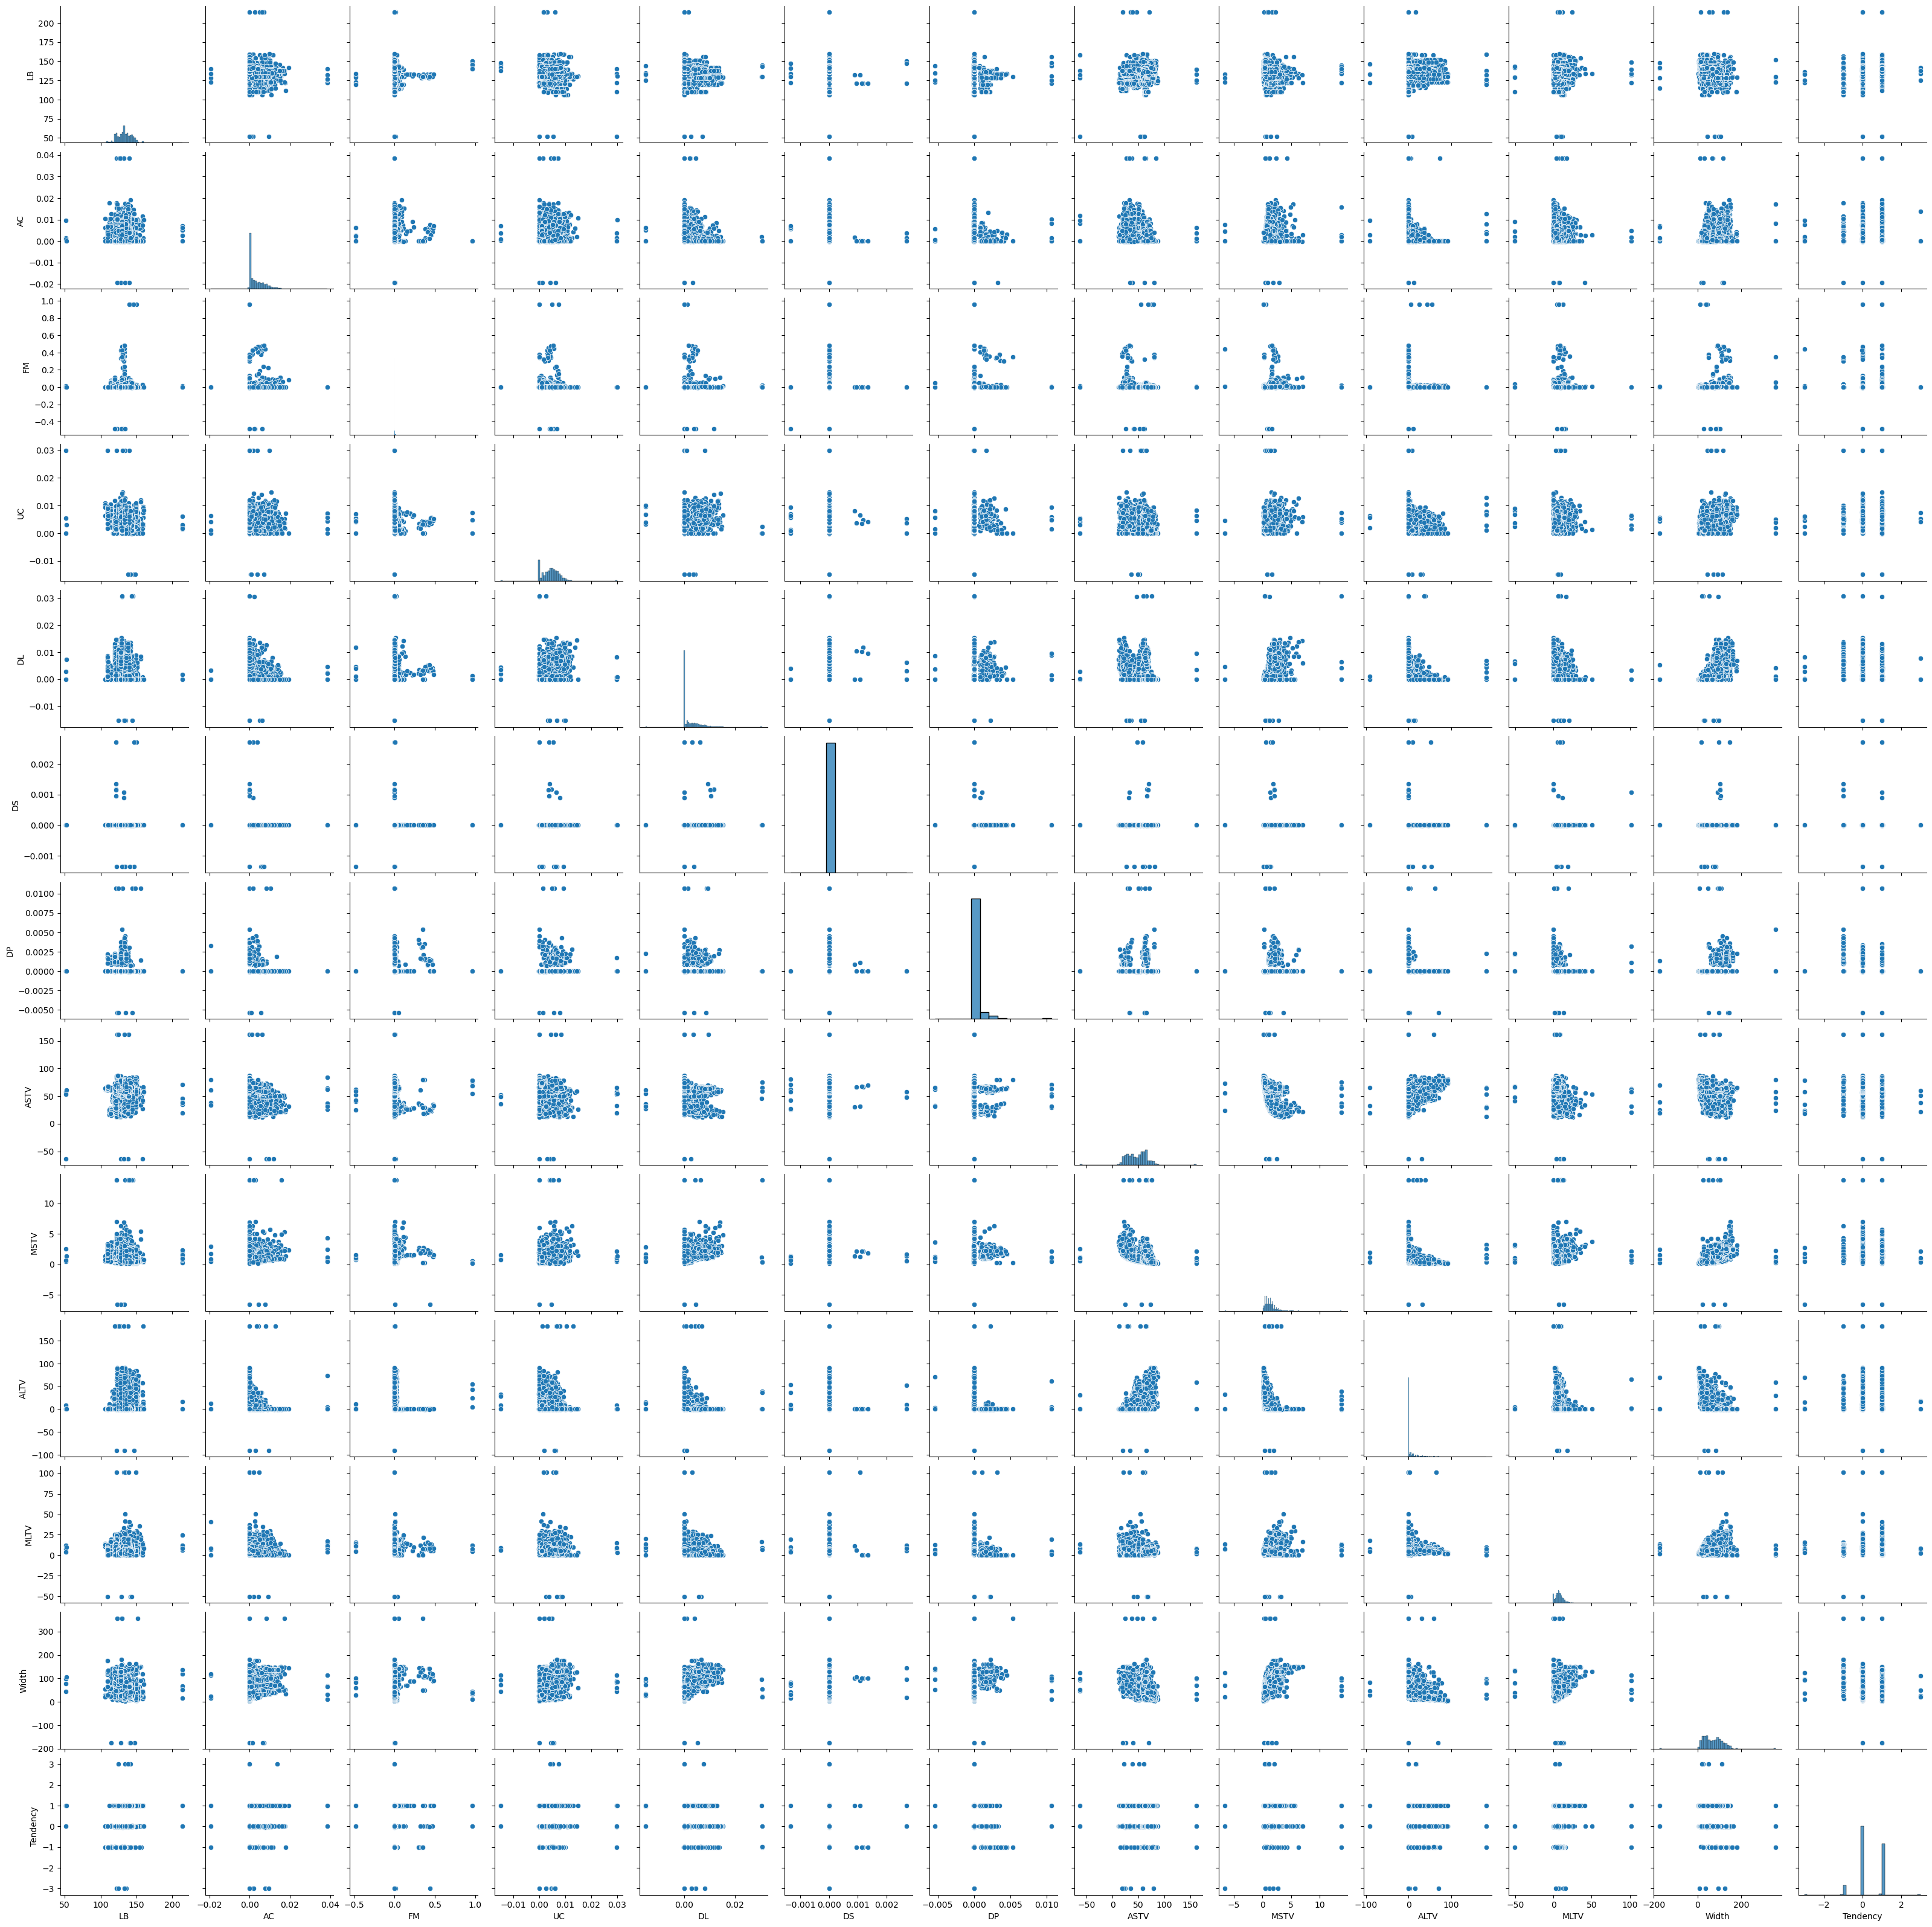

In [8]:
# Pairplot: This specifically describes the relation between the numerical variables and with the 
sns.pairplot(df)
plt.show()

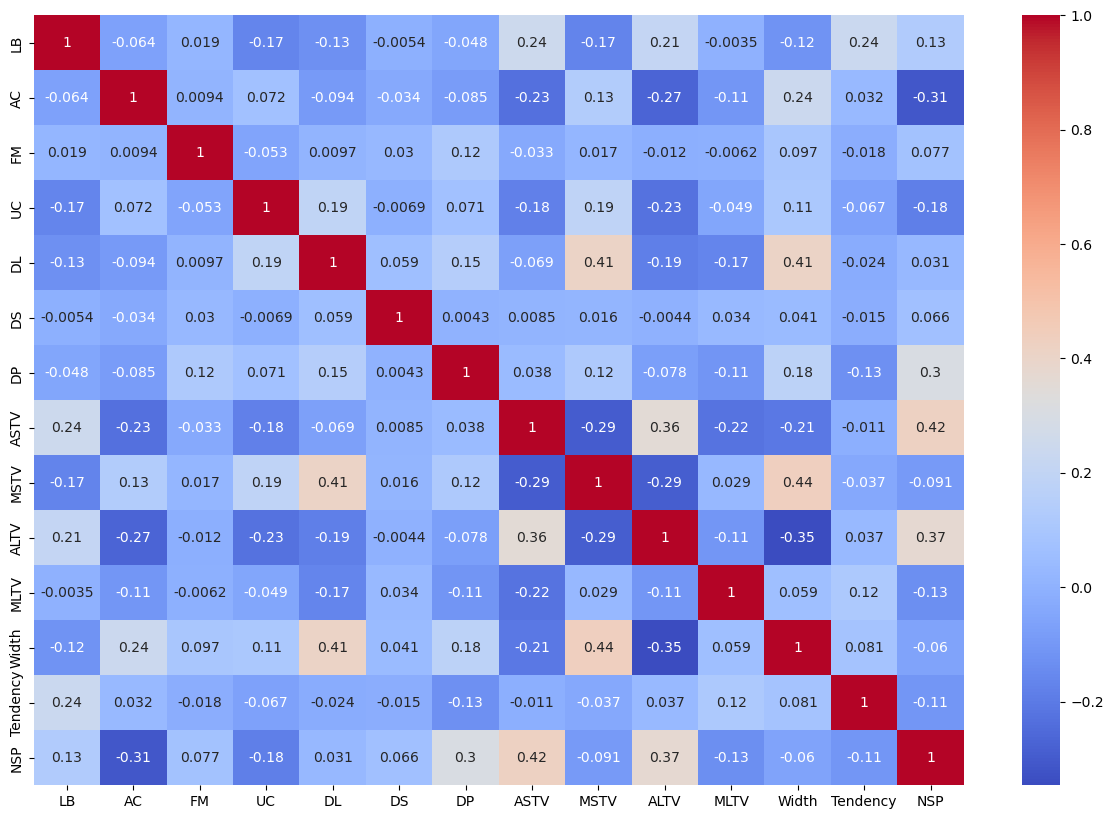

In [9]:
# Heatmap
plt.figure(figsize=(15,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=True)
plt.show()

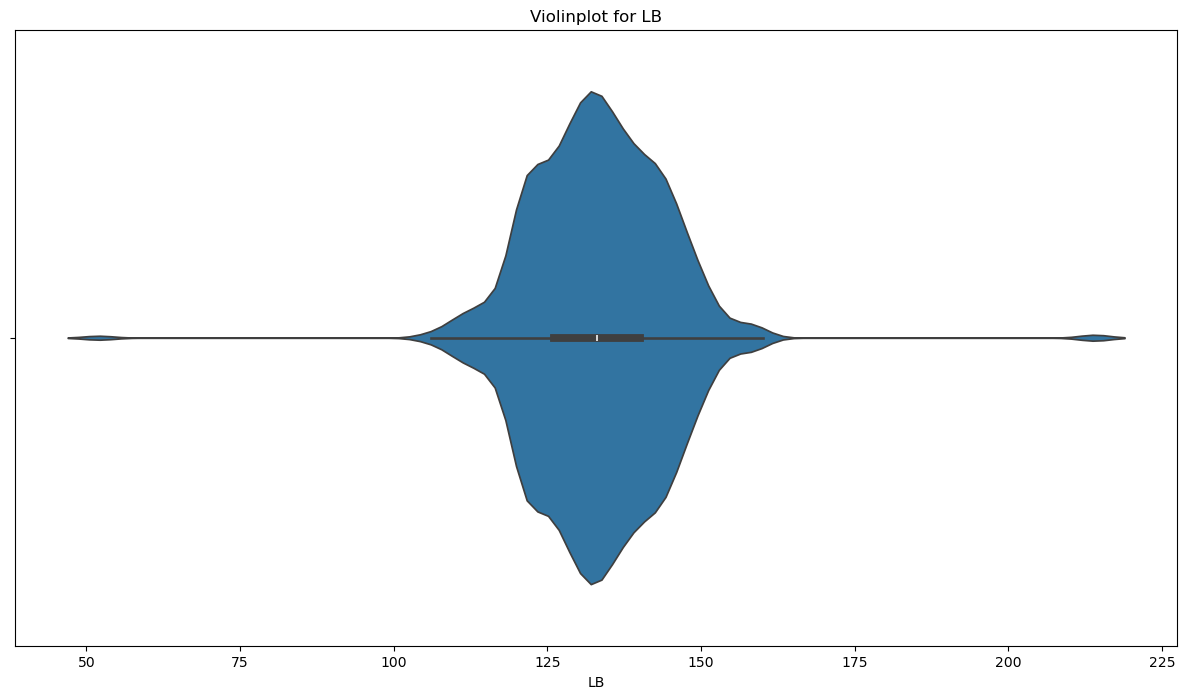

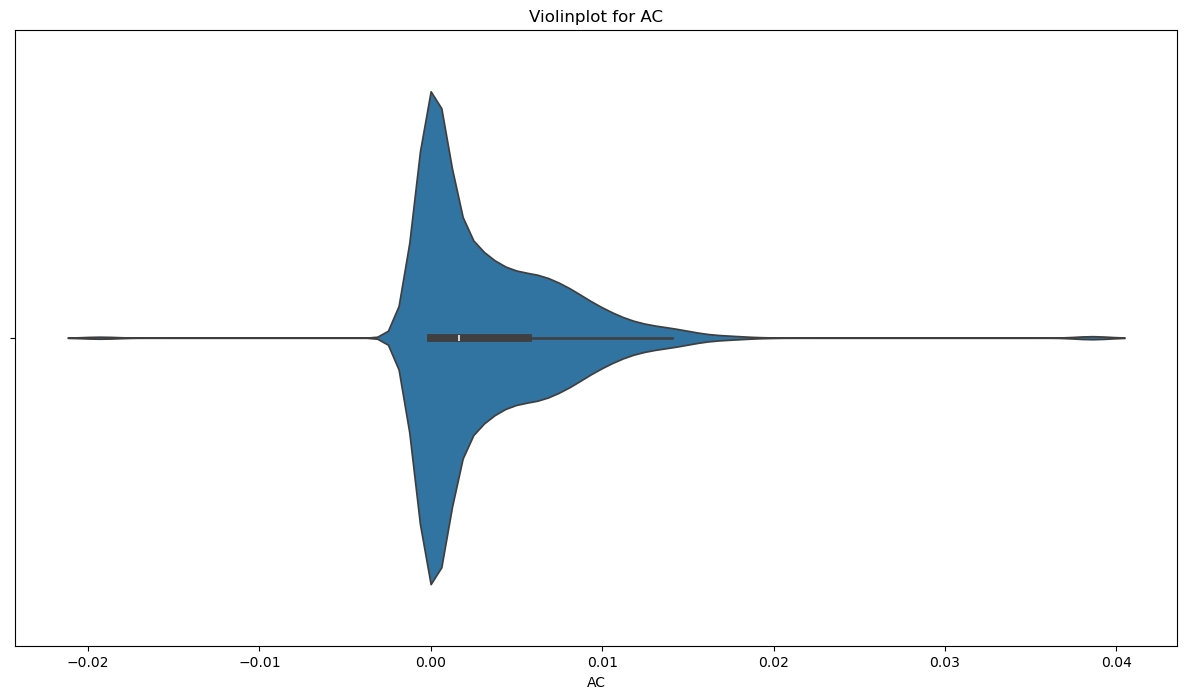

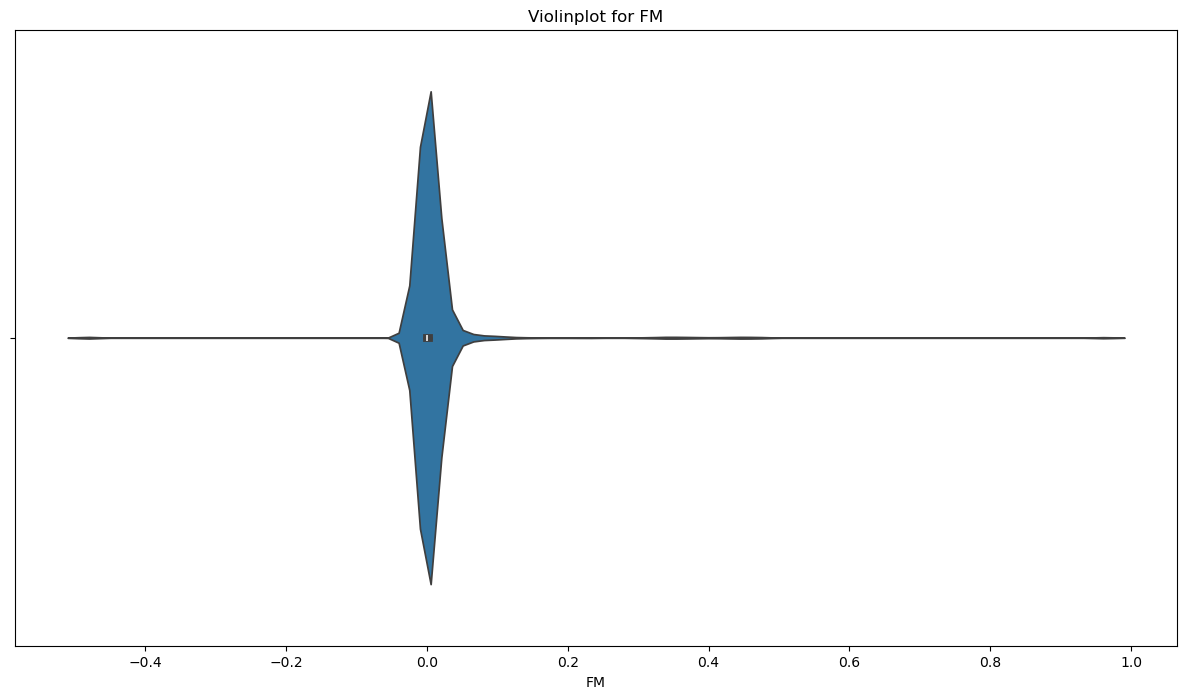

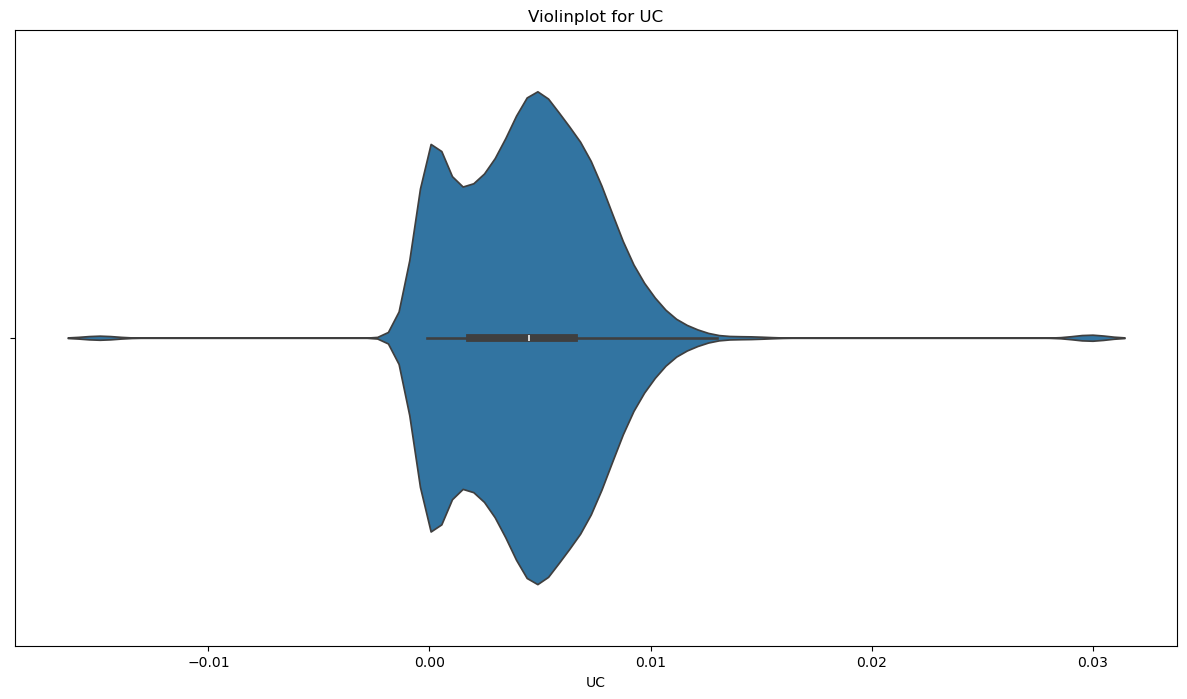

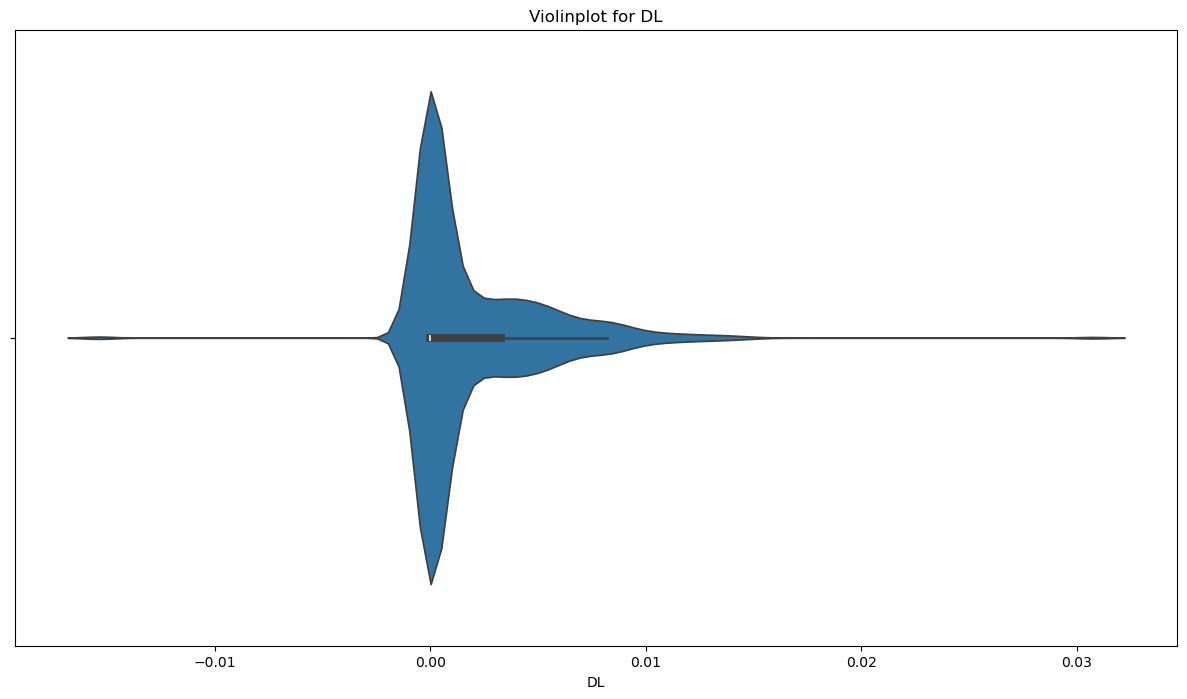

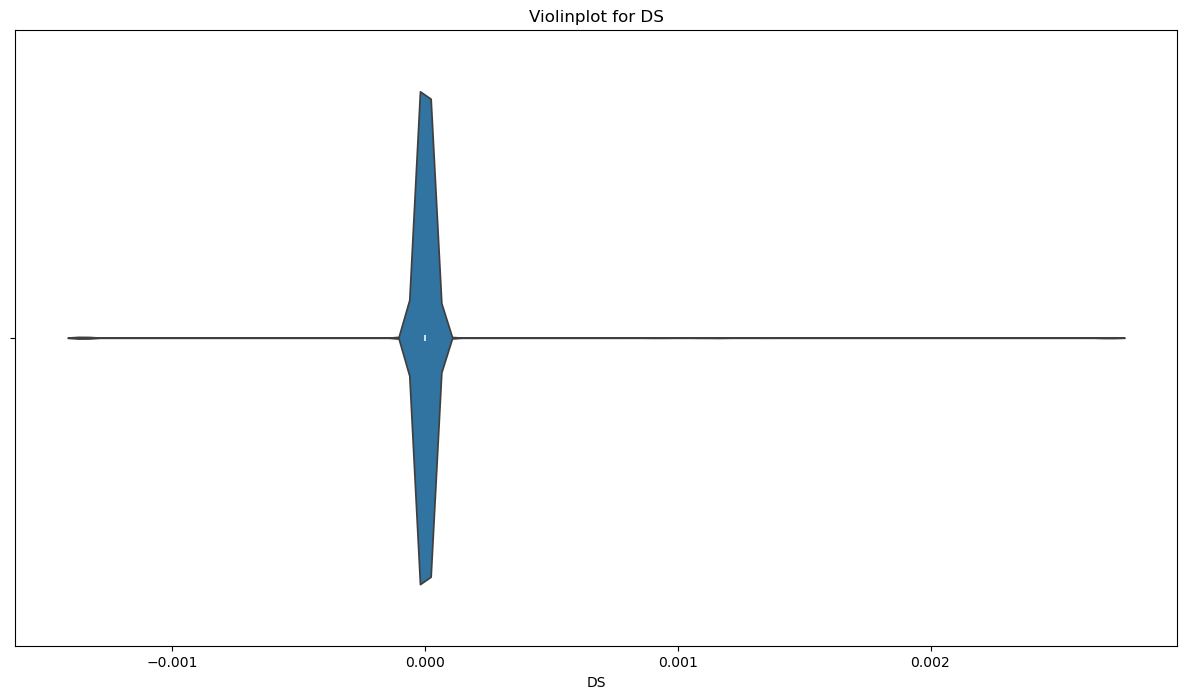

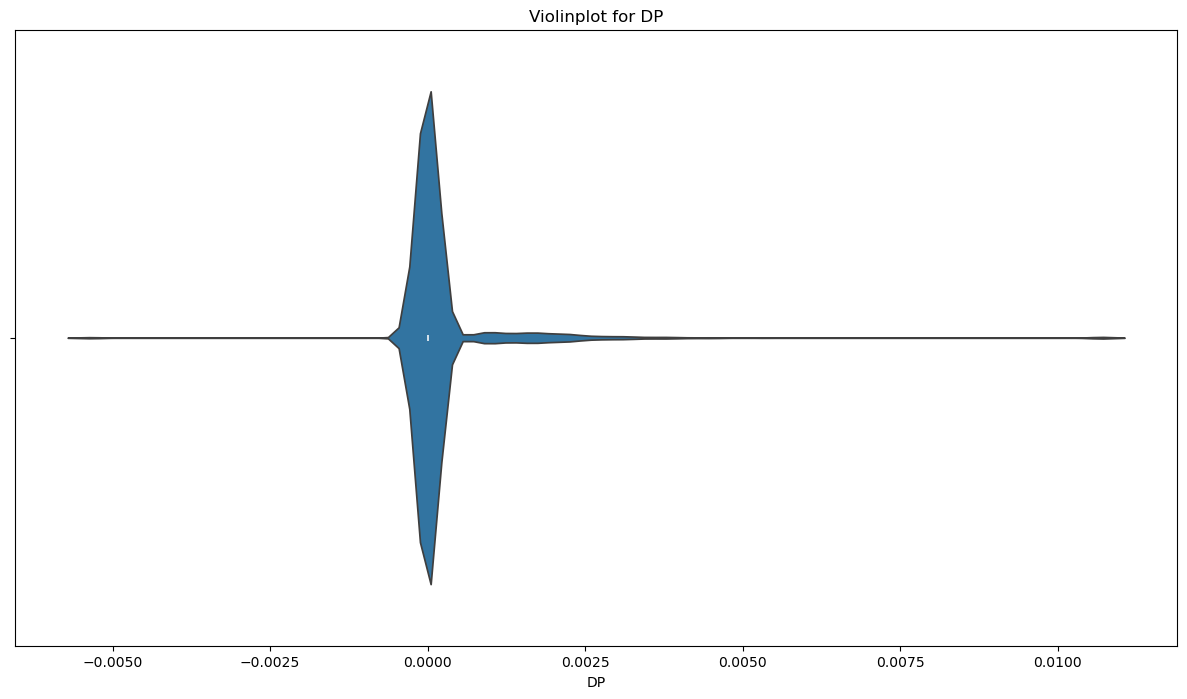

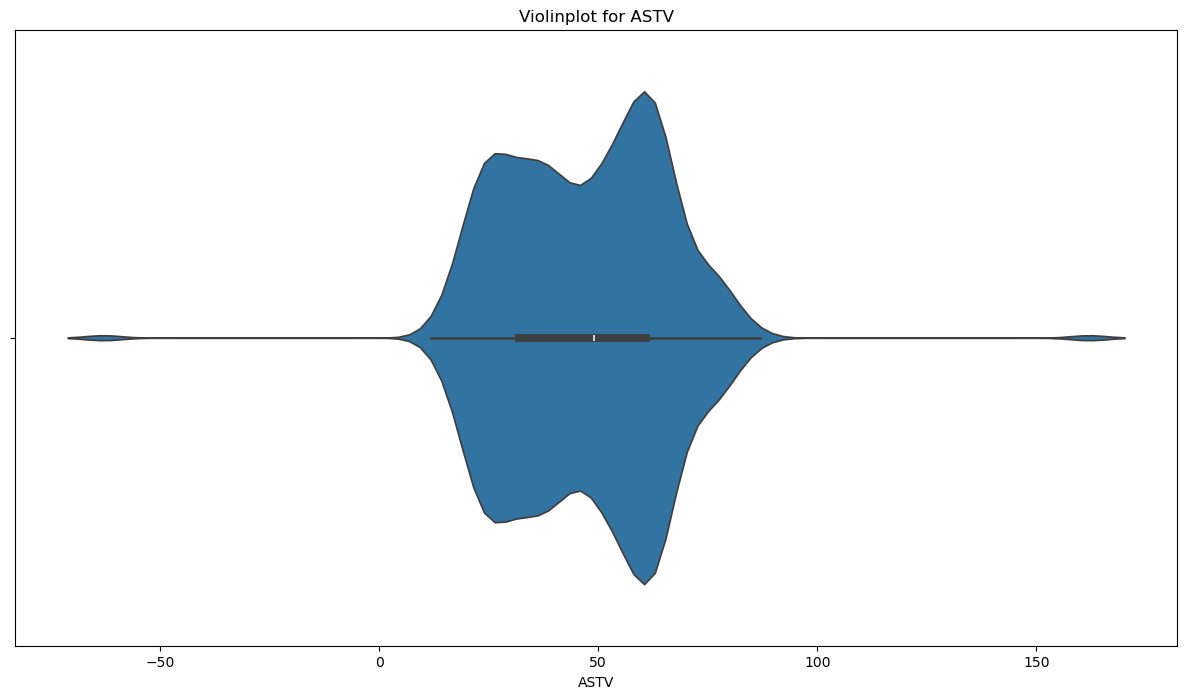

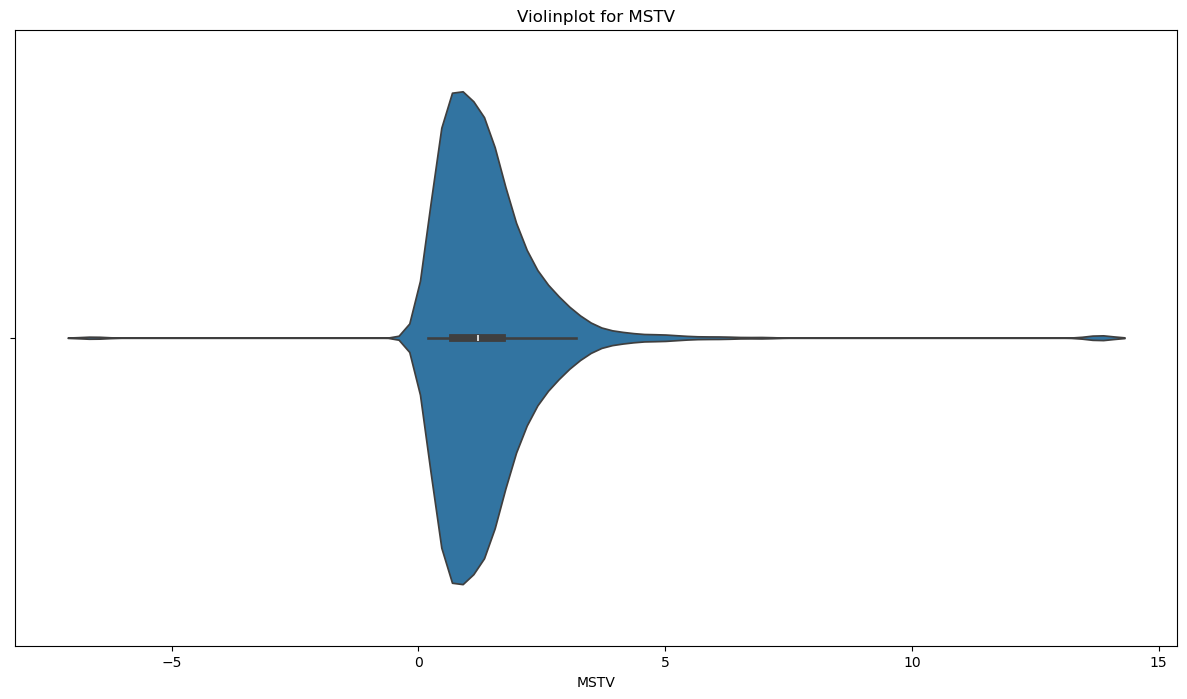

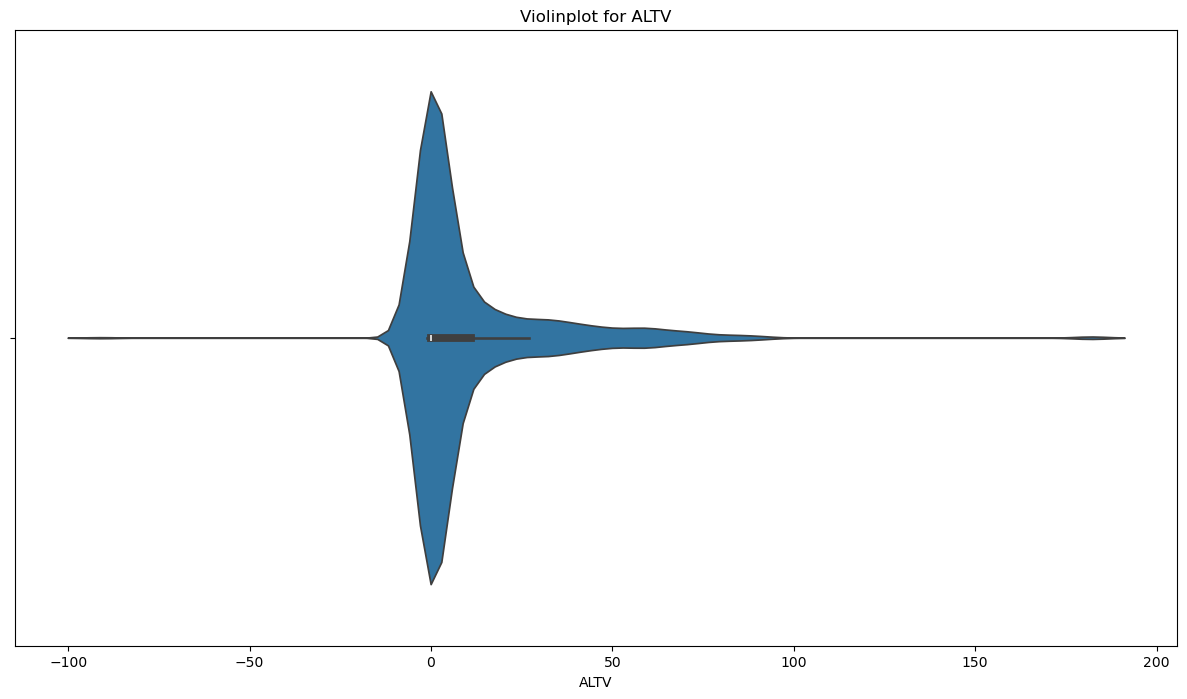

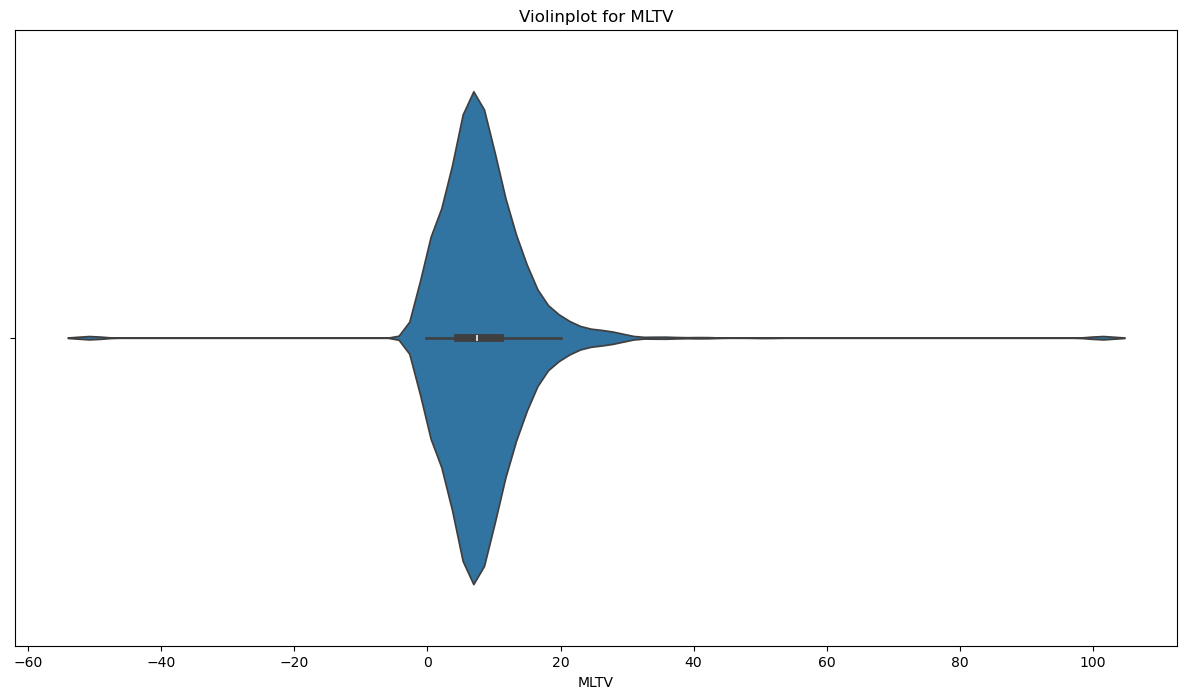

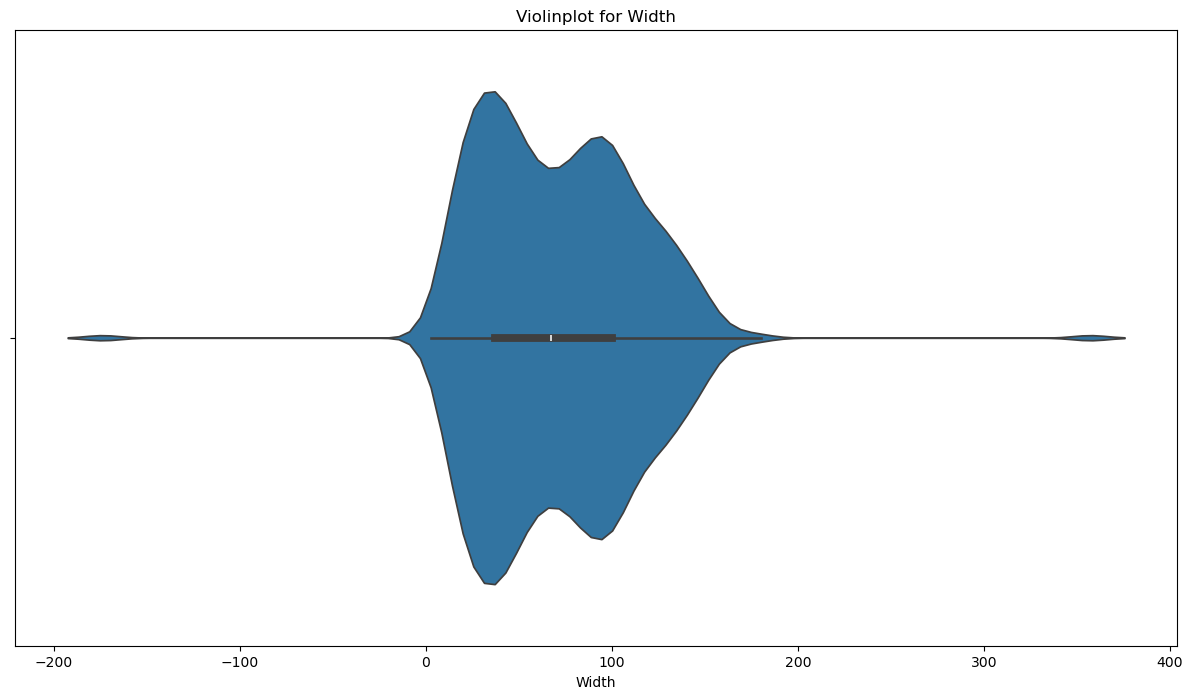

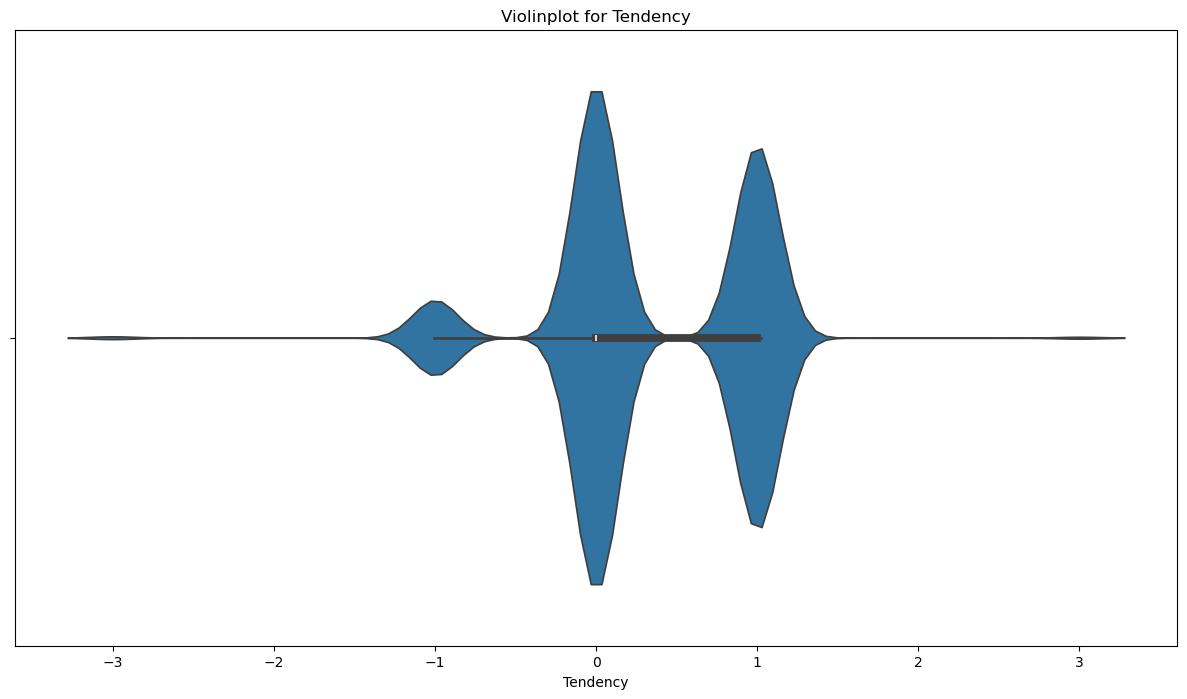

In [15]:
# Violin plot:
for col in numerical:
    plt.figure(figsize=(15,8))
    plt.title(f"Violinplot for {col}")
    sns.violinplot(x=df[col])
    plt.show()

## Pattern Recognition:

### Histogram:
```
Ans: Histogram gives the frequency distribution of the individual vriables which varies in a certain intervals.
It tells how many times that variable has been appeared in an interval.
```

### BoxPlot: 
```
Ans:
i) Boxplot gives the insights of the dataset.
ii) It helps to detect the outliers in the dataset, also it describes the skewness(eg, Right Skewed, left skewed).
                eg. The dots that are shown outside of both lower and upper whisker represents the Outliers,
                         as you can see in the abobe graph.
iii) In case of the right-skewed distribution the length of the lower whisker is small as compared to the upper whisker.
                eg. Boxplot of the AC.
iv) In case of the left-skewed distriution the length of the upper whisker is small as compared to the lower whisker length.
                eg. Boxplot of Tendency.
```
### HeatMap:
```
i. In heatmap we can have the idea how the variables are related to each other. Bsically it is used to represent the correlation between the variables.
ii. The values inscribes inside each box represents the quantitative relationship between variables.
iii. It varies from -1 to +1 , where 1 represents the strong relationship and the -1 reprents weak relationship between the varibles.
iv. The color of the heatmap, we can clearly see the deep blue represents the weakk relation and with decrease in deepness of color also the relationship increases and when the relationship maximum it becomes red (relationship of varibles withh themselfs).

```
### Violin Plot:
```
i. Violin plot represents the same things as represented by the boxplot, the only difference is that,  data distribution is well expained by the violin plot then the box plot.
ii. In violin the middle small white dot shows the median value as the middle line in the box plot.
iii. Clearly, we can see the how data has been distributed like whether it is right skewed or left skewed.
```

## Data Cleaning

In [11]:
# Performing these actions on the different copy of the file 
clean_df = df.copy()

num_input = {
    'LB':df['LB'].median(),
    'AC':df['AC'].median(),
    'FM':df['FM'].median(),
    'UC':df['UC'].median(), 
    'DL':df['DL'].median(), 
    'DS':df['DS'].median(), 
    'DP':df['DP'].median(), 
    # 'ASTV':df['ASTV'].median(),
    'MSTV':df['MSTV'].median(),
    'ALTV':df['ALTV'].median(),
    'MLTV':df['MLTV'].median(),
    'Width':df['Width'].median(), 
    'Tendency':df['Tendency'].median()
}

clean_df.fillna(value=num_input,inplace=True)

#Checking whether there is any null value or not
print(clean_df.isnull().sum())
print(clean_df.head())

print("\n<-------Cleaning Outliers from our tables--------->\n")
for col in numerical:
    Q1 = clean_df[col].quantile(0.25)
    Q3 = clean_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - IQR*1.5
    upper_limit = Q3 + IQR*1.5
    # Marking Outliers 
    clean_df[col + "_Outliers"] = ((clean_df[col] < lower_limit) | clean_df[col] > upper_limit).astype(int)

clean_df.to_csv("clean_df_cariotocographic.csv")

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64
           LB        AC   FM        UC        DL   DS   DP  ASTV  MSTV  ALTV  \
0  120.000000  0.000000  0.0  0.000000  0.000000  0.0  0.0  73.0   0.5  43.0   
1  132.000000  0.006380  0.0  0.006380  0.003190  0.0  0.0  17.0   2.1   0.0   
2  133.000000  0.003322  0.0  0.008306  0.003322  0.0  0.0  16.0   2.1   0.0   
3  134.000000  0.002561  0.0  0.007742  0.002561  0.0  0.0  16.0   2.4   0.0   
4  131.948232  0.006515  0.0  0.008143  0.000000  0.0  0.0  16.0   2.4   0.0   

   MLTV  Width  Tendency NSP  
0   2.4   64.0  0.999926   2  
1  10.4  130.0  0.000000   1  
2  13.4  130.0  0.000000   1  
3  23.0  117.0  1.000000   1  
4  19.9  117.0  1.000000   1  

<-------Cleaning Outliers from our tables--------->



## Statistical Summary:
```
A.CENTRAL TENDENCY:

1. Mean:
It is definde as the average of the given values. Mathematically, it is the sum of all the given data values divided by the number of given values.
eg: let say some data points, 2,3,5,6,9,10
Here the median will be - 2+3+5+6+9+10/6

2. Median: Median is the middle value of the given data values after sorting the values in ascending order.
eg: 2,3,5,6,9 - Here,the median will be 5. cause that is the middle values.

3. Mode: mode represents the frequent value in a given data values.
eg: 2,3,5,6,1,2,3,3,4,5 - clearly the number 3 has been repeated frequently. Hence, the mode is given by 3.

B. STANDARD DEVIATION:
i. This represents the spreadness/dispersion of the given data values.
i. Mathematically it is the square root of the variance.
iii. This helps to understand the distribution of the given data values .

C. INTERQUARTILE RANGE:
i. This is the statistical measure of dispersion , that represents spread of the middle 50 % of dataset.
ii. Taking consideration of boxplot, mathematically we can say - IQR = Q3 -Q1

```


## Conclusion:
### Key Findings:
```
The key findings from these graphs are as follows:

i. Variable LB already follows the normal distribution, which is good for the model building.

ii. Most of the variables are not following the normal distribution.
        eg:AC,FM etc

iii. In most of the variables outliers are  very high, so they are needed to be treated.

iv. We can clearly see that some variables like DL,MSTV have skewness, which shows that data has been heavy in some particular sides.

v. If the graph is right-skewed then the data is heavy in left side and less in rightside(Higher values are less).

vi. Simillarly, if the graph is left-skewed then the data is heavy in rightside and less in left side.

vii. From the bar graph of the NSP whcih is a categorical variable we can see the category 1(normal) has been appeared more then 2(suspect) and 3(pathologic).

viii. using scatterplot analysis we got to know that there is no much relationship between the variables, which is good cause coreelation leads to unpredictability of models.

ix. In heatmap we can clearly see the correlation of the variables, which helps us in feature selection process.
```
### How these key findings help in further analysis?
```
Ans:
i. As, we got to know that most of the variables are not following normal distribution so, that could raise issue when we will go to build model.Hence, we need to treat them in such a way that they will follow the normal distrribution.

ii. There are lot of outliers in many variables but some outliers are also valid so, we need to treat them very carefully by taking consideration of the outputs.

iii. The units are different for each varible so, they need to be scaled(Using standardscaler) before model building.

iv. Although most of the variables are not highly correlated to each other but still we have to be cautious towards them cause they might leads to problems like multicolinearity and overfitting.

v. To tackle overfitting we can go through feature selection and also can use regularization like L1(Lasso), L2(Ridge) or we can go for advance models like decision tree, random forest adaboost etc.
```